---
title: "Modelización Precio de Pisos Reventa Singapur"
author: "Guillermo Mazana Arcas"
format:
  html:
    toc: true
    toc-location: left
    toc-title: "Contenido"
    embed-resources: true
    theme: cosmos
    code-fold: false
    code-tools: true
execute:
  echo: true
  warning: false
---

# 1. Carga de librerías y datos

In [77]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import sys
import glob
import re
sys.path.append(os.path.abspath('..'))
import utils as utils
from IPython.display import display

Previamente se han descargado y guardado los 5 archivos de https://data.gov.sg/collections/189/view. Los leemos y cargamos todos con un bucle, y luego los renombraremos:

In [78]:
ruta_carpeta = "../data/raw/"

archivos_csv = glob.glob(os.path.join(ruta_carpeta, "*.csv"))

for archivo in archivos_csv:
    nombre_variable = os.path.splitext(os.path.basename(archivo))[0]
    globals()[nombre_variable] = pd.read_csv(archivo)
    print(f"Cargado: '{nombre_variable}' como DataFrame.")

Cargado: 'Resale Flat Prices (Based on Approval Date), 1990 - 1999' como DataFrame.
Cargado: 'Resale Flat Prices (Based on Approval Date), 2000 - Feb 2012' como DataFrame.
Cargado: 'Resale Flat Prices (Based on Registration Date), From Jan 2015 to Dec 2016' como DataFrame.
Cargado: 'Resale Flat Prices (Based on Registration Date), From Mar 2012 to Dec 2014' como DataFrame.
Cargado: 'Resale flat prices based on registration date from Jan-2017 onwards' como DataFrame.


Los renombramos:

In [79]:
nombres_actuales = [
    "Resale Flat Prices (Based on Approval Date), 1990 - 1999",
    "Resale Flat Prices (Based on Approval Date), 2000 - Feb 2012",
    "Resale Flat Prices (Based on Registration Date), From Jan 2015 to Dec 2016",
    "Resale Flat Prices (Based on Registration Date), From Mar 2012 to Dec 2014",
    "Resale flat prices based on registration date from Jan-2017 onwards",
]

for nombre_viejo in nombres_actuales:
    if nombre_viejo in globals():
        if "," in nombre_viejo:
            periodo = nombre_viejo.split(",")[-1].strip()
        else:
            periodo = nombre_viejo.lower().split("from")[-1].strip()

        nombre_nuevo = periodo.replace(" - ", "_").replace(" to ", "_").replace("-", "_").replace(" ", "_")
        nombre_nuevo = re.sub(r"[^\w]", "", nombre_nuevo)  
        
        if nombre_nuevo[0].isdigit():
            nombre_nuevo = "df_" + nombre_nuevo

        globals()[nombre_nuevo] = globals()[nombre_viejo]
        del globals()[nombre_viejo]

        print(f"Renombrado: '{nombre_viejo}' --> '{nombre_nuevo}'")

Renombrado: 'Resale Flat Prices (Based on Approval Date), 1990 - 1999' --> 'df_1990_1999'
Renombrado: 'Resale Flat Prices (Based on Approval Date), 2000 - Feb 2012' --> 'df_2000_Feb_2012'
Renombrado: 'Resale Flat Prices (Based on Registration Date), From Jan 2015 to Dec 2016' --> 'From_Jan_2015_Dec_2016'
Renombrado: 'Resale Flat Prices (Based on Registration Date), From Mar 2012 to Dec 2014' --> 'From_Mar_2012_Dec_2014'
Renombrado: 'Resale flat prices based on registration date from Jan-2017 onwards' --> 'jan_2017_onwards'


``globals()`` devuelve un diccionario que contiene todas las variables globales actuales (sus nombres como claves y sus valores como objetos).

# 2. Inspección de los datos 

En primer lugar, veamos si todos tienen las mismas variables:

In [80]:
nombres_dfs = [
    'df_1990_1999',
    'df_2000_Feb_2012',
    'From_Jan_2015_Dec_2016',
    'From_Mar_2012_Dec_2014',
    'jan_2017_onwards'
]

dataframes_activos = {name: globals()[name] for name in nombres_dfs if name in globals()}

if not dataframes_activos:
    print("No se encontró ninguno de los DataFrames en el entorno. Revisa los nombres.")
else:
    primer_nombre = list(dataframes_activos.keys())[0]
    columnas_referencia = set(dataframes_activos[primer_nombre].columns)
    
    todos_iguales = True
    print(f"Comparando columnas usando '{primer_nombre}' como referencia...\n")

    for nombre, df in dataframes_activos.items():
        columnas_actuales = set(df.columns)
        
        # Comparamos si los sets de columnas son distintos
        if columnas_actuales != columnas_referencia:
            todos_iguales = False  
            print(f"{nombre}: Tiene columnas diferentes")
            
            faltan_columnas = columnas_referencia - columnas_actuales
            sobran_columnas = columnas_actuales - columnas_referencia
            
            if faltan_columnas:
                print(f"    Le faltan: {list(faltan_columnas)}")
            if sobran_columnas:
                print(f"    Le sobran: {list(sobran_columnas)}") 
            print("-" * 40)
        else:
            print(f"{nombre}: Mismas columnas que la referencia.")

    if todos_iguales:
        print(f"\n Todos los DataFrames tienen las mismas variables.")
    else:
        print("\n Hay discrepancias entre los datasets.")

Comparando columnas usando 'df_1990_1999' como referencia...

df_1990_1999: Mismas columnas que la referencia.
df_2000_Feb_2012: Mismas columnas que la referencia.
From_Jan_2015_Dec_2016: Tiene columnas diferentes
    Le sobran: ['remaining_lease']
----------------------------------------
From_Mar_2012_Dec_2014: Mismas columnas que la referencia.
jan_2017_onwards: Tiene columnas diferentes
    Le sobran: ['remaining_lease']
----------------------------------------

 Hay discrepancias entre los datasets.


Vemos que no todos los conjuntos de datos tienen las mismas variables.

Listamos brevemente el significado de cada una de ellas:

- ``month``: El mes y año en el que se registró o aprobó la venta de la propiedad.

- ``town``: Ciudad donde se ubica el inmueble.

- ``flat_type``: El tipo o tamaño de la vivienda, clasificado por el número de habitaciones (por ejemplo, "3 ROOM", "4 ROOM" o "EXECUTIVE").

- ``block``: El número o código identificador del edificio específico (bloque) dentro de la calle o barrio.

- ``street_name``: El nombre de la calle exacta donde se encuentra el bloque.

- ``storey_range``: El rango de plantas o pisos en el que está ubicado el apartamento dentro del edificio (por ejemplo, "04 TO 06", indicando que está entre la cuarta y sexta planta).

- ``floor_area_sqm``: La superficie total de la vivienda medida en metros cuadrados ($m^2$).

- ``flat_model``: El modelo arquitectónico o estilo de diseño del piso asignado por las autoridades de vivienda (por ejemplo, "Model A", "Improved" o "New Generation").

- ``lease_commence_date``: El año en el que comenzó oficialmente el contrato de arrendamiento de esa propiedad.

- ``remaining_lease``: Los años o meses restantes del contrato de arrendamiento  que le quedan a la propiedad al momento de la venta. Indica el tiempo de vida legal que le queda al inmueble.

- ``resale_price``: El precio final de venta de la propiedad en el mercado de segunda mano. **Es la variable objetivo**.

Vamos a cambiar el nombre de `month` a `Date`:

In [81]:
for nombre in nombres_dfs:
    if nombre in globals():
        df = globals()[nombre]
        if 'month' in df.columns:
            df.rename(columns={'month': 'Date'}, inplace=True)
            globals()[nombre] = df
            print(f" '{nombre}': Columna 'month' --> 'Date' cambiada.")
        elif 'Date' in df.columns:
            print(f" '{nombre}': Ya tiene la columna nombrada como 'Date'.")
        else:
            print(f" '{nombre}': No se encontró la columna 'month' ni 'Date'.")

print(f"\n{'─'*60}")

 'df_1990_1999': Columna 'month' --> 'Date' cambiada.
 'df_2000_Feb_2012': Columna 'month' --> 'Date' cambiada.
 'From_Jan_2015_Dec_2016': Columna 'month' --> 'Date' cambiada.
 'From_Mar_2012_Dec_2014': Columna 'month' --> 'Date' cambiada.
 'jan_2017_onwards': Columna 'month' --> 'Date' cambiada.

────────────────────────────────────────────────────────────


## 2.1. Calidad de los datos

Con las siguientes tablas resumen vemos el tipado de las variables, así como el porcentaje de valores nulos y ceros:

In [82]:
for nombre in nombres_dfs:
    if nombre in globals():
        print(f"Resumen para: {nombre}")
        # Con globals()[nombre] extraemos el dataframe en sí
        display(utils.resumen_nulos_ceros(globals()[nombre]))
        
        print("-" * 50)

Resumen para: df_1990_1999


,variable_type,variable,n_missing,n_missing_perc,n_zeros,n_zeros_perc
6,float64,floor_area_sqm,0,0.000000,0,0.000000
8,int64,lease_commence_date,0,0.000000,0,0.000000
9,int64,resale_price,0,0.000000,0,0.000000
0,object,Date,0,0.000000,0,0.000000
1,object,town,0,0.000000,0,0.000000
2,object,flat_type,0,0.000000,0,0.000000
3,object,block,0,0.000000,0,0.000000
4,object,street_name,0,0.000000,0,0.000000
5,object,storey_range,0,0.000000,0,0.000000
7,object,flat_model,0,0.000000,0,0.000000


--------------------------------------------------
Resumen para: df_2000_Feb_2012


,variable_type,variable,n_missing,n_missing_perc,n_zeros,n_zeros_perc
6,float64,floor_area_sqm,0,0.000000,0,0.000000
9,float64,resale_price,0,0.000000,0,0.000000
8,int64,lease_commence_date,0,0.000000,0,0.000000
0,object,Date,0,0.000000,0,0.000000
1,object,town,0,0.000000,0,0.000000
2,object,flat_type,0,0.000000,0,0.000000
3,object,block,0,0.000000,0,0.000000
4,object,street_name,0,0.000000,0,0.000000
5,object,storey_range,0,0.000000,0,0.000000
7,object,flat_model,0,0.000000,0,0.000000


--------------------------------------------------
Resumen para: From_Jan_2015_Dec_2016


...

--------------------------------------------------
Resumen para: From_Mar_2012_Dec_2014


,variable_type,variable,n_missing,n_missing_perc,n_zeros,n_zeros_perc
6,float64,floor_area_sqm,0,0.000000,0,0.000000
9,float64,resale_price,0,0.000000,0,0.000000
8,int64,lease_commence_date,0,0.000000,0,0.000000
0,object,Date,0,0.000000,0,0.000000
1,object,town,0,0.000000,0,0.000000
2,object,flat_type,0,0.000000,0,0.000000
3,object,block,0,0.000000,0,0.000000
4,object,street_name,0,0.000000,0,0.000000
5,object,storey_range,0,0.000000,0,0.000000
7,object,flat_model,0,0.000000,0,0.000000


--------------------------------------------------
Resumen para: jan_2017_onwards


,variable_type,variable,n_missing,n_missing_perc,n_zeros,n_zeros_perc
6,float64,floor_area_sqm,0,0.000000,0,0.000000
10,float64,resale_price,0,0.000000,0,0.000000
8,int64,lease_commence_date,0,0.000000,0,0.000000
0,object,Date,0,0.000000,0,0.000000
1,object,town,0,0.000000,0,0.000000
2,object,flat_type,0,0.000000,0,0.000000
3,object,block,0,0.000000,0,0.000000
4,object,street_name,0,0.000000,0,0.000000
5,object,storey_range,0,0.000000,0,0.000000
7,object,flat_model,0,0.000000,0,0.000000


--------------------------------------------------


Ninguno de los datasets tiene valores nulos ni ceros. Pero, sin embargo, nos damos cuenta de que a aprtir de 2015 se añadió una nueva variable `remaining_lease`. Además, esta variable no tiene el mismo formato en ambos datasets, por lo que debemos homogeneizar el formato y aprovechamos para tipar las variables de todos los datasets correctamente:

In [83]:
def normalizar_lease(val):
    """
    Convierte diferentes formatos de duración de arrendamiento (lease) a un valor
    numérico en años decimales.

    Soporta:
    - Valores numéricos (int o float): se devuelven como float sin cambios.
    - Cadenas con formato "XX years YY months" (ej. "61 years 4 months"):
      extrae los números y calcula años + meses/12.
    - Cadenas que representan solo un número (ej. "61"): se convierten a float.
    - Valores nulos (NaN) o cadenas no interpretables: se devuelve NaN o el propio
      valor nulo.

    Parameters
    ----------
    val : cualquier tipo
        Valor a normalizar, típicamente proveniente de una columna de duración
        de arrendamiento.

    Returns
    -------
    float or np.nan or pd.NA
        Duración en años como float, o valor nulo si la entrada no se puede
        procesar.
    """

    if pd.isna(val):
        return val
    
    # Si el valor ya es un número (como en el dataset de 2015-2016), lo dejamos como float
    if isinstance(val, (int, float)):
        return float(val)
        
    val_str = str(val).lower()
    
    # Si detectamos que es el texto de 2017 ("XX years YY months")
    if 'year' in val_str or 'month' in val_str:
        years = 0
        months = 0
        
        # Buscamos el número antes de "year"
        match_y = re.search(r'(\d+)\s*year', val_str)
        if match_y:
            years = int(match_y.group(1))
            
        # Buscamos el número antes de "month"
        match_m = re.search(r'(\d+)\s*month', val_str)
        if match_m:
            months = int(match_m.group(1))
            
        # Convertimos a años decimales (ej: 4 meses = 4/12 = 0.333 años)
        return years + (months / 12.0)
    
    # Si por algún casual es un string pero solo tiene el número (ej: "61")
    try:
        return float(val)
    except ValueError:
        return np.nan

Tipamos ahora las variables correctamente, y aprovechamos para investigar sobre los niveles de éstas variables categóricas:

In [84]:
dicc_tipos = {
    'town': 'category',
    'flat_type': 'category',
    'flat_model': 'category',
    'storey_range': 'category',
    'block': 'string',
    'street_name': 'string',
    'floor_area_sqm': 'float64',
    'lease_commence_date': 'int64',
    'resale_price': 'float64',
    'remaining_lease': 'float64' 
}

for nombre in nombres_dfs:
    if nombre in globals():
        print(f"Tipando variables para: {nombre}...")
        
        df = globals()[nombre]
        
        # A) Convertir la columna de fecha
        if 'Date' in df.columns:
            df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m', errors='coerce')
            
        # A.2) NORMALIZAR REMAINING LEASE ANTES DE TIPAR
        if 'remaining_lease' in df.columns:
            # Aplicamos nuestra función a toda la columna para transformar los textos a números
            df['remaining_lease'] = df['remaining_lease'].apply(normalizar_lease)
        
        # B) Aplicar el resto de tipos 
        columnas_a_tipar = {col: dicc_tipos[col] for col in df.columns if col in dicc_tipos}
        df = df.astype(columnas_a_tipar)
        globals()[nombre] = df  
        
        # C) Mostrar los niveles de las variables categóricas
        print(f"\n Niveles de variables categóricas en '{nombre}':")
        columnas_categoricas = df.select_dtypes(include=['category']).columns
        
        for col in columnas_categoricas:
            niveles = df[col].cat.categories.tolist()
            print(f"  ▪️ {col} ({len(niveles)} niveles): {niveles}")
            
        print("\n" + "="*60 + "\n")

Tipando variables para: df_1990_1999...

 Niveles de variables categóricas en 'df_1990_1999':
  ▪️ town (26 niveles): ['ANG MO KIO', 'BEDOK', 'BISHAN', 'BUKIT BATOK', 'BUKIT MERAH', 'BUKIT PANJANG', 'BUKIT TIMAH', 'CENTRAL AREA', 'CHOA CHU KANG', 'CLEMENTI', 'GEYLANG', 'HOUGANG', 'JURONG EAST', 'JURONG WEST', 'KALLANG/WHAMPOA', 'LIM CHU KANG', 'MARINE PARADE', 'PASIR RIS', 'QUEENSTOWN', 'SEMBAWANG', 'SENGKANG', 'SERANGOON', 'TAMPINES', 'TOA PAYOH', 'WOODLANDS', 'YISHUN']
  ▪️ flat_type (7 niveles): ['1 ROOM', '2 ROOM', '3 ROOM', '4 ROOM', '5 ROOM', 'EXECUTIVE', 'MULTI GENERATION']
  ▪️ storey_range (9 niveles): ['01 TO 03', '04 TO 06', '07 TO 09', '10 TO 12', '13 TO 15', '16 TO 18', '19 TO 21', '22 TO 24', '25 TO 27']
  ▪️ flat_model (13 niveles): ['2-ROOM', 'APARTMENT', 'IMPROVED', 'IMPROVED-MAISONETTE', 'MAISONETTE', 'MODEL A', 'MODEL A-MAISONETTE', 'MULTI GENERATION', 'NEW GENERATION', 'PREMIUM APARTMENT', 'SIMPLIFIED', 'STANDARD', 'TERRACE']


Tipando variables para: df_2000_Feb_20

Por tanto, tenemos las mismas cuatro variables categóricas en todos los datasets, pero estas no tienen siempre los mismos niveles, o están escritas de manera diferente.

# 3. EDA

Vamos a realizar ahora un Análisis Exploratorio de los Datos, para hacernos una idea de cómo se distribuyen y comportan.

## 3.1. Análisis Univariante

Resumen estadístico para: df_1990_1999


,floor_area_sqm,lease_commence_date,resale_price
count,287196.000000,287196.000000,287196.00000
mean,93.351778,1983.206897,219541.67471
std,27.361872,6.085632,128145.25346
min,28.000000,1967.000000,5000.00000
25%,68.000000,1979.000000,127000.00000
50%,91.000000,1984.000000,195000.00000
75%,113.000000,1987.000000,298000.00000
max,307.000000,1997.000000,900000.00000




Histograma para: df_1990_1999


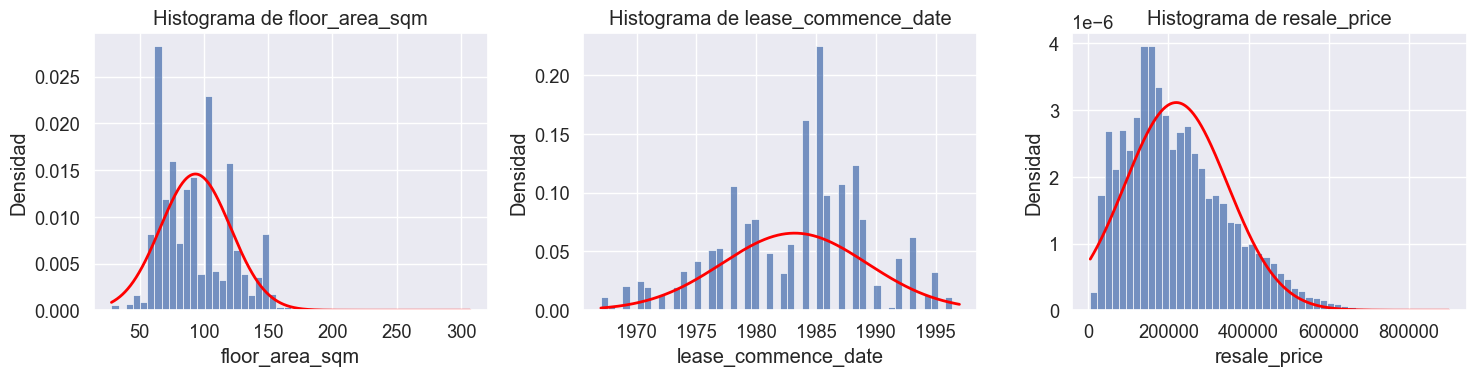

None

--------------------------------------------------------------------------------
Resumen estadístico para: df_2000_Feb_2012


,floor_area_sqm,lease_commence_date,resale_price
count,369651.000000,369651.000000,369651.000000
mean,96.586204,1987.984659,281271.860617
std,25.598886,9.122421,112118.967206
min,28.000000,1966.000000,28000.000000
25%,73.000000,1981.000000,195000.000000
50%,100.000000,1987.000000,263000.000000
75%,115.000000,1997.000000,350000.000000
max,297.000000,2012.000000,903000.000000




Histograma para: df_2000_Feb_2012


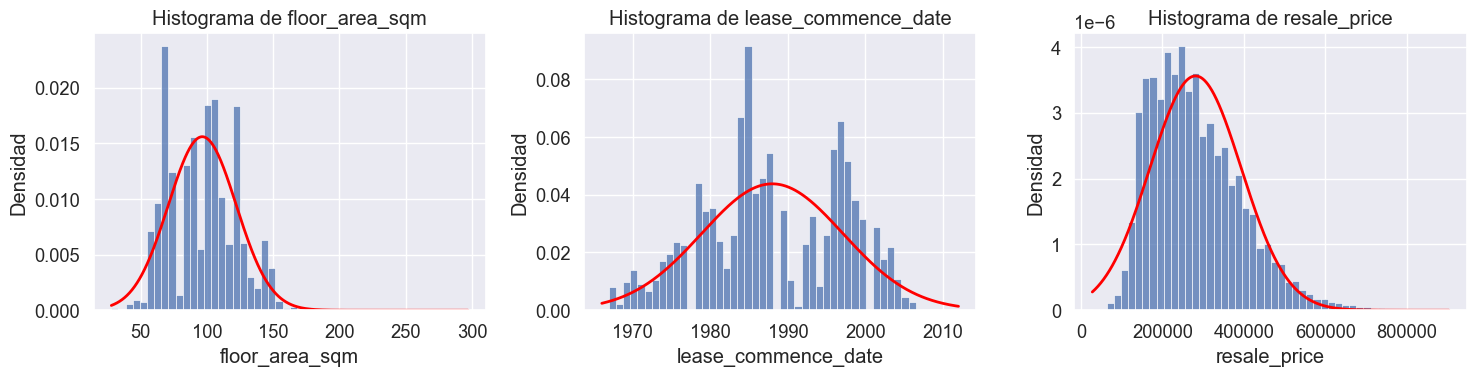

None

--------------------------------------------------------------------------------
Resumen estadístico para: From_Jan_2015_Dec_2016


,floor_area_sqm,lease_commence_date,remaining_lease,resale_price
count,37153.000000,37153.000000,37153.000000,3.715300e+04
mean,97.020386,1990.920195,73.913116,4.368628e+05
std,24.198360,10.862330,10.885456,1.358052e+05
min,31.000000,1966.000000,48.000000,1.900000e+05
25%,74.000000,1984.000000,66.000000,3.400000e+05
50%,96.000000,1989.000000,72.000000,4.080000e+05
75%,111.000000,2000.000000,83.000000,4.950000e+05
max,280.000000,2013.000000,97.000000,1.150000e+06




Histograma para: From_Jan_2015_Dec_2016


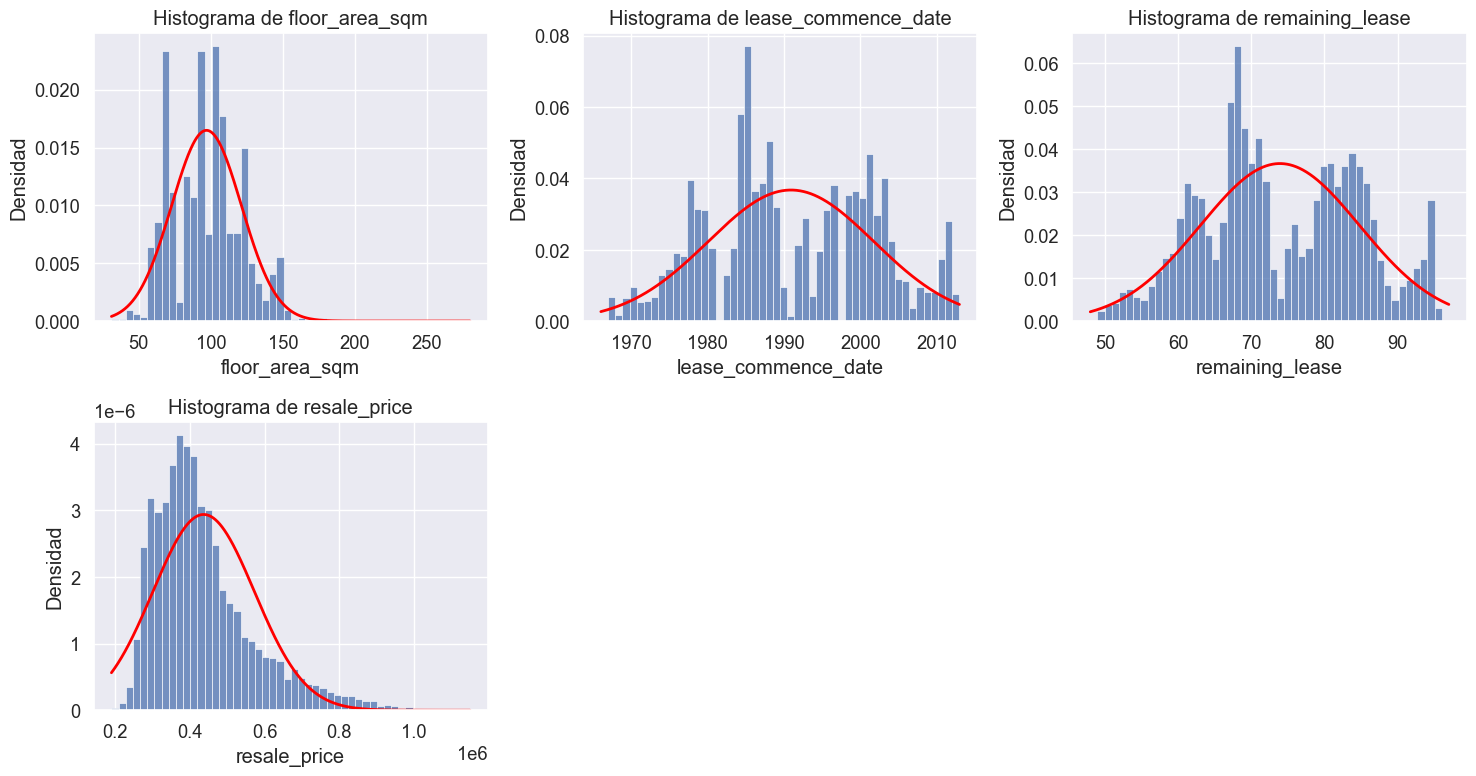

None

--------------------------------------------------------------------------------
Resumen estadístico para: From_Mar_2012_Dec_2014


,floor_area_sqm,lease_commence_date,resale_price
count,52203.000000,52203.000000,5.220300e+04
mean,96.203285,1989.512902,4.612147e+05
std,24.984010,10.139550,1.225534e+05
min,31.000000,1966.000000,1.950000e+05
25%,73.000000,1983.000000,3.700000e+05
50%,95.000000,1988.000000,4.400000e+05
75%,111.000000,1999.000000,5.250000e+05
max,266.000000,2012.000000,1.088888e+06




Histograma para: From_Mar_2012_Dec_2014


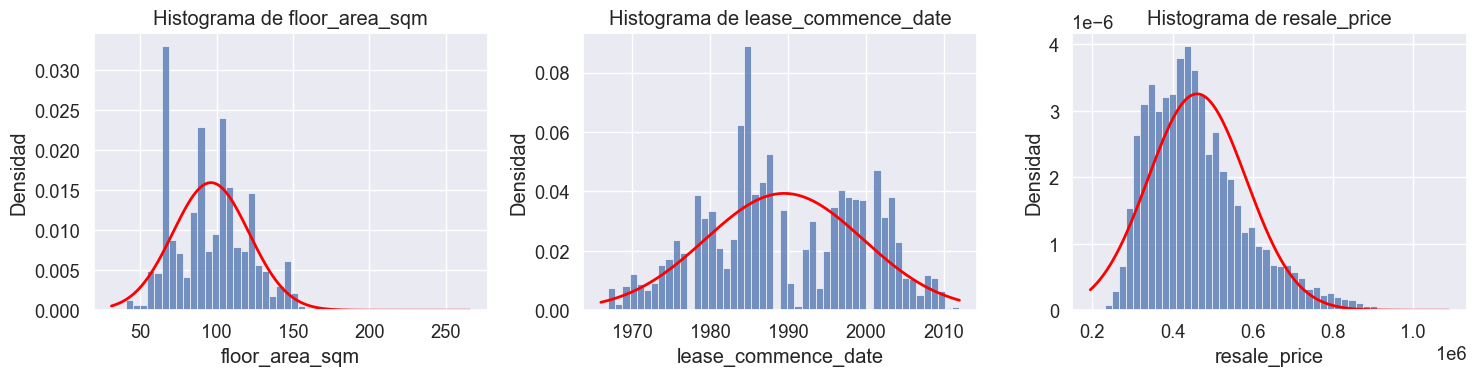

None

--------------------------------------------------------------------------------
Resumen estadístico para: jan_2017_onwards


,floor_area_sqm,lease_commence_date,remaining_lease,resale_price
count,233055.000000,233055.000000,233055.000000,2.330550e+05
mean,96.691907,1996.541748,74.146707,5.307918e+05
std,24.016558,14.358283,14.294190,1.900605e+05
min,31.000000,1966.000000,39.666667,1.400000e+05
25%,81.000000,1985.000000,62.250000,3.900000e+05
50%,93.000000,1997.000000,73.916667,5.000000e+05
75%,112.000000,2012.000000,88.583333,6.380000e+05
max,366.700000,2022.000000,97.750000,1.728000e+06




Histograma para: jan_2017_onwards


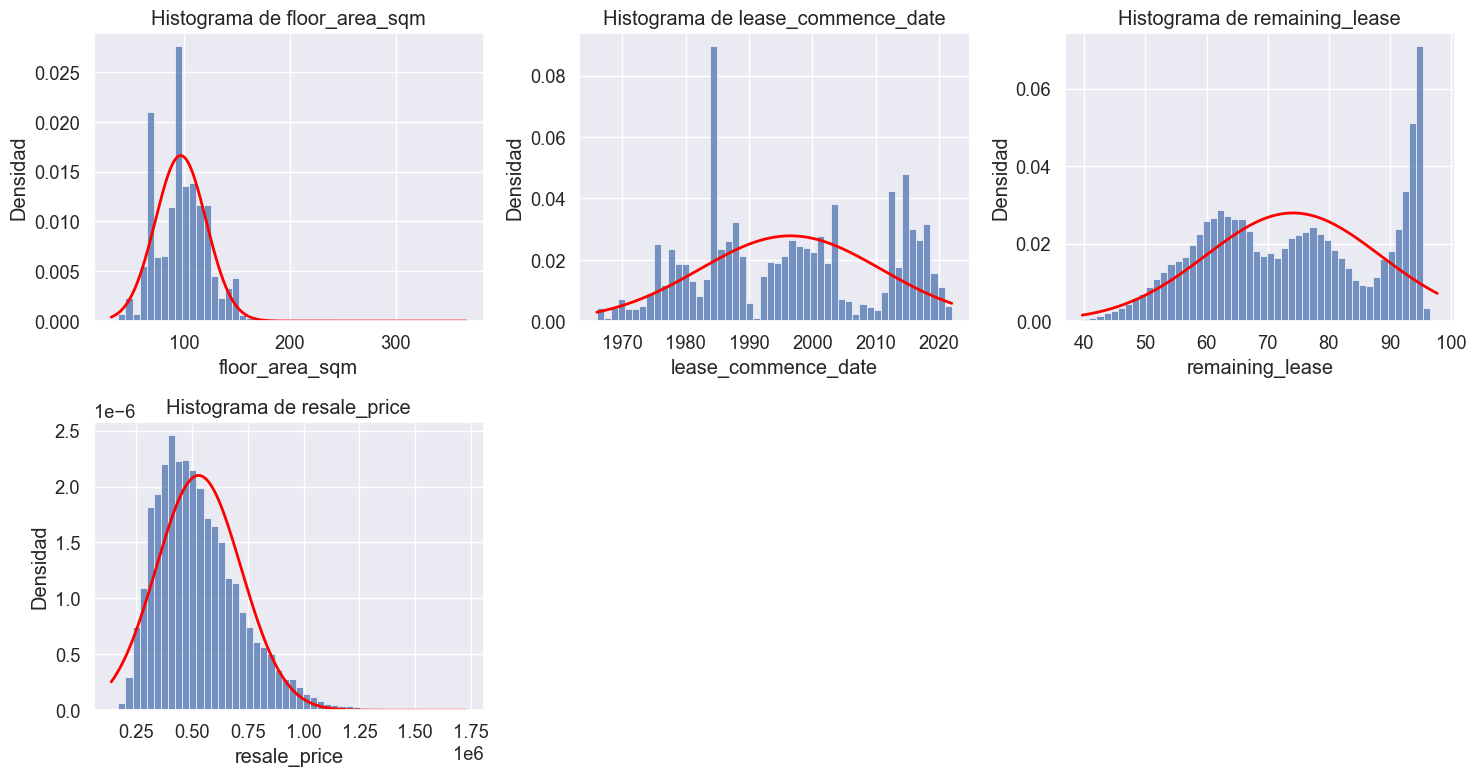

None

--------------------------------------------------------------------------------


In [85]:
for nombre in nombres_dfs:
    if nombre in globals():
        df = globals()[nombre]

        print(f"Resumen estadístico para: {nombre}")
        resumen = df.drop(columns=['Date'], errors='ignore').describe()
        display(resumen)
        
        print("\n") 
        
        print(f"Histograma para: {nombre}")
        display(utils.histogram_plot(df))
        print("-" * 80)

Como vemos, el precio medio (resale_price) se ha más que duplicado en las últimas tres décadas. Pasó de una media de $219.541$ en los años 90 a $530.791$ en la etapa de 2017 en adelante. Además, vemos que a partir de 2012 los precios máximos rompen holgadamente la barrera del millón (llegando a $1,7$ millones en los últimos años).

A pesar del gran salto en los precios y el paso de los años, el tamaño medio de los pisos (floor_area_sqm) apenas ha variado, manteniéndose siempre en una media constante de entre 93 y 97 $m^2$. Se paga mucho más por el mismo espacio.

Podemos ver la evolución a lo largo del tiempo de los precios medios y los metros cuadrados. Para ello unimos (temporalmente) todos los datasets:

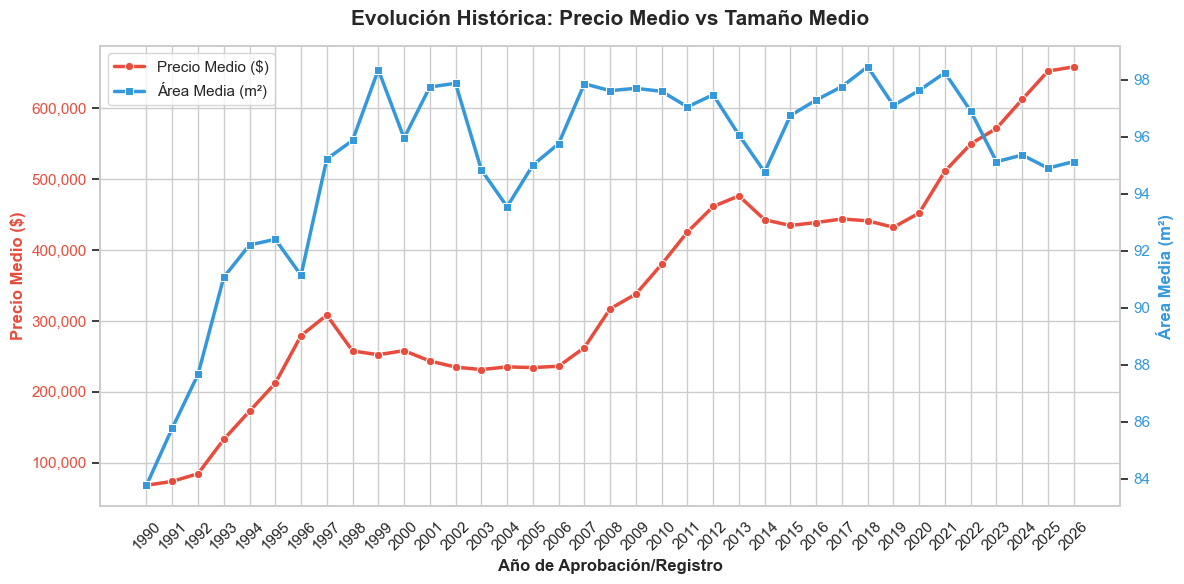

In [86]:
# Unimos todo para la representación gráfica
lista_dfs = [globals()[nombre] for nombre in nombres_dfs if nombre in globals()]
df_total = pd.concat(lista_dfs, ignore_index=True)

if not pd.api.types.is_datetime64_any_dtype(df_total['Date']):
    df_total['Date'] = pd.to_datetime(df_total['Date'], format='%Y-%m', errors='coerce')

df_total['year'] = df_total['Date'].dt.year

# Calculamos las medias anuales
evolucion_precio = df_total.groupby('year')['resale_price'].mean().reset_index()
evolucion_area = df_total.groupby('year')['floor_area_sqm'].mean().reset_index()

sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 6))

# --- Eje Y Principal (Izquierda): Evolución del Precio ---
color_precio = '#e74c3c' 
sns.lineplot(
    data=evolucion_precio, 
    x='year', 
    y='resale_price', 
    ax=ax1, 
    color=color_precio, 
    linewidth=2.5, 
    marker='o',
    label='Precio Medio ($)'
)
ax1.set_xlabel('Año de Aprobación/Registro', fontsize=12, fontweight='bold')
ax1.set_ylabel('Precio Medio ($)', fontsize=12, color=color_precio, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_precio) 
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x)))) 
# Doble eje:
ax2 = ax1.twinx()

# --- Eje Y Secundario (Derecha): Evolución del Tamaño ---
color_area = '#3498db' 
sns.lineplot(
    data=evolucion_area, 
    x='year', 
    y='floor_area_sqm', 
    ax=ax2, 
    color=color_area, 
    linewidth=2.5, 
    marker='s',
    label='Área Media (m²)'
)
ax2.set_ylabel('Área Media (m²)', fontsize=12, color=color_area, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_area)
ax2.grid(False) 

plt.title('Evolución Histórica: Precio Medio vs Tamaño Medio', fontsize=15, fontweight='bold', pad=15)
ax1.set_xticks(evolucion_precio['year'].dropna().unique())
ax1.tick_params(axis='x', rotation=45)

# Unificamos las leyendas de ambos ejes en una sola caja
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')
ax2.get_legend().remove() 

plt.tight_layout()
plt.show()

Se observa claramente lo comentado anteriormente.

Ahora, veamos los boxplots para cada variable numérica:

BoxPlots para: df_1990_1999


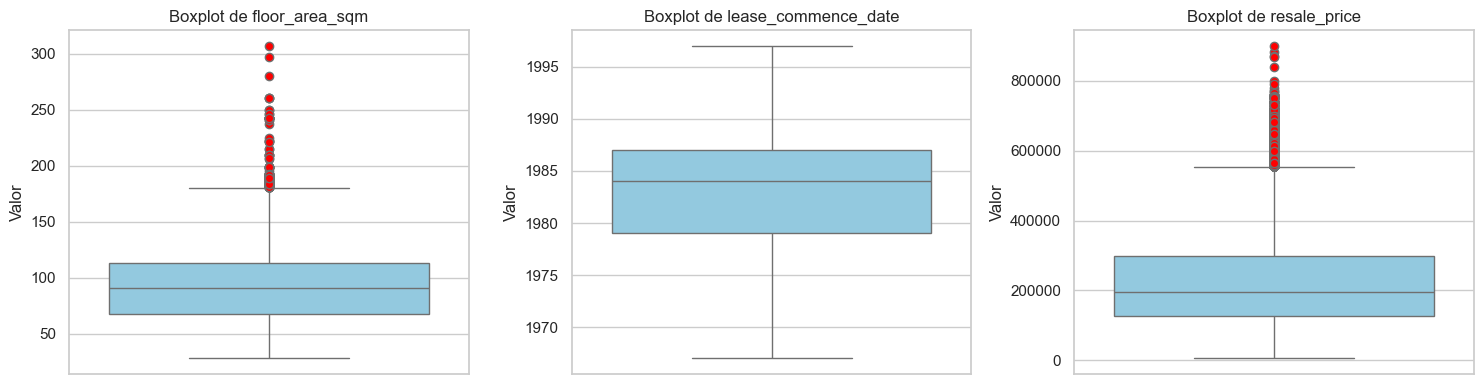

None

--------------------------------------------------
BoxPlots para: df_2000_Feb_2012


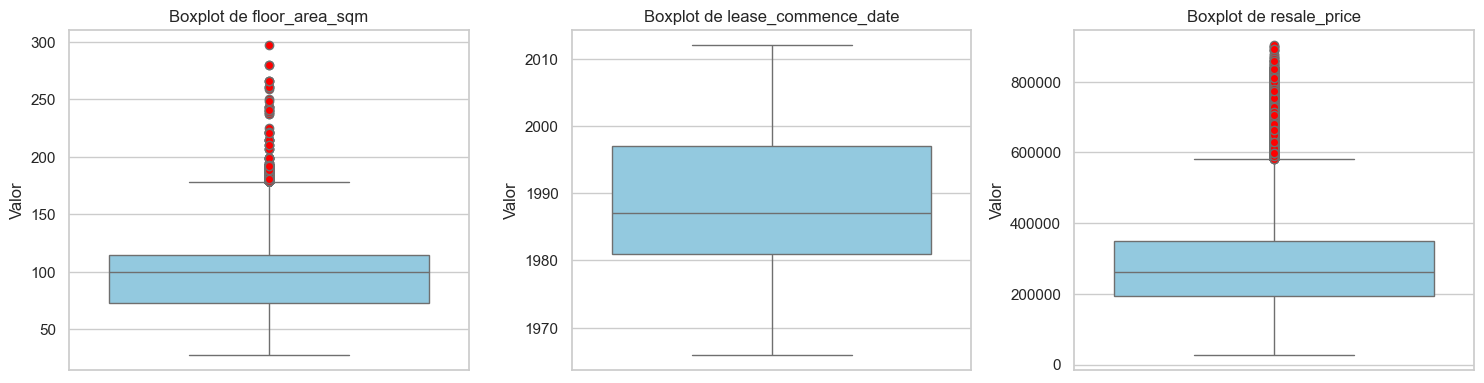

None

--------------------------------------------------
BoxPlots para: From_Jan_2015_Dec_2016


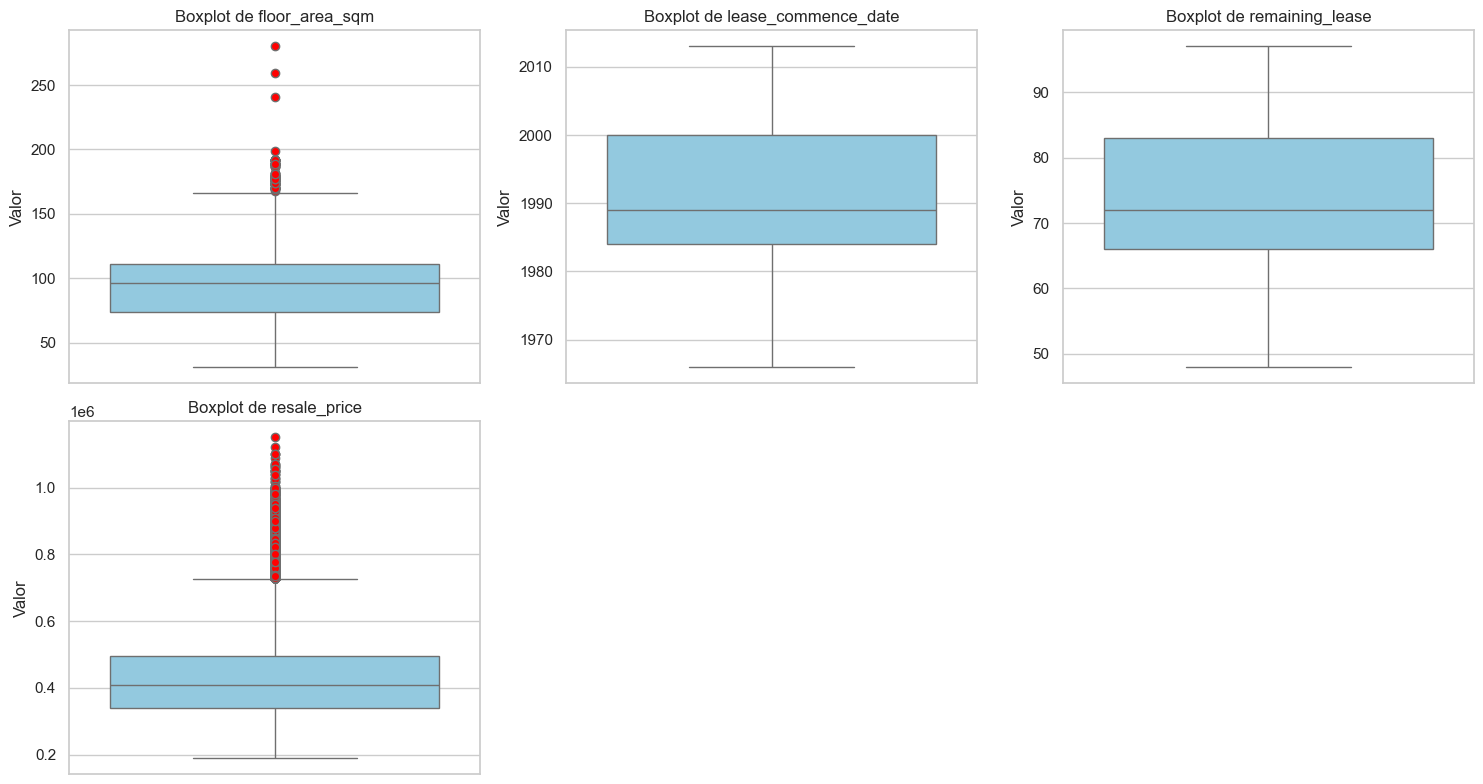

None

--------------------------------------------------
BoxPlots para: From_Mar_2012_Dec_2014


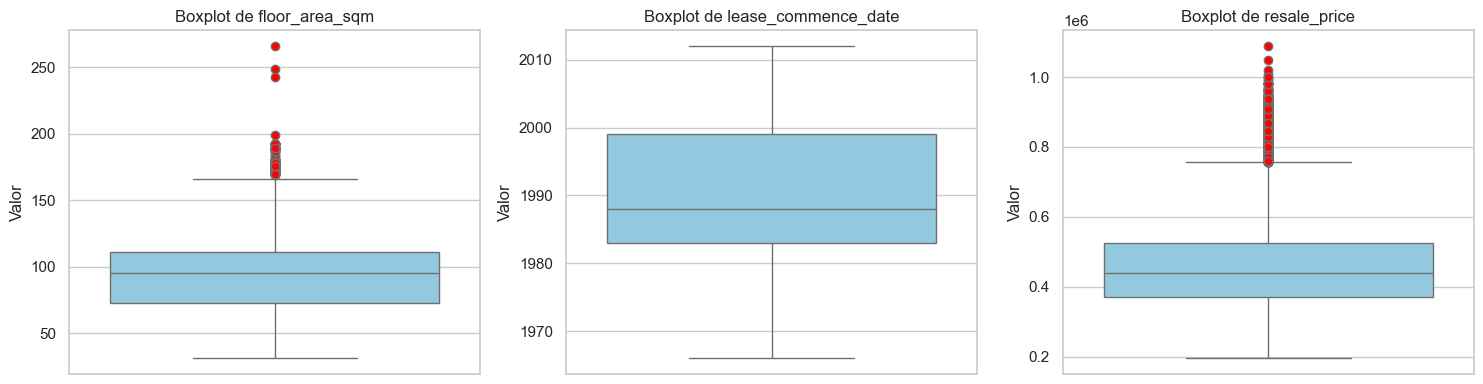

None

--------------------------------------------------
BoxPlots para: jan_2017_onwards


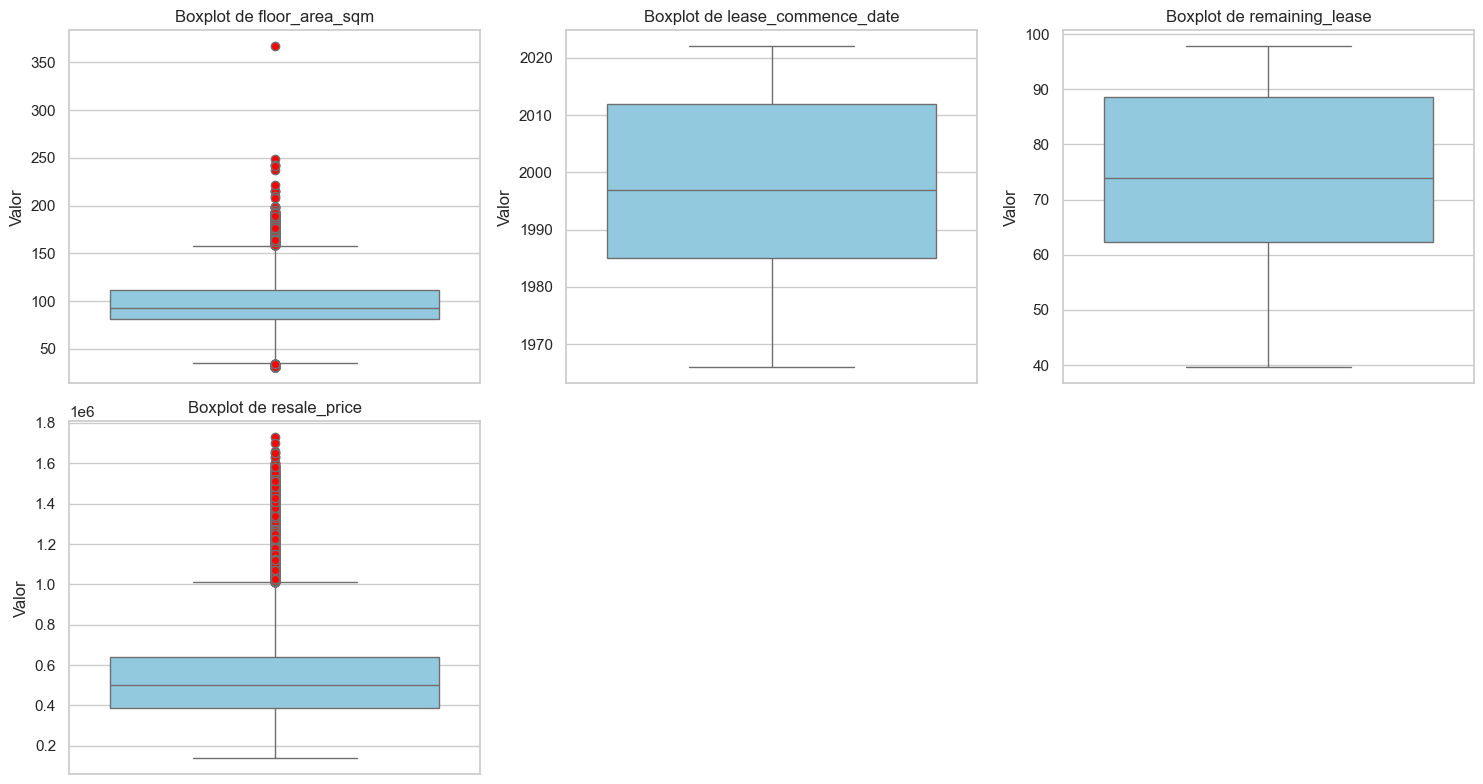

None

--------------------------------------------------


In [87]:
for nombre in nombres_dfs:
    if nombre in globals():
        print(f"BoxPlots para: {nombre}")
        display(utils.plot_all_boxplots(globals()[nombre]))
        
        print("-" * 50)

Con los boxplots anteriores, confirmamos visualmente lo dicho antes a partir de los resuúmenes estadísticos e histogramas. De hecho, nos da una primera pista para pensar, en los futuros modelos, aplicar logaritmos a algunas de las variables, como el precio.

Gráficos de barras para: df_1990_1999


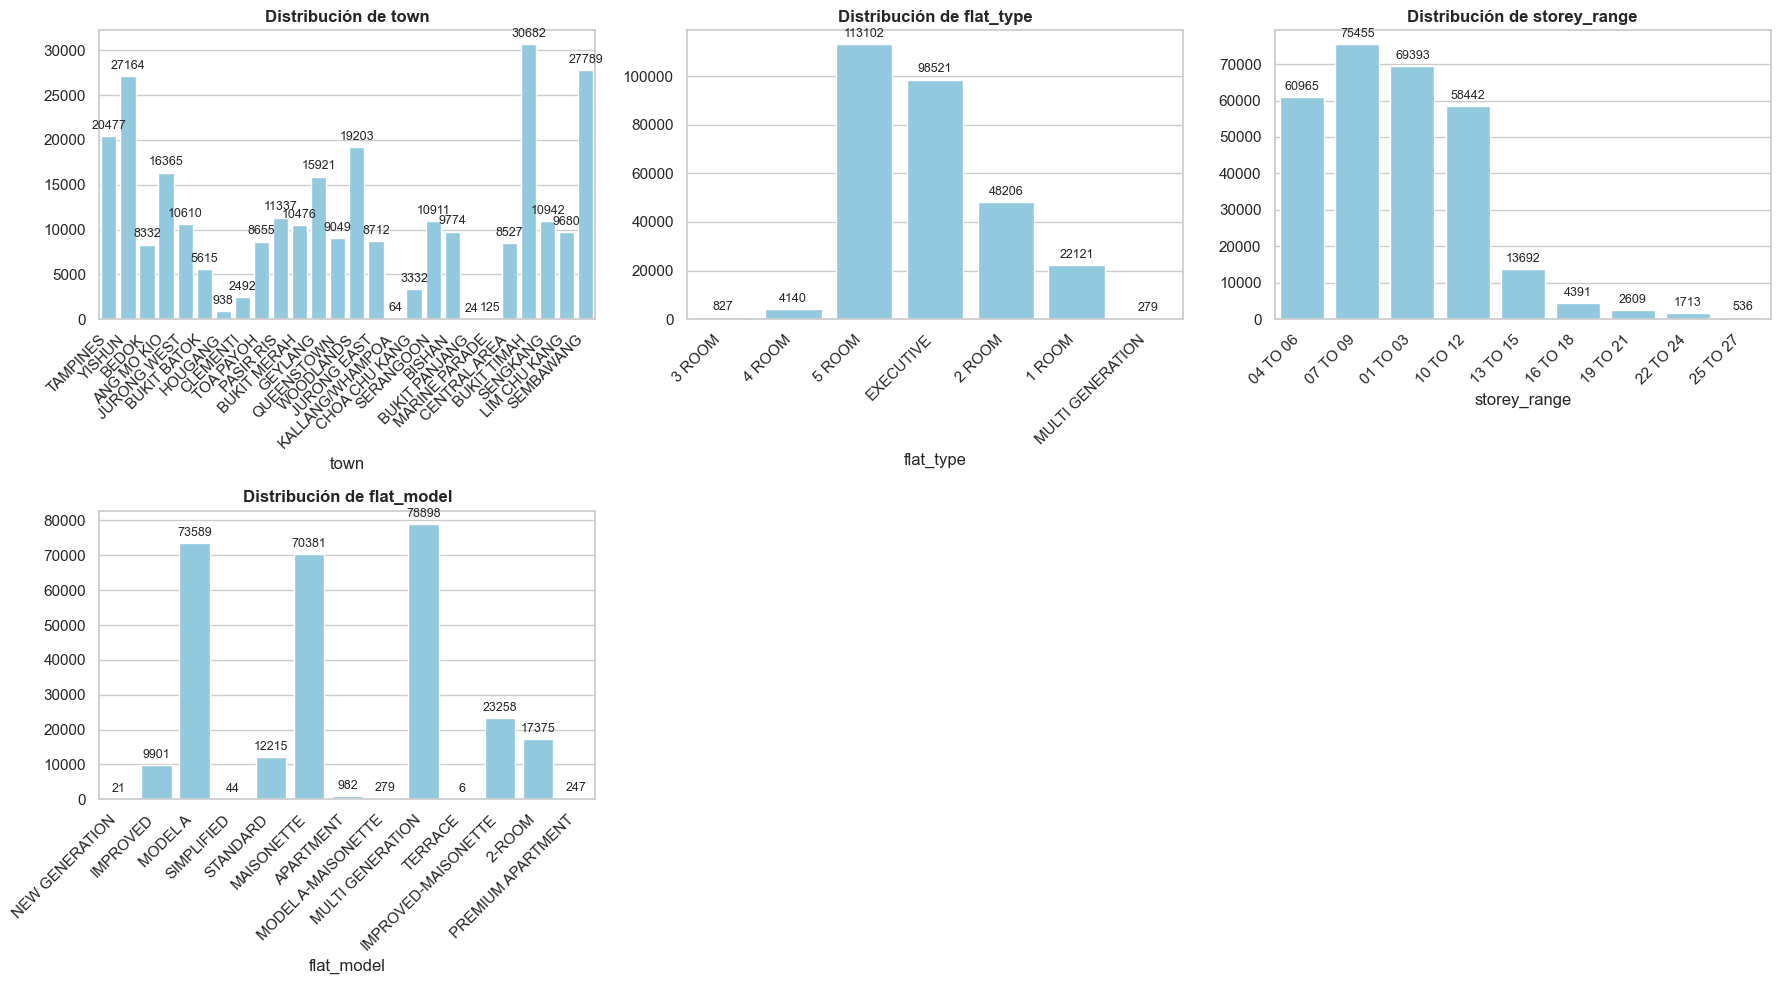

None

--------------------------------------------------
Gráficos de barras para: df_2000_Feb_2012


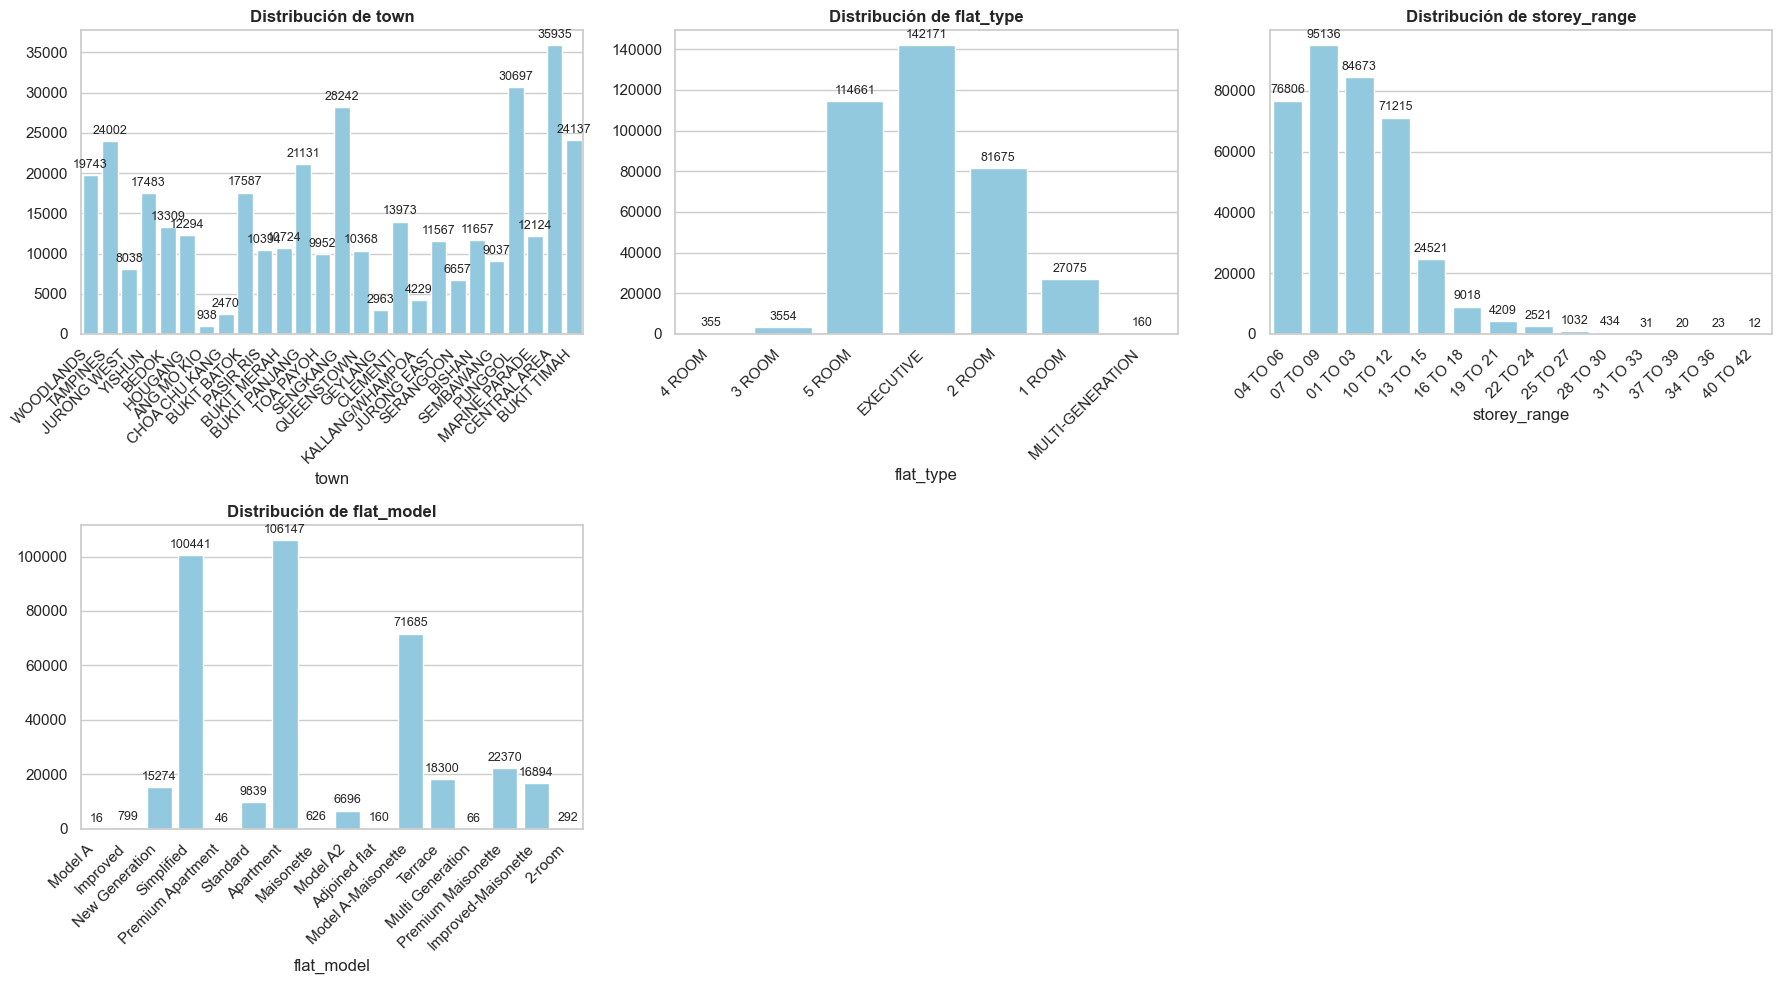

None

--------------------------------------------------
Gráficos de barras para: From_Jan_2015_Dec_2016


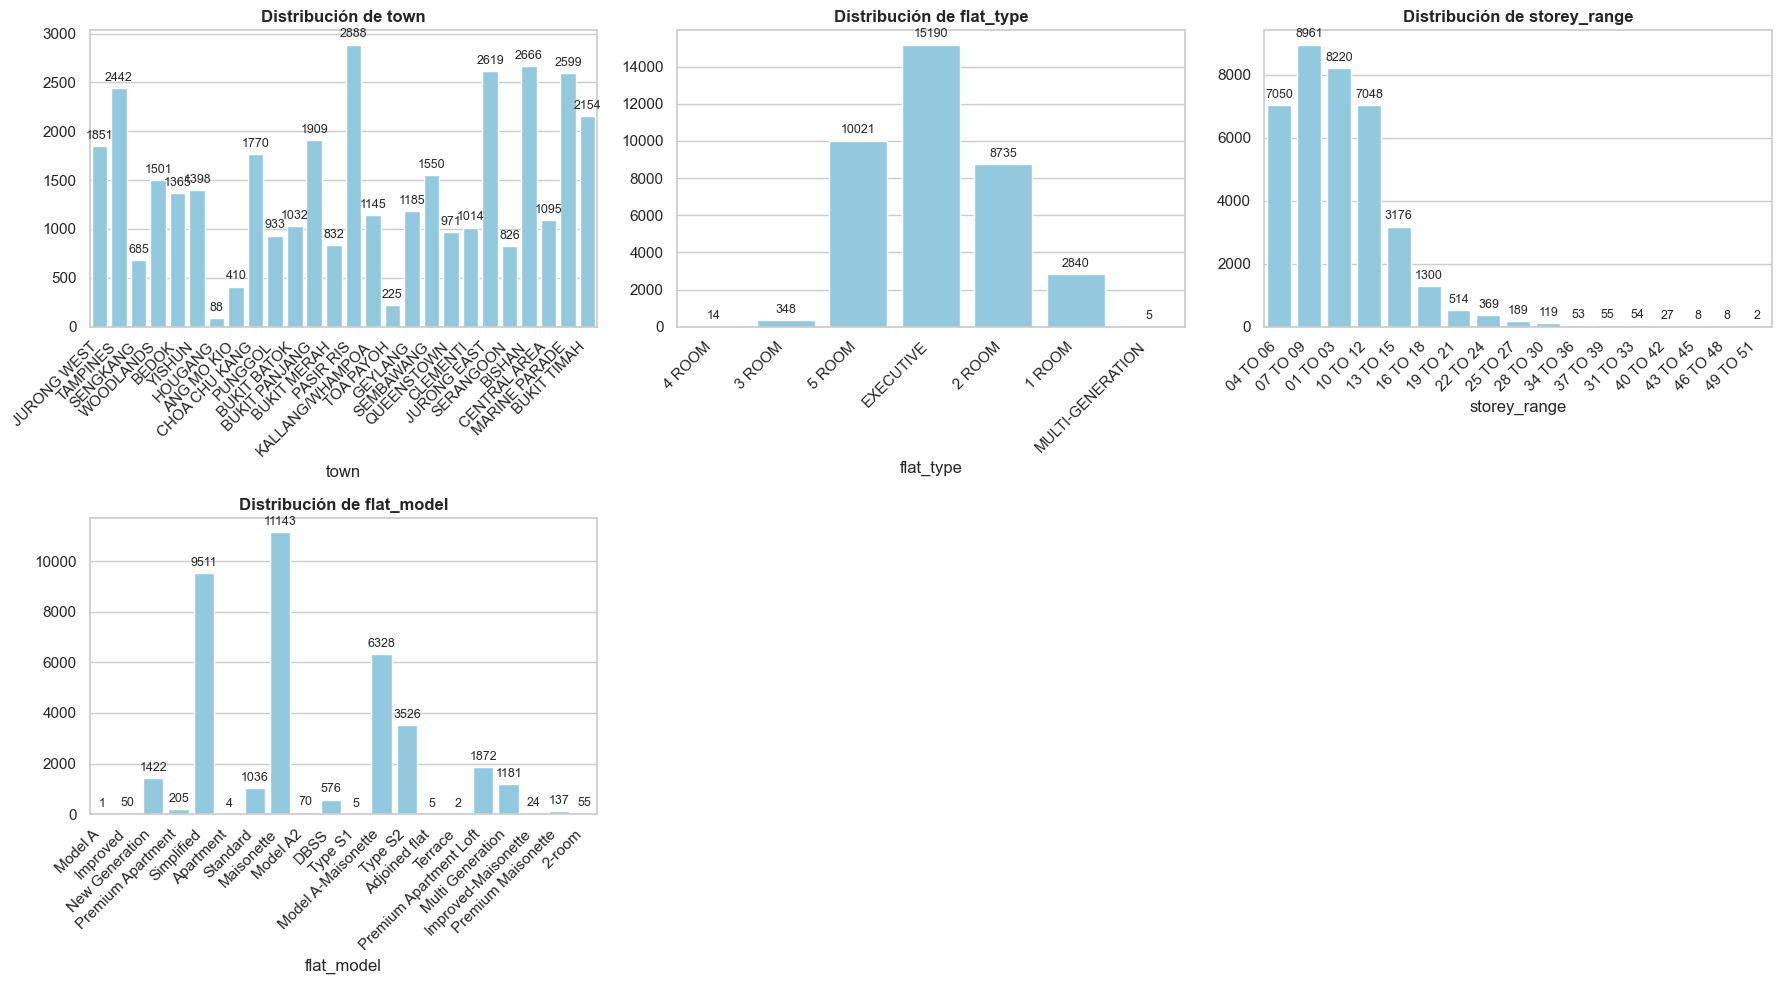

None

--------------------------------------------------
Gráficos de barras para: From_Mar_2012_Dec_2014


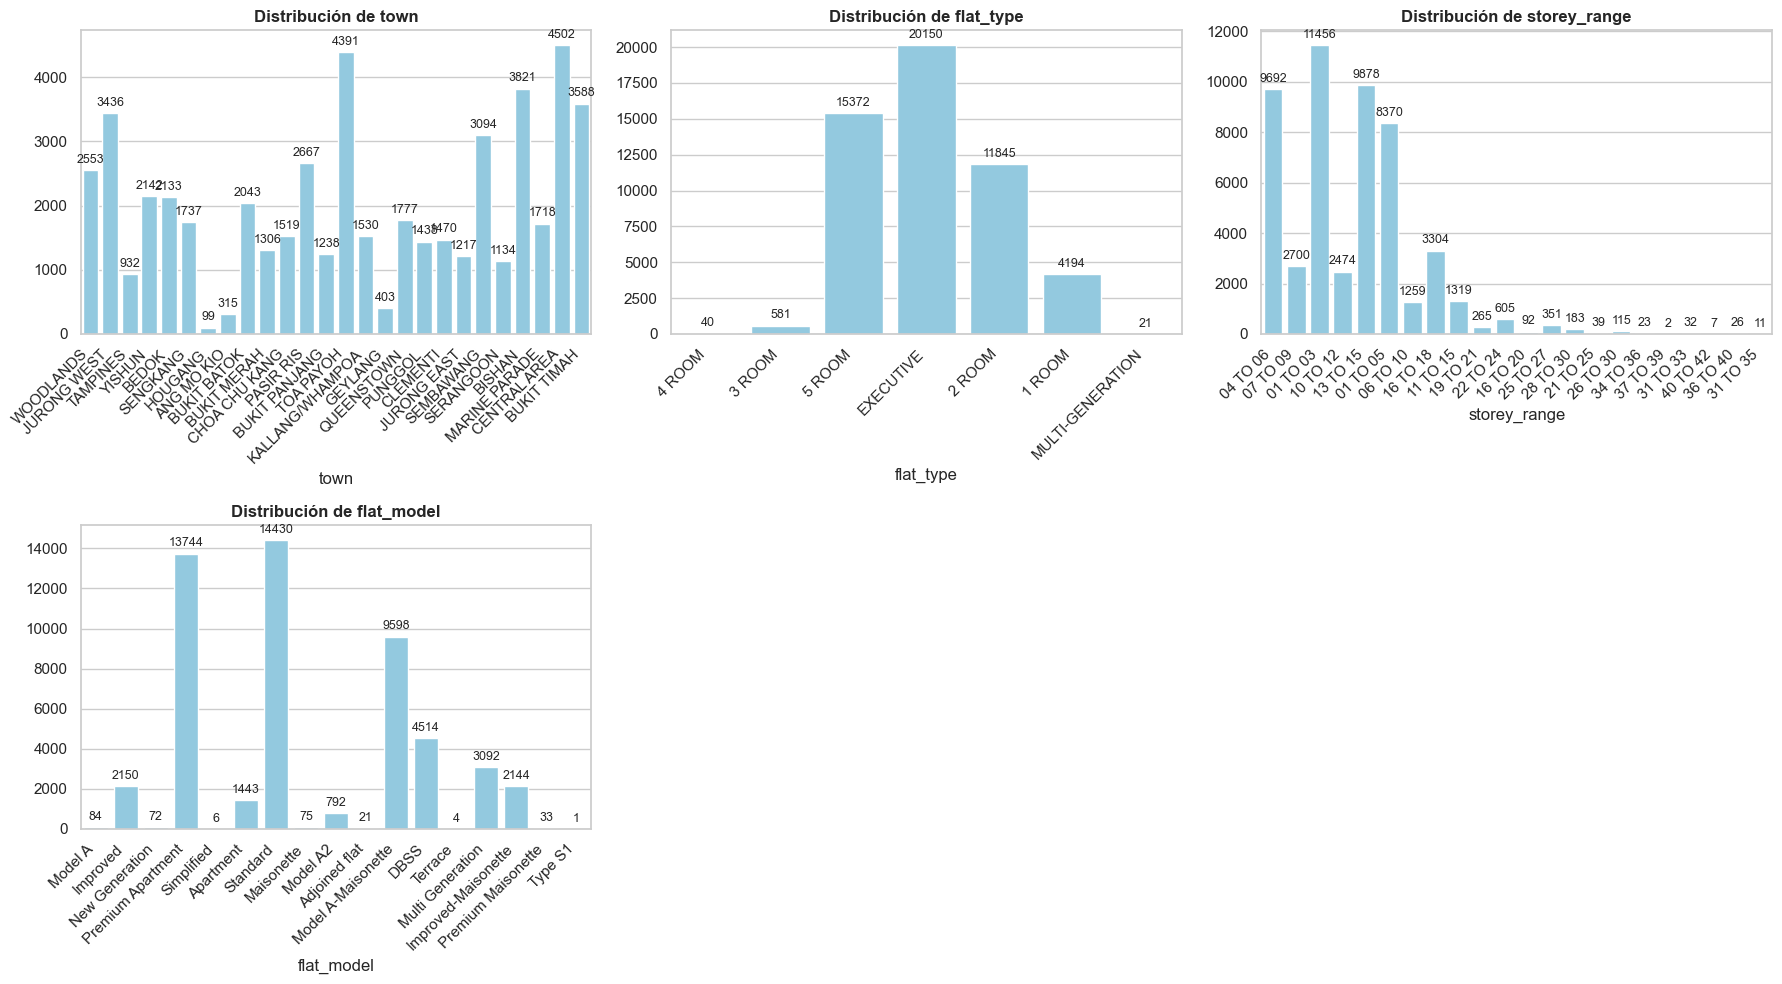

None

--------------------------------------------------
Gráficos de barras para: jan_2017_onwards


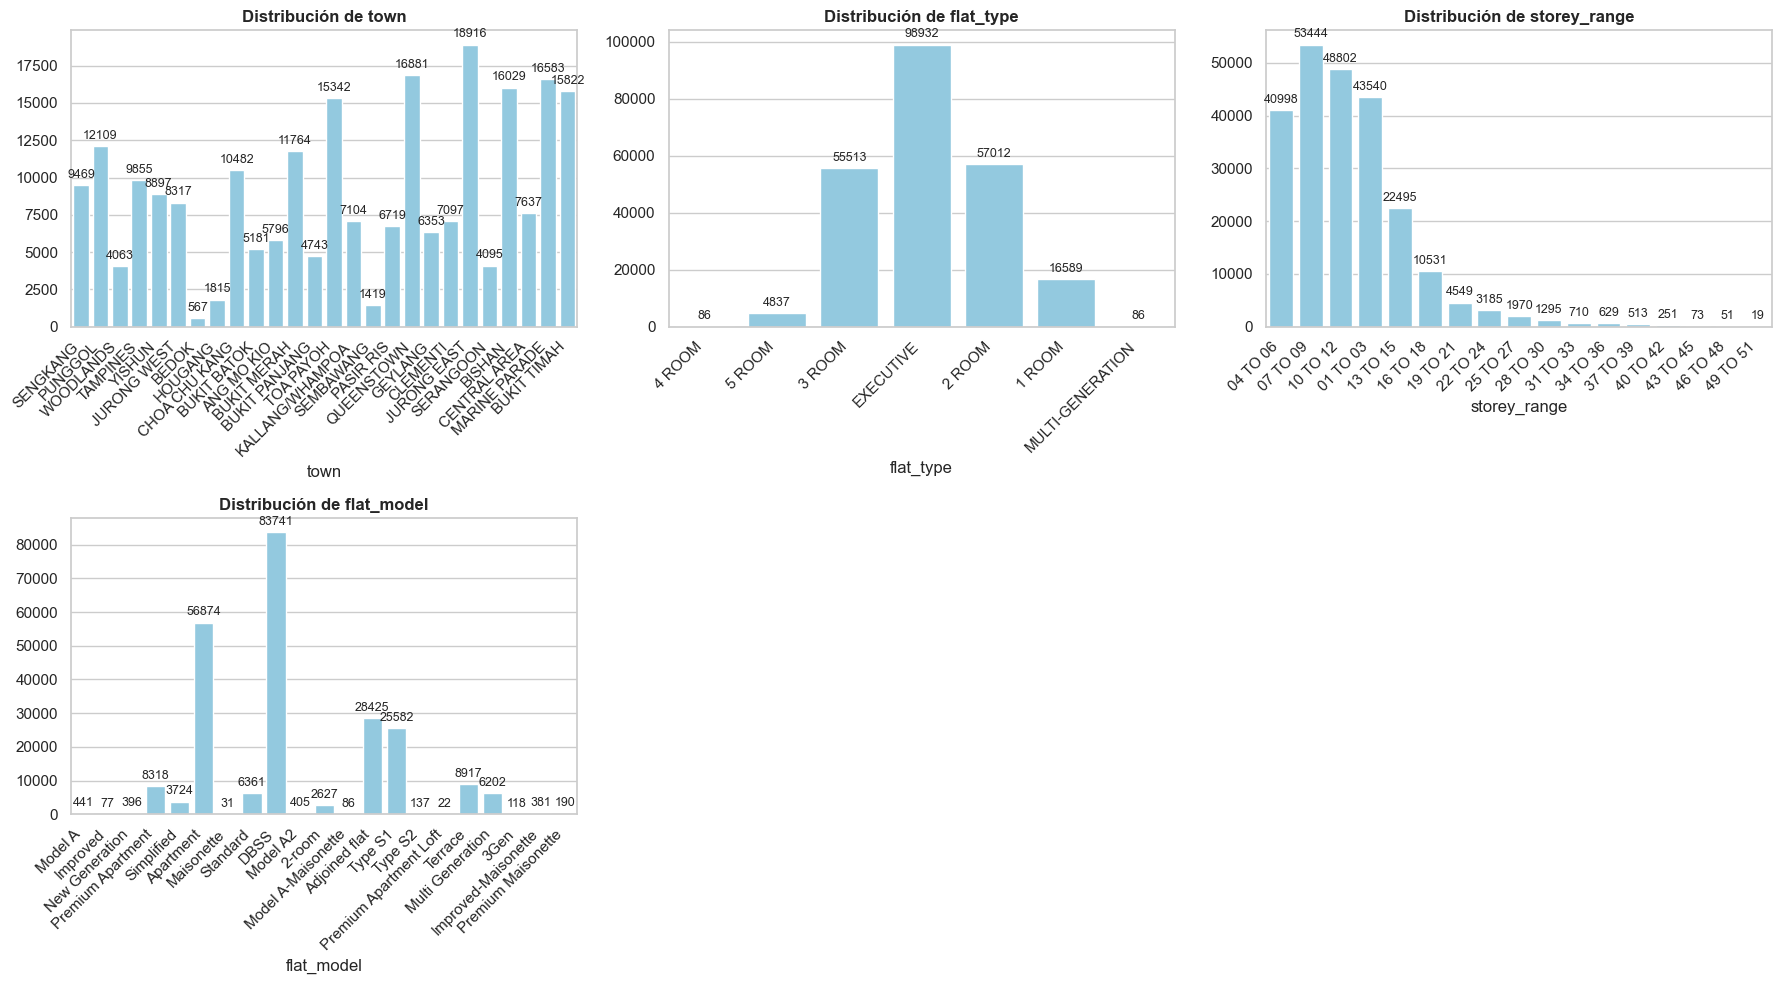

None

--------------------------------------------------


In [88]:
for nombre in nombres_dfs:
    if nombre in globals():
        print(f"Gráficos de barras para: {nombre}")
        display(utils.plot_categoricas(globals()[nombre], 30))
        
        print("-" * 50)

Vemos que cada dataset se comporta de una manera distinta, aunque variables como `storey_range` o `flat_type`, tienden a ser similares.

## 3.2. Análisis Bivariante

Ahora, veamos cómo se comporta nuestro target en función de nuestras variables categóricas:

Boxplots frente al Target para: df_1990_1999


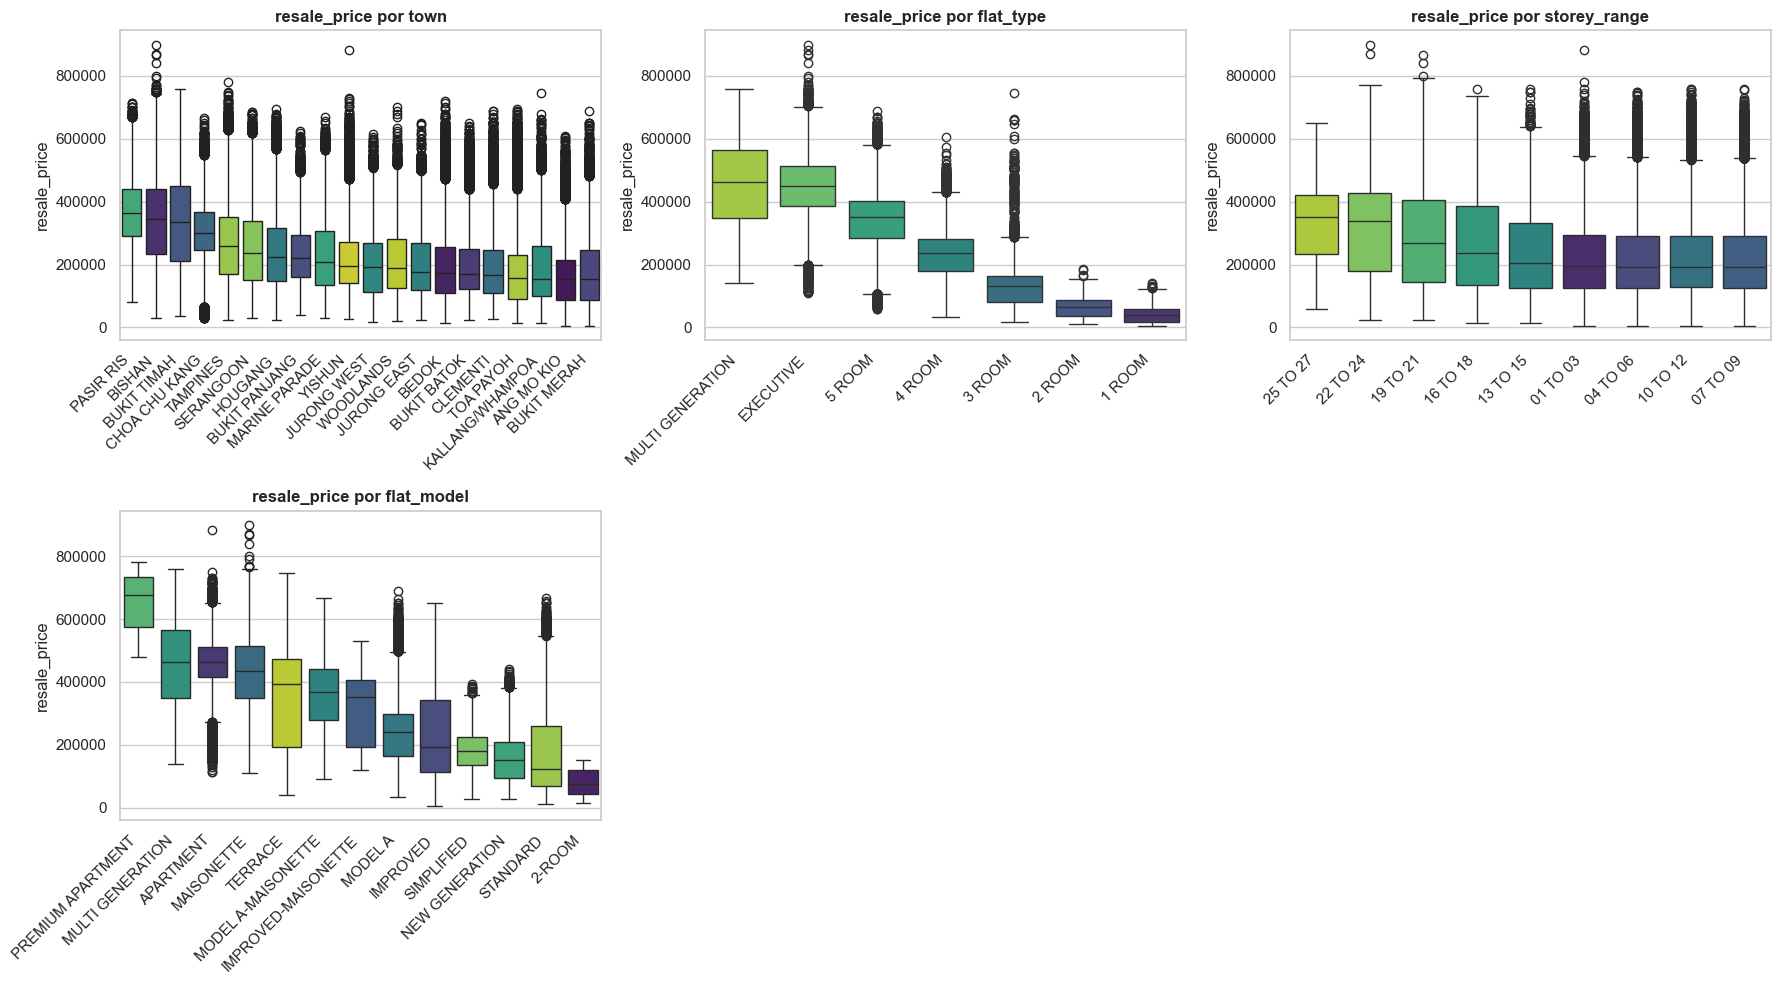

--------------------------------------------------
Boxplots frente al Target para: df_2000_Feb_2012


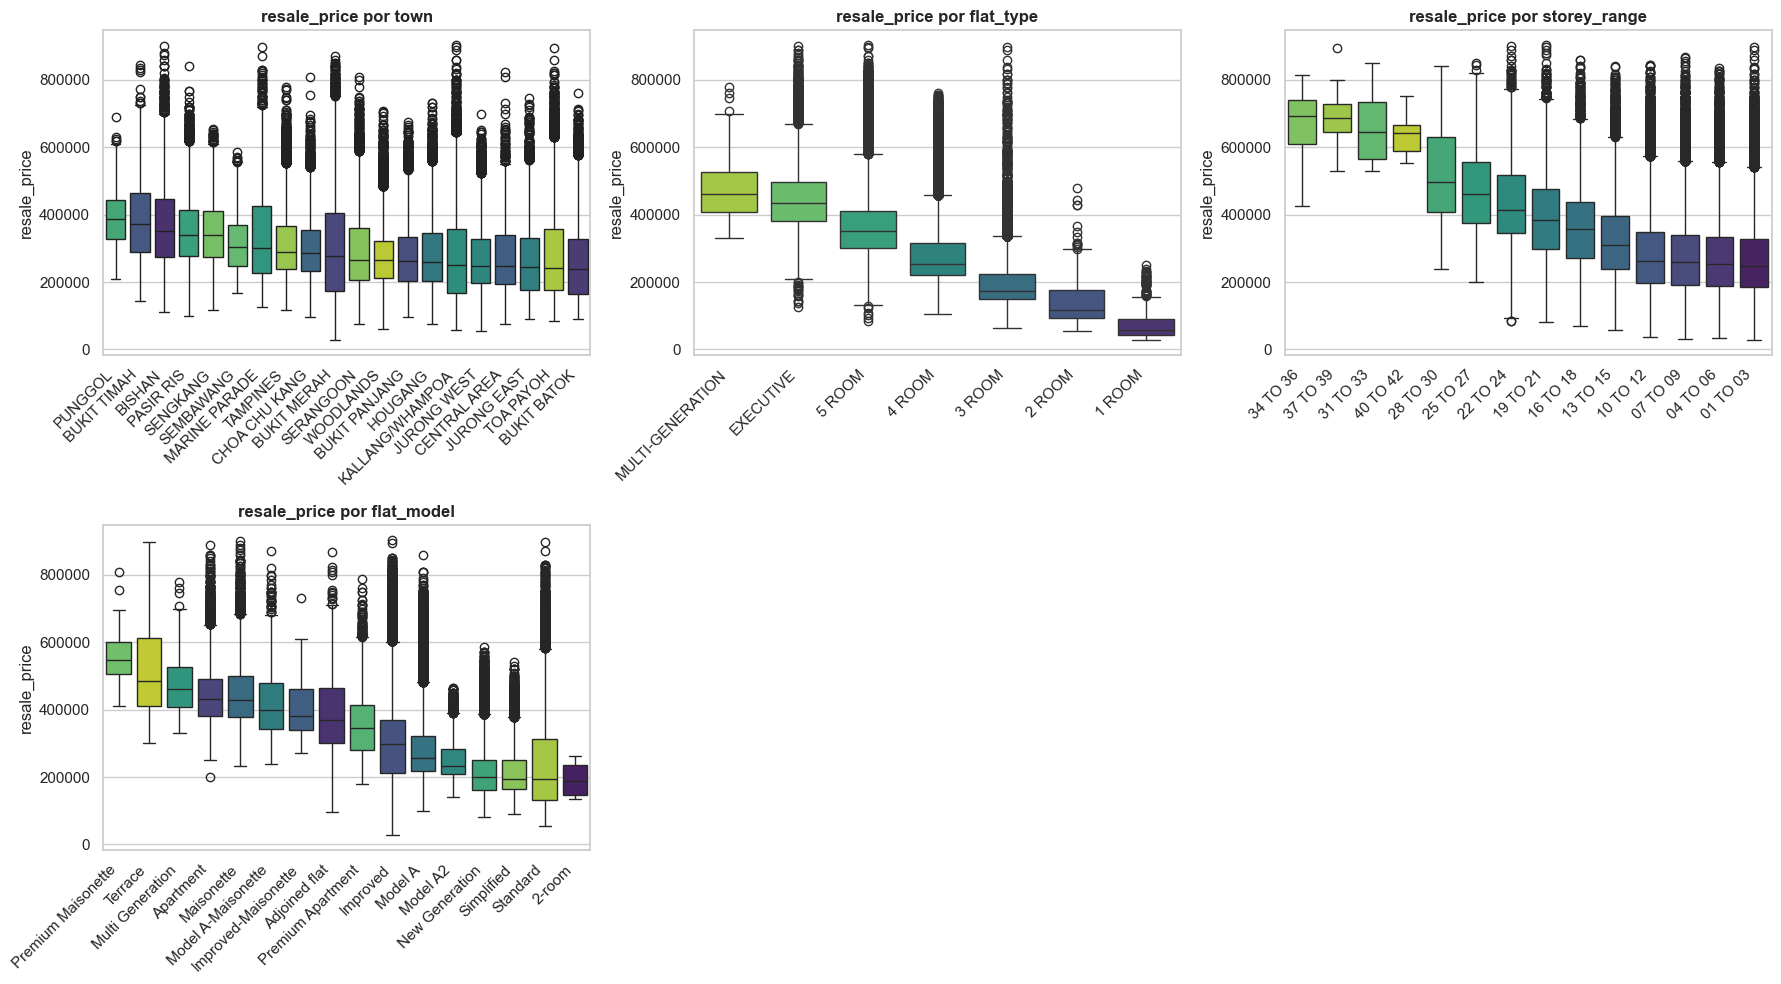

--------------------------------------------------
Boxplots frente al Target para: From_Jan_2015_Dec_2016


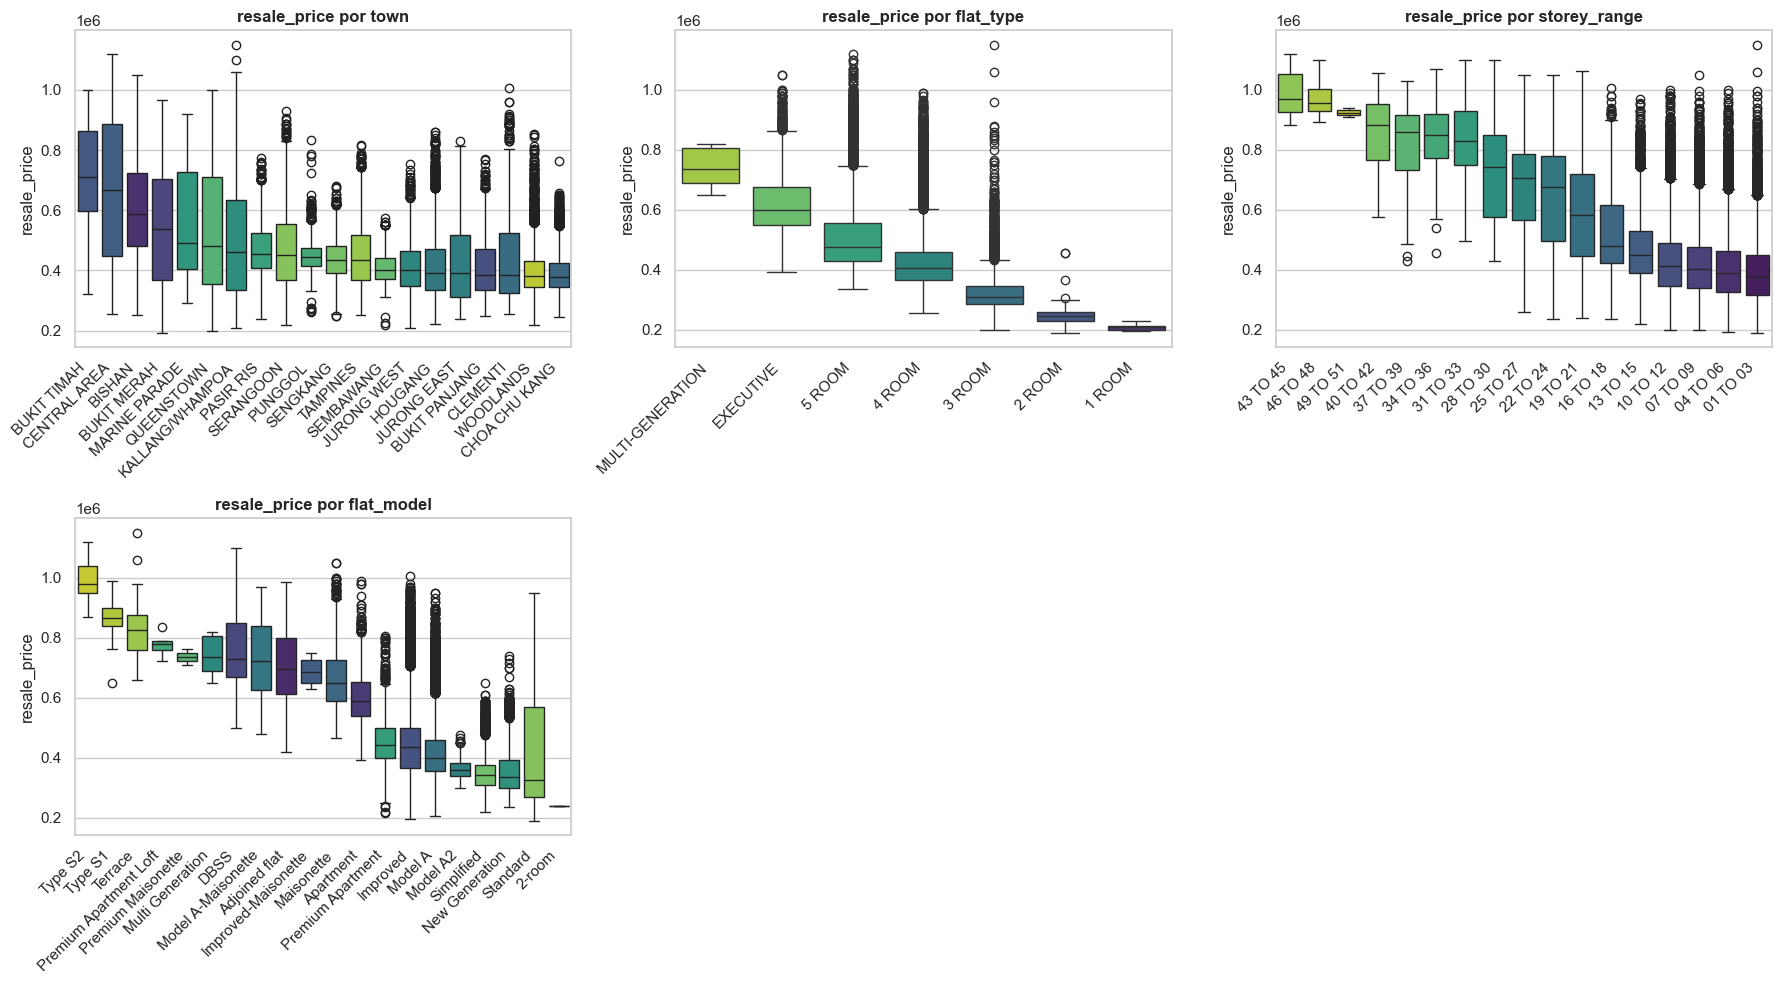

--------------------------------------------------
Boxplots frente al Target para: From_Mar_2012_Dec_2014


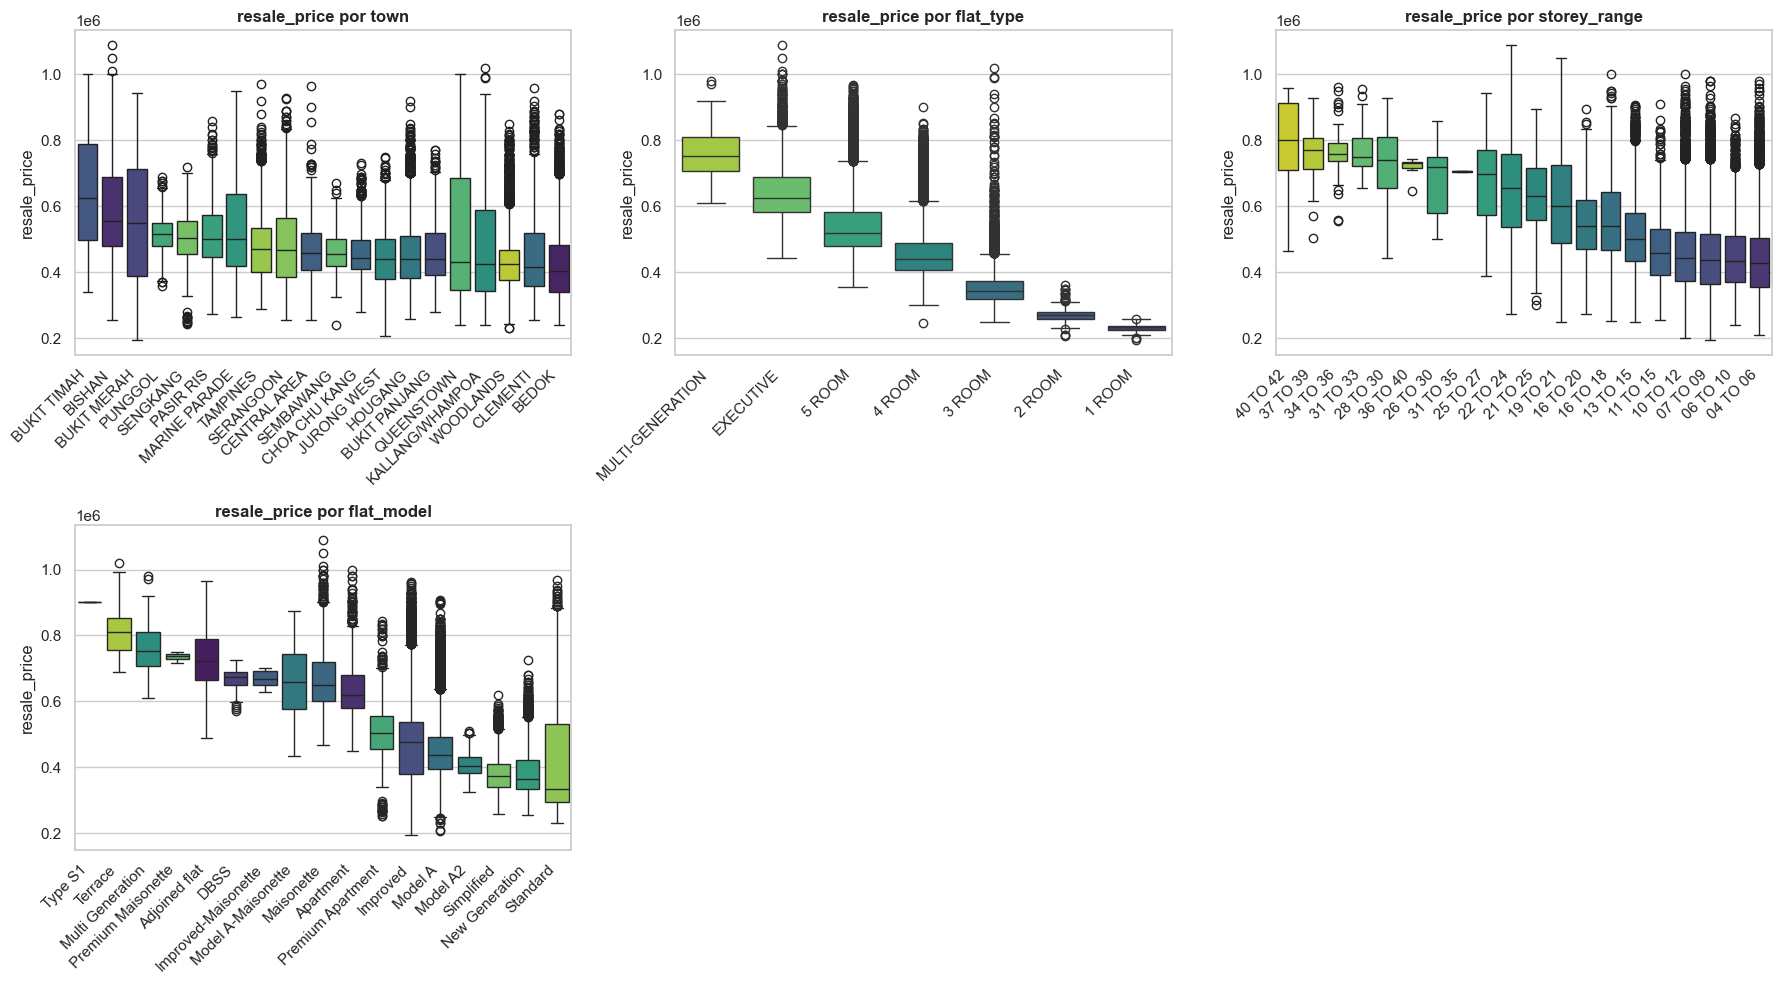

--------------------------------------------------
Boxplots frente al Target para: jan_2017_onwards


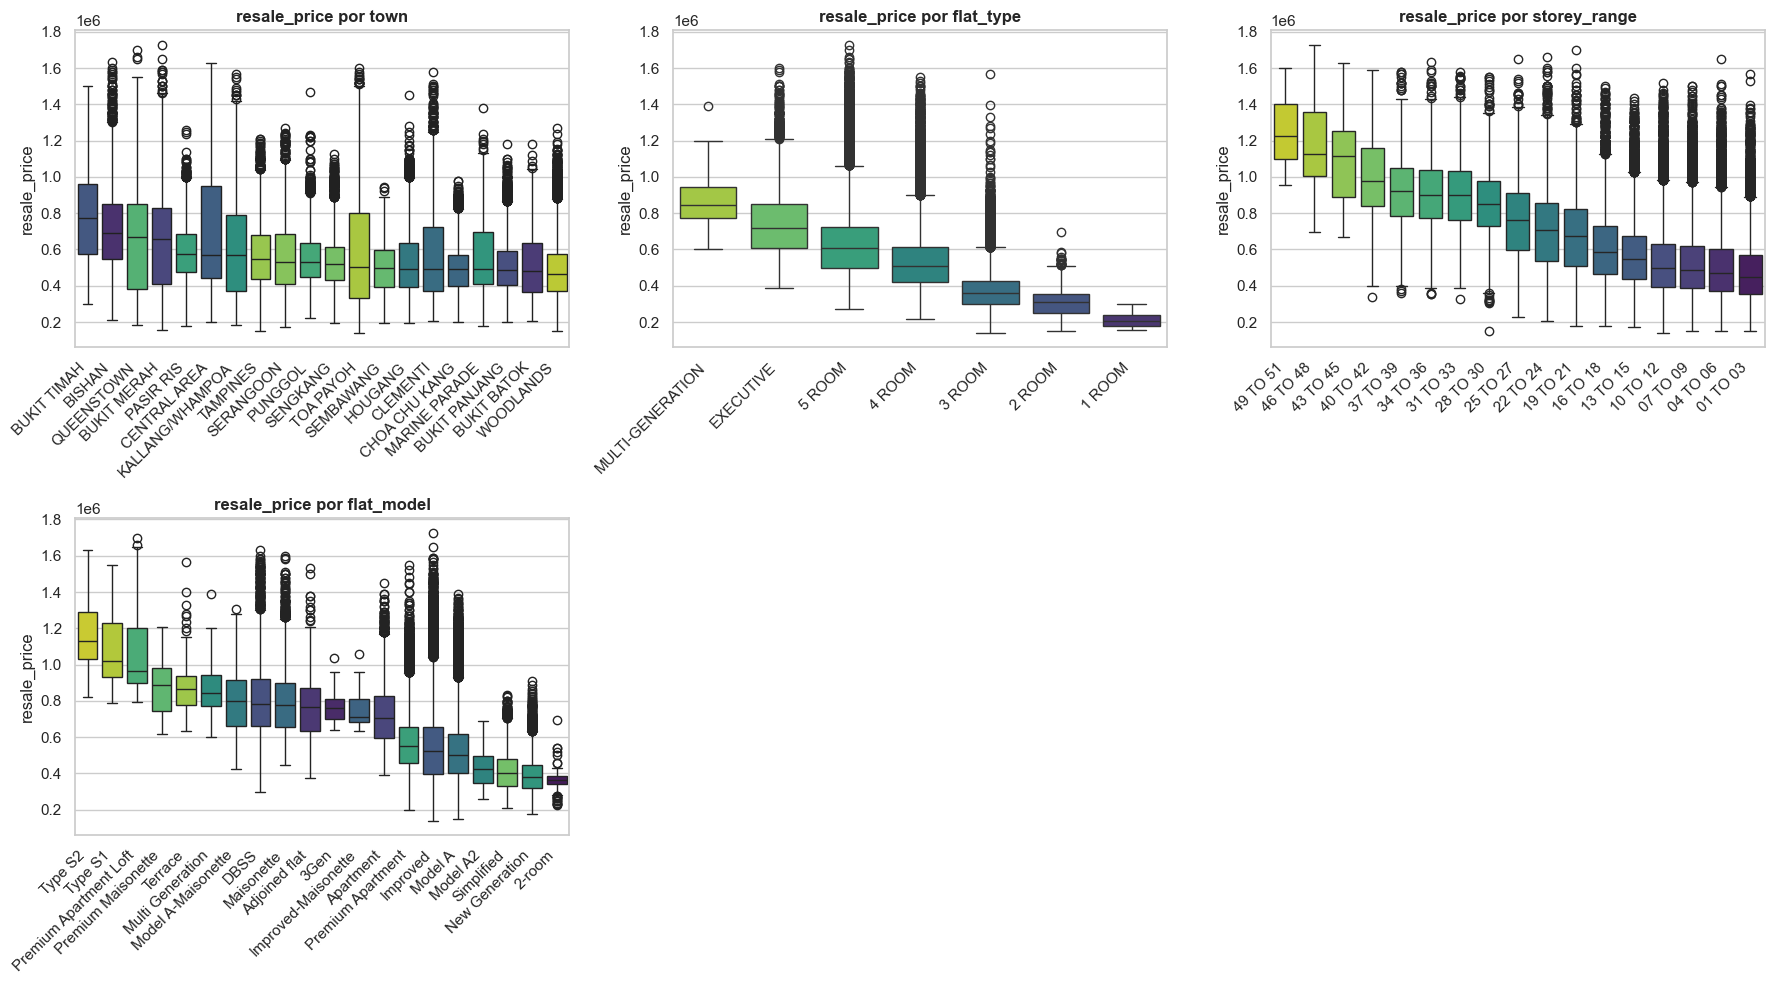

--------------------------------------------------


In [89]:
for nombre in nombres_dfs:
    if nombre in globals():
        print(f"Boxplots frente al Target para: {nombre}")
        utils.plot_boxplots_vs_target(globals()[nombre], target_var='resale_price')
        print("-" * 50)

En general, para todos los datasets, se observa que para las variables ``flat_type`` y ``flat_model`` existe una "escalera" de precios: cuanto más grande es el piso (Multi-Generation, Executive, 5-Room), más caro es. Además, los diseños arquitectónicos especiales (Lofts, Type S1/S2, Maisonettes) tienen un plus de valoración frente a los modelos estándar.

En cuanto a la variable ``storey_range`` se ve una correlación directa muy fuerte entre la altura y el lujo, especialmente en los años recientes. A mayor altura del piso, mayor es el precio base.

A medida que avanzan los años (los ejes Y pasan de tener un tope de $800.000$ a superar los $1,8$ millones), la cantidad de valores atípicos por encima de las cajas se dispara. Esto demuestra cómo el mercado ha generado un segmento de súper-lujo dentro de la vivienda pública, con propiedades puntuales que rompen por completo la estadística normal.

## 3.3. Análisis Multivariante

Ahora, se estudian las correlaciones entre las variables de cada dataset. Se continua analizando uindividualmente ya que, como hemos visto, en los más de 30 años ha cambiado mucho el panorama, por lo que estudiar las variables conjuntas daría una falsa impresión de posibles correlaciones.

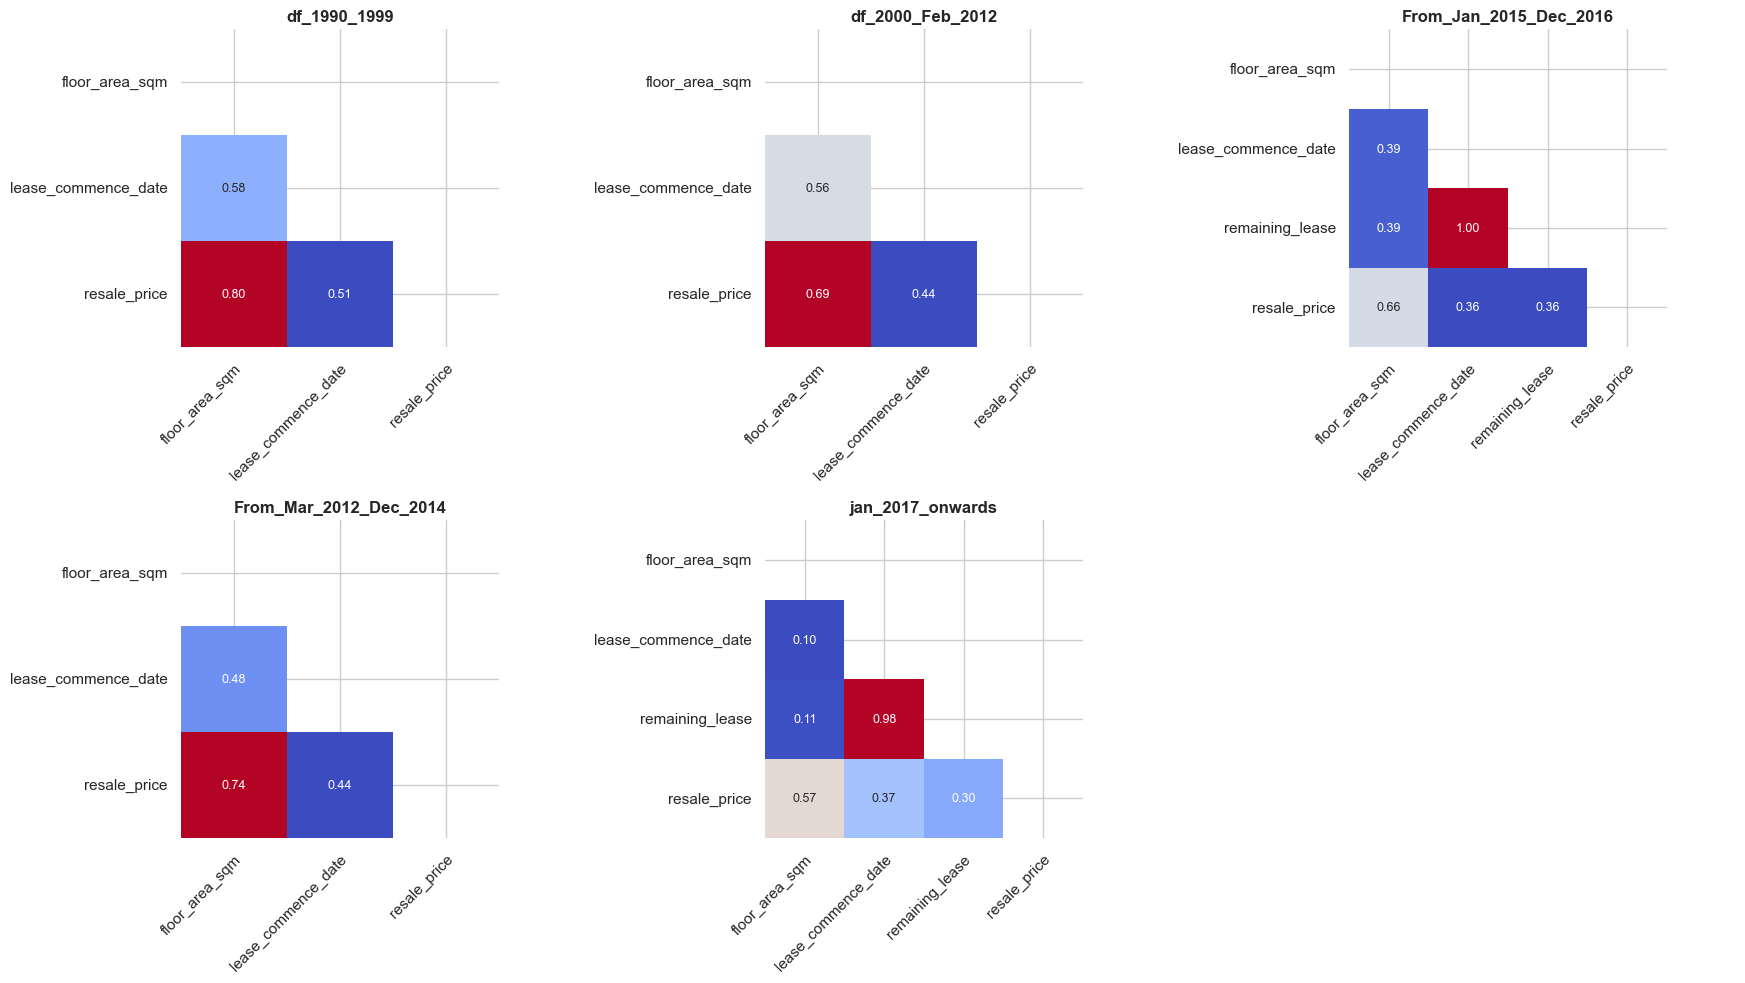

In [90]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten() 

dfs_activos = [nombre for nombre in nombres_dfs if nombre in globals()]

for i, ax in enumerate(axes):
    if i < len(dfs_activos):
        nombre = dfs_activos[i]
        df = globals()[nombre]
        
        df_num = df.select_dtypes(include=['number'])
        
        if not df_num.empty:
            corr = df_num.corr()

            mask = np.triu(np.ones_like(corr, dtype=bool))
            
            sns.heatmap(
                corr, 
                mask=mask, 
                annot=True,      
                fmt=".2f",       
                cmap='coolwarm',  
                cbar=False,       
                square=True, 
                ax=ax, 
                annot_kws={"size": 9} 
            )
            
            ax.set_title(f'{nombre}', fontsize=12, fontweight='bold')
            
            ax.set_xticklabels(
                ax.get_xticklabels(), 
                rotation=45, 
                ha='right', 
                rotation_mode='anchor'
            )
            # -------------------------
    
            ax.tick_params(axis='y', rotation=0) 
        else:
            ax.set_title(f'{nombre}: Sin datos numéricos', fontsize=10)
            ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()

La variable ``floor_area_sqm`` ha sido históricamente el factor numérico que más impacta en el precio final. Sin embargo, se aprecia que su correlación va bajando con los años.

Otra conclusión bastante llamativa que refleja la realidad del presente es que en los años 90, la correlación entre ``floor_area_sqm`` y ``lease_commence_date`` era de 0.58, lo que significa que los edificios más nuevos que se construían solían ser notablemente más grandes. Sin embargo, en 2017 y en adelante, esta correlación se desploma a 0.10 (prácticamente nula). Esto indica que los pisos nuevos ya no son necesariamente más grandes. Se construyen pisos modernos de todos los tamaños.

En el gráfico de 2015-2016 y 2017 onwards vemos que ``lease_commence_date`` y ``remaining_lease`` tienen una correlación perfecta de 1.00 (o casi perfecta en el caso de 2017). Esto es completamente lógico: los años de contrato que le quedan a un piso se calculan restando el año actual menos el año de inicio. Deberemos tener esto en cuenta para los modelos, ya que son la misma variable, por lo que **deberemos eliminar una de las dos**.

# 4. Modelado Inicial

Como modelo base, planteamos uno haciendo uso de H2O.

**H2O** es una plataforma de software de código abierto diseñada para el aprendizaje automático distribuido, escalable y de alto rendimiento. A diferencia de las librerías tradicionales, que operan en entornos monohilo o limitados por la memoria RAM de Python (como Scikit-Learn), H2O se ejecuta sobre un **clúster** optimizado en **Java**. Esto le permite realizar cálculos en paralelo utilizando hilos eficientes, gestionar grandes volúmenes de datos mediante compresión en memoria (*In-Memory Column-Compressed*) y conectarse con arquitecturas de Big Data.

**H2O AutoML** es la solución de Aprendizaje Automático Automatizado integrada en la plataforma. Su función es automatizar el ciclo de vida del modelado predictivo dentro de un límite de tiempo o restricciones computacionales especificadas por el usuario. El proceso automatizado incluye:

- Preprocesamiento e imputación automática de datos.

- Codificación de variables categóricas (*Target Encoding* y *One-Hot Encoding*).

- Entrenamiento, sintonización (*tuning*) y validación cruzada de múltiples familias de algoritmos en paralelo.

- Construcción de una tabla de clasificación o *Leaderboard* para evaluar y ordenar las soluciones basándose en métricas optimizadas (como RMSE o $R^2$).

Es muy importante tener en cuenta, a la hora de plantear modelos en este caso, que los datos dependen del tiempo, por lo que los splits de datos deben hacerse cronológicamente y no aleatoriamente, ya que **de lo contrario tendríamos Data Leakage**, pues estaríamos entrenando con datos del futuro. Lo mismo sucede con la validación cruzada, por lo que usaremos ``nfolds=0`` para no aleatorizar la muestra de datos. 

In [91]:
import h2o
from h2o.automl import H2OAutoML

# Forzar codificación UTF-8
os.environ["PYTHONIOENCODING"] = "utf-8"
os.environ["JAVA_TOOL_OPTIONS"] = "-Dfile.encoding=UTF8"




# FUNCIONES MAESTRAS
#--------------------------------------------------------------------------------


def H2O_Automl(data, nombre_subset="Dataset"):
    """
    Ejecuta AutoML usando la librería H2O para predecir la variable objetivo 'resale_price'.

    Esta función está optimizada para datos con componente temporal. Para 
    evitar el filtrado de información futura (data leakage), realiza una división 
    secuencial de los datos (70% Entrenamiento, 15% Validación, 15% Test) en lugar 
    de una aleatoria. Por la misma razón, se desactiva la validación cruzada (nfolds=0).

    Args:
        data (pandas.DataFrame): El conjunto de datos de entrada. Debe incluir la 
            variable objetivo 'resale_price'. Si contiene una columna llamada 'Date', 
            el dataset se ordenará cronológicamente de forma automática.
        nombre_subset (str, opcional): Nombre o identificador del subconjunto de datos 
            que se mostrará en los prints de consola. Por defecto es "Dataset".

    Returns:
        list: Una lista con 6 elementos que contiene los resultados y métricas del modelo:
            [0] lb_df (pandas.DataFrame): El leaderboard de todos los modelos entrenados.
            [1] var_import (pandas.DataFrame | str): La importancia de las variables del 
                modelo ganador (o un mensaje de error si el modelo no lo soporta).
            [2] err_test_rmse (float): El error RMSE obtenido en el conjunto de test.
            [3] r2_valid (float): El coeficiente R² obtenido en validación.
            [4] r2_test (float): El coeficiente R² obtenido en el conjunto de test.
            [5] model_id (str): El identificador único en H2O del modelo ganador.
    """

    # Inicializar H2O
    h2o.init()
    h2o.remove_all() # Liberamos memoria en cada ejecución
    h2o.no_progress() 
    
    # Ordenamos cronológicamente por si acaso
    if 'Date' in data.columns:
        data = data.sort_values(by='Date').reset_index(drop=True)
    
    # SPLIT (70% Train, 15% Valid, 15% Test). No hacemos el SPLIT aleatorio ya que los datos tienen una componente temporal muy importante
    n_filas = len(data)
    idx_train = int(n_filas * 0.70)
    idx_valid = int(n_filas * 0.85)
    
    # Cortamos el dataset respetando el orden temporal
    df_train = data.iloc[:idx_train]
    df_valid = data.iloc[idx_train:idx_valid]
    df_test  = data.iloc[idx_valid:]
    
    # Imprimimos los rangos para verificar que no hay saltos en el tiempo
    if 'Date' in data.columns:
        print(f"    Train: {df_train['Date'].min().date()} a {df_train['Date'].max().date()}")
        print(f"    Valid: {df_valid['Date'].min().date()} a {df_valid['Date'].max().date()}")
        print(f"    Test:  {df_test['Date'].min().date()}  a {df_test['Date'].max().date()}\n")

    # Convertimos a H2O
    train = h2o.H2OFrame(df_train)
    valid = h2o.H2OFrame(df_valid)
    test  = h2o.H2OFrame(df_test)
    
    # Definimos las variables objetivo y predictoras
    y = "resale_price" # Objetivo
    x = [col for col in train.columns if col != y] # Features

    # Configurar y entrenar el AutoML
    aml = H2OAutoML(
        max_runtime_secs=200, # Pasados 200 segundos, el proceso se detiene
        max_models=10, # limitamos a 10 modelos
        stopping_metric="RMSE",  # Early stopping usando el RMSE (raíz del error cuadrático medio)
        exclude_algos=["GLM", "StackedEnsemble"], # Excluimos GLM (Lineales Generalizados) y Ensembles
        stopping_tolerance=0.1, # tolerancia relativa de early stopping (10 %). Si el RMSE es menor al 10% durante stopping_rounds consecutivos se detiene
        stopping_rounds=4, # Número de rondas de scoring sin mejora significativa (según la stopping_tolerance) tras las cuales se detiene
        seed=12345, # Reproducibilidad
        sort_metric="RMSE", # Leaderboard se ordena por RMSE
        nfolds=0 # No podemos aplicar pliegues para la validación cruzada porque entonces la muestra sería aleatoria, rompiendo la componente temporal (orden cronológico) de los datos
    )
    
    # Entrenar modelo. Aplicamos las varaibles que acabamos de definir
    aml.train(x=x, # Features
              y=y, # Target
              training_frame=train, 
              validation_frame=valid,
              leaderboard_frame=valid) # El conjunto de test debe permanecer completamente aislado hasta el final, para obtener una evaluación insesgada del modelo ya elegido 
    
    # Obtener el leaderboard y modelo ganador
    lb_df = aml.leaderboard.as_data_frame()
    best_mod = aml.leader
    
    # --- EXTRACCIÓN DE MÉTRICAS DEL MEJOR MODELO ---
    perf_valid = best_mod.model_performance(valid)
    r2_valid = perf_valid.r2()
    perf_test = best_mod.model_performance(test)
    err_test_rmse = perf_test.rmse()
    r2_test = perf_test.r2()

    print(f"\n MODELO GANADOR para {nombre_subset}: {best_mod.model_id}")
    print(f"   -> [Conjunto Validación] R²: {r2_valid:.4f}")
    print(f"   -> [Conjunto Test]       R²: {r2_test:.4f} | RMSE: {err_test_rmse:.2f}")
    
    # Variables Importantes del Modelo Ganador
    try:
        var_import = best_mod.varimp(use_pandas=True)
    except Exception:
        var_import = "Este tipo de modelo no soporta la importancia de variables directa."
    
    return [lb_df, var_import, err_test_rmse, r2_valid, r2_test, best_mod.model_id]



# Función para visualizar resultados
#-----------------------------------------------
def var_import_plot(var_import, nombre_dataset):
    """
    Genera un gráfico de barras horizontal con las variables más y menos importantes
    del modelo ganador.

    Parameters
    ----------
    var_import : pandas.DataFrame or str
        DataFrame con las columnas 'variable' y 'scaled_importance', tal como lo
        devuelve H2O para la importancia de variables, o un mensaje de error
        (str) si el modelo no soporta este cálculo.
    nombre_dataset : str
        Nombre descriptivo del conjunto de datos, incluido en el título del gráfico.

    Returns
    -------
    None
        Muestra el gráfico por pantalla. Si var_import es un string, solo imprime
        el mensaje y termina.
    """

    if isinstance(var_import, str):
        print(var_import)
        return
    
    df_top10 = var_import.head(10).copy()
    df_bottom3 = var_import.tail(3).copy()
    
    df_combinado = pd.concat([df_top10, df_bottom3]).drop_duplicates(subset=['variable'])
    
    df_combinado = df_combinado.sort_values(by="scaled_importance", ascending=True)
    
    bottom_vars = df_bottom3['variable'].tolist()
    colores = ["crimson" if var in bottom_vars else "royalblue" for var in df_combinado['variable']]
    
    fig = plt.figure(figsize=(10, max(6, len(df_combinado) * 0.4)), facecolor='white', edgecolor='none') 
    fig.patch.set_facecolor('white')
    fig.patch.set_alpha(1.0) 
    
    sns.set_theme(style="whitegrid", rc={
        "axes.facecolor": "white", 
        "figure.facecolor": "white",
        "savefig.facecolor": "white"
    }) 
    
    # Dibujamos el gráfico
    ax = sns.barplot(data=df_combinado, x="scaled_importance", y="variable", palette=colores, hue="variable", legend=False)
    
    ax.set_facecolor('white')
    
    titulo = f"Variables Importantes del Modelo Ganador\n(Top 10 Más y Top 3 Menos Importantes)\nDataset: {nombre_dataset}"
    plt.title(titulo, fontsize=14, fontweight="bold", color="black", loc="left", pad=15)
    plt.xlabel("Importancia Escalada", fontsize=12, fontweight="bold", color="black")
    plt.ylabel("Variable", fontsize=12, fontweight="bold", color="black")
    
    plt.xticks(fontsize=11, color="black")
    plt.yticks(fontsize=11, fontweight="bold", color="black")
    
    plt.subplots_adjust(left=0.25)
    plt.tight_layout()
    plt.show()

Entrenar un modelo para cada dataset individualmente no tiene mucho sentido si el objetivo es predecir ``resale_price``, ya que ese modelo no aprenderá la influencia del paso del tiempo en los precios (inflación, por ejemplo, y cambios en las tendencias urbanísticas).
Entrenamos por tanto un modelo con todos los datasets conjuntos. 

## 4.1. Modelo Inicial Base con H2O. Dataset conjunto

En primer lugar, podemos eliminar la variable con correlación 1 del dataset de 2015 y 2017 que, además, es justo esa variable la que difería del resto de datasets. 
Aunque AutoML gestiona los nulos, incluir esta variable o no no aportará mucho, pues está altamente correlacionada con otras varaibles, tal y como hemos visto en el EDA Multivariante.

In [92]:
From_Jan_2015_Dec_2016 = From_Jan_2015_Dec_2016.drop('remaining_lease', axis = 1)
jan_2017_onwards = jan_2017_onwards.drop('remaining_lease', axis = 1)

Creamos un diccionario para ir guardando todos los modelos y compararlos al final del proyecto.

In [93]:
comparador_modelos_finales = {}

Para el modelo base, simplemente unimos todos los datasets y ejecutamos H2O, para ver qué pasa.

In [94]:
# Juntamos todos
lista_dfs = [globals()[nombre] for nombre in nombres_dfs if nombre in globals()]

df_completo = pd.concat(lista_dfs, ignore_index=True)
df_completo = df_completo.iloc[pd.to_datetime(df_completo['Date'], format='%Y-%m', errors='coerce').argsort()]
df_completo.reset_index(drop=True, inplace=True)

print(f" Dimensiones totales: {df_completo.shape[0]:,} filas y {df_completo.shape[1]} columnas.")
print(f" Rango temporal: desde {df_completo['Date'].min()} hasta {df_completo['Date'].max()}")

 Dimensiones totales: 979,258 filas y 10 columnas.
 Rango temporal: desde 1990-01-01 00:00:00 hasta 2026-06-01 00:00:00


Verificamos, por seguridad, que al unir los datasets no hemos perdido datos:

In [95]:
utils.resumen_nulos_ceros(df_completo)

,variable_type,variable,n_missing,n_missing_perc,n_zeros,n_zeros_perc
0,datetime64[ns],Date,0,0.000000,0,0.000000
6,float64,floor_area_sqm,0,0.000000,0,0.000000
9,float64,resale_price,0,0.000000,0,0.000000
8,int64,lease_commence_date,0,0.000000,0,0.000000
1,object,town,0,0.000000,0,0.000000
2,object,flat_type,0,0.000000,0,0.000000
5,object,storey_range,0,0.000000,0,0.000000
7,object,flat_model,0,0.000000,0,0.000000
3,string,block,0,0.000000,0,0.000000
4,string,street_name,0,0.000000,0,0.000000


Procedemos con el entrenamiento:

In [96]:
# Nos aseguramos de que el diccionario genérico exista
if 'comparador_modelos_finales' not in globals():
    comparador_modelos_finales = {}

EJECUTAR = 0  

if EJECUTAR == 1:
    nombre_dataset = "Histórico_Completo"

    # Llamamos a la función. Recordamos que esta función es la que ejecuta el modelo y devuelve todas las métricas y gráficas.
    resultados_globales = H2O_Automl(data=df_completo, nombre_subset=nombre_dataset)

    # Desempaquetamos los resultados
    (lb_df_global, 
    var_import_global, 
    err_test_rmse_global, 
    r2_valid_global, 
    r2_test_global, 
    best_mod_id_global) = resultados_globales

    # GUARDADO GENÉRICO: Usamos el nombre del ALGORITMO como clave principal
    comparador_modelos_finales['H2O_AutoML_Baseline'] = {
        'dataset_usado': nombre_dataset,
        'leaderboard': lb_df_global,
        'importancia_variables': var_import_global,
        'RMSE_test': err_test_rmse_global,
        'R2_valid': r2_valid_global,
        'R2_test': r2_test_global,
        'mejor_modelo_id': best_mod_id_global
    }

    # Mostramos resultados
    print("\n Ranking de Modelos (Leaderboard) Global:")
    display(lb_df_global.head(5))

    var_import_plot(var_import=var_import_global, nombre_dataset=nombre_dataset)

    # Guardamos el modelo físico
    modelo_final_h2o = h2o.get_model(best_mod_id_global)
    ruta_guardado = h2o.save_model(model=modelo_final_h2o, path="./modelo_H2O_Baese_Global", force=True)
    print(f"\n Modelo guardado con éxito en:\n{ruta_guardado}")

else:
    print("Entrenamiento del modelo global omitido (Interruptor EJECUTAR = 0).")

Entrenamiento del modelo global omitido (Interruptor EJECUTAR = 0).


Como vemos, el mejor modelo que arroja H2O es un GBM (*Gradient Boosting Machine*) con un $R^2 = 0.7339$ en validación y un $R^2 = 0.3556$ en test (lo cual es lógico); y un RMSE de $152328.98$.

Por otro lado, vemos que las varaibles más importantes son `Date`, `floor_area_sqm y `flat_type`.

A partir de ahora, el objetivo es superar estos resultados con los cambios que hagamos.

### 4.1.1. Arreglo de variables categóricas

Como vimos en el EDA, aunque todos los datasets tengan las mismas variables categóricas, no todos los niveles son iguales. 

El mayor problema lo tenemos en las variables `flat_model` y `flat_type` ya que, en general, los niveles de las variables sí que son los mismos para todos los datasets, pero están escritos de formas diferentes.

In [97]:
# Normalizamos todas las variables categóricas en df_completo
columnas_categoricas = [col for col, tipo in dicc_tipos.items() if tipo == 'category']


for col in columnas_categoricas:
    if col not in df_completo.columns:
        print(f"   '{col}' — no encontrada en df_completo, omitida.\n")
        continue

    n_antes = df_completo[col].nunique()

    df_completo[col] = (
        df_completo[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace('-', ' ', regex=False) 
        .astype('category')
    )

    n_despues = df_completo[col].nunique()
    reduccion = n_antes - n_despues

    estado = f"   '{col}'"
    detalle = f"{n_antes} → {n_despues} niveles"
    nota    = f"   (-{reduccion} duplicados eliminados)" if reduccion > 0 else "   (sin cambios)"
    print(f"{estado:<35} {detalle}{nota}")


   'town'                           27 → 27 niveles   (sin cambios)
   'flat_type'                      8 → 7 niveles   (-1 duplicados eliminados)
   'flat_model'                     34 → 21 niveles   (-13 duplicados eliminados)
   'storey_range'                   25 → 25 niveles   (sin cambios)


Entrenamos de nuevo con los cambios:

In [98]:
# Nos aseguramos de que el diccionario genérico exista
if 'comparador_modelos_finales' not in globals():
    comparador_modelos_finales = {}

EJECUTAR = 0  

if EJECUTAR == 1:
    nombre_dataset = "Histórico_Completo_Vars_Cat"

    resultados_globales = H2O_Automl(data=df_completo, nombre_subset=nombre_dataset)

    (lb_df_global, 
     var_import_global, 
     err_test_rmse_global, 
     r2_valid_global, 
     r2_test_global, 
     best_mod_id_global) = resultados_globales
    
    comparador_modelos_finales['H2O_AutoML_Vars_Cat_Arreglo'] = {
        'dataset_usado': nombre_dataset,
        'leaderboard': lb_df_global,
        'importancia_variables': var_import_global,
        'RMSE_test': err_test_rmse_global,
        'R2_valid': r2_valid_global,
        'R2_test': r2_test_global,
        'mejor_modelo_id': best_mod_id_global
    }

    print("\n Ranking de Modelos (Leaderboard) Global:")
    display(lb_df_global.head(5))

    var_import_plot(var_import=var_import_global, nombre_dataset=nombre_dataset)

    modelo_final_h2o = h2o.get_model(best_mod_id_global)
    ruta_guardado = h2o.save_model(model=modelo_final_h2o, path="./modelo_H2O_Baese_Global_Vars_Cat", force=True)
    print(f"\n Modelo guardado con éxito en:\n{ruta_guardado}")

else:
    print("Entrenamiento del modelo global omitido (Interruptor EJECUTAR = 0).")

Entrenamiento del modelo global omitido (Interruptor EJECUTAR = 0).


Vemos que, con los cambios realizados, se parecia una ligera mejoría, ya que hemos aumentado el $R^2$ tanto en validación como en test y hemos reducido el RMSE. También ha  variado ligeramente la importancia de las variables.

### 4.1.2. Eliminamos Date. Probamos

Veamos qué pasa si eliminamos la varaible `Date`. Deberíamos apreciar un gran empeoramiento de los resultados.

In [99]:
df_completo_no_date = df_completo.drop(columns=['Date'])

In [100]:
if 'comparador_modelos_finales' not in globals():
    comparador_modelos_finales = {}


EJECUTAR = 0  

if EJECUTAR == 1:
    nombre_dataset = "Histórico_Completo_No_Date"

    resultados_globales = H2O_Automl(data=df_completo_no_date, nombre_subset=nombre_dataset)

    (lb_df_global, 
     var_import_global, 
     err_test_rmse_global, 
     r2_valid_global, 
     r2_test_global, 
     best_mod_id_global) = resultados_globales

    comparador_modelos_finales['H2O_AutoML_No_Date'] = {
        'dataset_usado': nombre_dataset,
        'leaderboard': lb_df_global,
        'importancia_variables': var_import_global,
        'RMSE_test': err_test_rmse_global,
        'R2_valid': r2_valid_global,
        'R2_test': r2_test_global,
        'mejor_modelo_id': best_mod_id_global
    }

    print("\n Ranking de Modelos (Leaderboard) Global:")
    display(lb_df_global.head(5))

    var_import_plot(var_import=var_import_global, nombre_dataset=nombre_dataset)

    modelo_final_h2o = h2o.get_model(best_mod_id_global)
    ruta_guardado = h2o.save_model(model=modelo_final_h2o, path="./modelo_H2O_Sin_Date", force=True)
    print(f"\n Modelo guardado con éxito en:\n{ruta_guardado}")

else:
    print("Entrenamiento del modelo global omitido (Interruptor EJECUTAR = 0).")

Entrenamiento del modelo global omitido (Interruptor EJECUTAR = 0).


Observamos cómo han caído drásticamente las métricas de resultados, como era de esperar. Además, obtenemos un $R^2 < 0$, lo que indica que, eliminando la variable temporal, el modelo es peor que adivinar simplemente la media del mes.

Obsérvese también que el modelo ganador en este caso ha sido una red neuronal.

A pesar de los malos resultados obtenidos, realizar esta prueba nos muestra las variables más importantes después de la fecha. 

## 4.3. Feature Engineering

### 4.3.1. Precio medio por ciudad del mes anterior

Para ayudar a los modelos, vamos a crear una nueva variable que calcule el precio medio de los inmuebles en el mes anterior, por ciudad, para poder eliminar de nuestros modelos la variable `Date`:

In [101]:
df_proxy = df_completo.copy()
df_proxy['Date'] = pd.to_datetime(df_proxy['Date'], errors='coerce')

# Creamos una columna 'mes' (primer día del mes) para agrupar
df_proxy['mes'] = df_proxy['Date'].dt.to_period('M').dt.to_timestamp()

# Media mensual por town y mes
medias_mensuales = (
    df_proxy.groupby(['town', 'mes'])['resale_price']
    .mean()
    .reset_index()
    .rename(columns={'resale_price': 'precio_medio_barrio_mes_anterior'})
)

# Desplazamos el mes un mes hacia el futuro: la media de febrero se etiqueta como marzo
medias_mensuales['mes'] = medias_mensuales['mes'] + pd.DateOffset(months=1)

# Hacemos el merge usando la columna 'mes' (no la fecha exacta)
df_completo_proxy = df_proxy.merge(medias_mensuales, on=['town', 'mes'], how='left')

# Eliminamos las filas donde no existe mes anterior (primer mes disponible)
df_completo_proxy = df_completo_proxy.dropna(subset=['precio_medio_barrio_mes_anterior']).reset_index(drop=True)

# Opcional: eliminamos la columna auxiliar 'mes' si no la necesitas
df_completo_proxy = df_completo_proxy.drop(columns=['mes'])

Entrenamos con el nuevo dataset creado:

In [102]:
if 'comparador_modelos_finales' not in globals():
    comparador_modelos_finales = {}

EJECUTAR = 0  

if EJECUTAR == 1:
    nombre_dataset = "Histórico_Completo_proxy"

    resultados_globales = H2O_Automl(data=df_completo_proxy, nombre_subset=nombre_dataset)

    (lb_df_global, 
     var_import_global, 
     err_test_rmse_global, 
     r2_valid_global, 
     r2_test_global, 
     best_mod_id_global) = resultados_globales

    comparador_modelos_finales['H2O_AutoML_Proxy'] = {
        'dataset_usado': nombre_dataset,
        'leaderboard': lb_df_global,
        'importancia_variables': var_import_global,
        'RMSE_test': err_test_rmse_global,
        'R2_valid': r2_valid_global,
        'R2_test': r2_test_global,
        'mejor_modelo_id': best_mod_id_global
    }

    print("\n Ranking de Modelos (Leaderboard) Global:")
    display(lb_df_global.head(5))

    var_import_plot(var_import=var_import_global, nombre_dataset=nombre_dataset)

    modelo_final_h2o = h2o.get_model(best_mod_id_global)
    ruta_guardado = h2o.save_model(model=modelo_final_h2o, path="./modelo_H2O_Proxy", force=True)
    print(f"\n Modelo guardado con éxito en:\n{ruta_guardado}")

else:
    print("Entrenamiento del modelo global omitido (Interruptor EJECUTAR = 0).")

Entrenamiento del modelo global omitido (Interruptor EJECUTAR = 0).


Como vemos, con esta nueva variable no hemos ganado nada. Ahora el modelo ganador es un Random Forest.

Ahora observamos que la variable más importante es la que acabamos de crear, seguida de `floor_area_sqm`. Esto nos hace pensar que ya estamos empezando a capturar la influencia del tiempo en los precios.

Vamos a intentar mejorarlo más.

### 4.3.2. Precio medio por ciudad del mes anterior, hace tres y hace 6. Lag

La idea ahora es crear un par más de variables que capturen los precios medios por ciudad no solo del mes inmadiatamente anterior (como en el subapartado anterior), sino los tres y seis meses anteriores. Probamos:

In [103]:
# Partimos de df_completo_proxy (ya tiene 'precio_medio_barrio_mes_anterior')
df = df_completo_proxy.copy()

# Aseguramos tipos y creamos variables de mes
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Month'] = df['Date'].dt.to_period('M')
df['Month_str'] = df['Month'].astype(str)

# Agregación mensual por town (solo necesaria para las móviles)
mensual_ciudad = (
    df.groupby(['town', 'Month'], observed=False)
      .agg(mean_price=('resale_price', 'mean'))
      .reset_index()
)
mensual_ciudad = mensual_ciudad.sort_values(['town', 'Month']).reset_index(drop=True)

# Función para calcular las medias móviles de los meses anteriores
def add_moving_lag_features(df_group):
    df_group = df_group.sort_values('Month')
    
    # Media móvil de 3 meses del mes anterior (t-1, t-2, t-3)
    df_group['precio_medio_barrio_3mes_anterior'] = (
        df_group['mean_price']
        .rolling(window=3, min_periods=1)
        .mean()
        .shift(1)
    )
    
    # Media móvil de 6 meses del mes anterior (t-1 .. t-6)
    df_group['precio_medio_barrio_6mes_anterior'] = (
        df_group['mean_price']
        .rolling(window=6, min_periods=1)
        .mean()
        .shift(1)
    )
    
    return df_group

# Aplicamos la función a cada ciudad
mensual_ciudad = (
    mensual_ciudad
    .groupby('town', group_keys=False, observed=False)
    .apply(add_moving_lag_features)
    .reset_index(drop=True)
)

# Creamos la columna 'Month_str' para poder hacer el merge
mensual_ciudad['Month_str'] = mensual_ciudad['Month'].astype(str)

# Unimos solo los nuevos lags al dataset original
columnas_lag = [
    'town', 'Month_str',
    'precio_medio_barrio_3mes_anterior',
    'precio_medio_barrio_6mes_anterior'
]

df_lags = df.merge(
    mensual_ciudad[columnas_lag],
    on=['town', 'Month_str'],
    how='left'
)

df_lags = df_lags.dropna(
    subset=['precio_medio_barrio_3mes_anterior', 'precio_medio_barrio_6mes_anterior']
)

# Eliminamos columnas auxiliares
df_lags = df_lags.drop(columns=['Month', 'Month_str'])

# Dataset final
df_completo_lags = df_lags  

# Para H2O eliminamos la fecha
df_completo_lags_h2o = df_completo_lags.drop(columns=['Date'], axis=1)

print(f"Tamaño final: {df_completo_lags_h2o.shape}")

Tamaño final: (976574, 12)


Comprobamos que el nuevo set de datos no tenga valores nulos, por si acaso:

In [104]:
utils.resumen_nulos_ceros(df_completo_lags)

,variable_type,variable,n_missing,n_missing_perc,n_zeros,n_zeros_perc
1,category,town,0,0.000000,0,0.000000
2,category,flat_type,0,0.000000,0,0.000000
5,category,storey_range,0,0.000000,0,0.000000
7,category,flat_model,0,0.000000,0,0.000000
0,datetime64[ns],Date,0,0.000000,0,0.000000
6,float64,floor_area_sqm,0,0.000000,0,0.000000
9,float64,resale_price,0,0.000000,0,0.000000
10,float64,precio_medio_barrio_mes_anterior,0,0.000000,0,0.000000
11,float64,precio_medio_barrio_3mes_anterior,0,0.000000,0,0.000000
12,float64,precio_medio_barrio_6mes_anterior,0,0.000000,0,0.000000


Con estas nuevas variables, lo que esperamos es que el modelo entienda esta tendencia al alza en los precios, tal y como puede verse en este ejemplo:

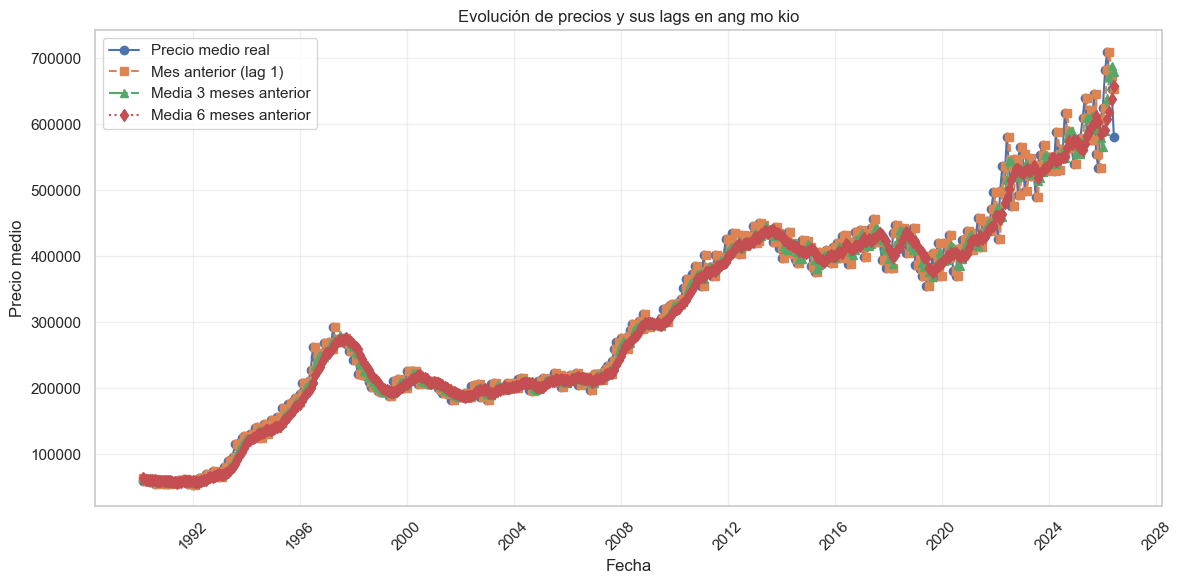

In [105]:
df_plot = df_completo_lags.copy()
df_plot['Month'] = df_plot['Date'].dt.to_period('M')

monthly_plot = (
    df_plot.groupby(['town', 'Month'])
    .agg({
        'resale_price': 'mean',
        'precio_medio_barrio_mes_anterior': 'first',
        'precio_medio_barrio_3mes_anterior': 'first',
        'precio_medio_barrio_6mes_anterior': 'first'
    })
    .reset_index()
)

monthly_plot['Month'] = monthly_plot['Month'].dt.to_timestamp()

# Elegimos una ciudad para el ejemplo
town_ejemplo = monthly_plot['town'].unique()[0]
df_town = monthly_plot[monthly_plot['town'] == town_ejemplo].copy()


plt.figure(figsize=(12, 6))
plt.plot(df_town['Month'], df_town['resale_price'], label='Precio medio real', marker='o')
plt.plot(df_town['Month'], df_town['precio_medio_barrio_mes_anterior'],
         label='Mes anterior (lag 1)', linestyle='--', marker='s')
plt.plot(df_town['Month'], df_town['precio_medio_barrio_3mes_anterior'],
         label='Media 3 meses anterior', linestyle='-.', marker='^')
plt.plot(df_town['Month'], df_town['precio_medio_barrio_6mes_anterior'],
         label='Media 6 meses anterior', linestyle=':', marker='d')

plt.title(f'Evolución de precios y sus lags en {town_ejemplo}')
plt.xlabel('Fecha')
plt.ylabel('Precio medio')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Ejecutamos:

In [106]:
if 'comparador_modelos_finales' not in globals():
    comparador_modelos_finales = {}

EJECUTAR = 0   

if EJECUTAR == 1:
    nombre_dataset = "Histórico_Completo_lags"

    resultados_globales = H2O_Automl(data=df_completo_lags_h2o, nombre_subset=nombre_dataset)

    (lb_df_global, 
     var_import_global, 
     err_test_rmse_global, 
     r2_valid_global, 
     r2_test_global, 
     best_mod_id_global) = resultados_globales

    comparador_modelos_finales['H2O_AutoML_Lags'] = {
        'dataset_usado': nombre_dataset,
        'leaderboard': lb_df_global,
        'importancia_variables': var_import_global,
        'RMSE_test': err_test_rmse_global,
        'R2_valid': r2_valid_global,
        'R2_test': r2_test_global,
        'mejor_modelo_id': best_mod_id_global
    }

    print("\n Ranking de Modelos (Leaderboard) Global:")
    display(lb_df_global.head(5))

    var_import_plot(var_import=var_import_global, nombre_dataset=nombre_dataset)

    # Guardar modelo físico (cambiamos la ruta para no sobrescribir el anterior)
    modelo_final_h2o = h2o.get_model(best_mod_id_global)
    ruta_guardado = h2o.save_model(model=modelo_final_h2o, path="./modelo_H2O_Lags", force=True)
    print(f"\n Modelo guardado con éxito en:\n{ruta_guardado}")

else:
    print("Entrenamiento del modelo con lags omitido (Interruptor EJECUTAR = 0).")

Entrenamiento del modelo con lags omitido (Interruptor EJECUTAR = 0).


Vemos que el modelo ha mejorado bastante con estas nuevas variables. 
El modelo ganador ahora es un Random Forset, con el que hemos aumentado el $R^2$ y disminuido el RMSE.

Sin embargo, para los futuros modelos, debemos tener en cuenta que, como estas nuevas variables están altamente correlacionadas entre sí (como se ve en la siguiente matriz de correlación), los modelos lineales que vamos a plantear, como Lasso y Ridge, no serán tan buenos, aunque estos dos, en concreto, tienen regularización L1 y L2, respectivamente.

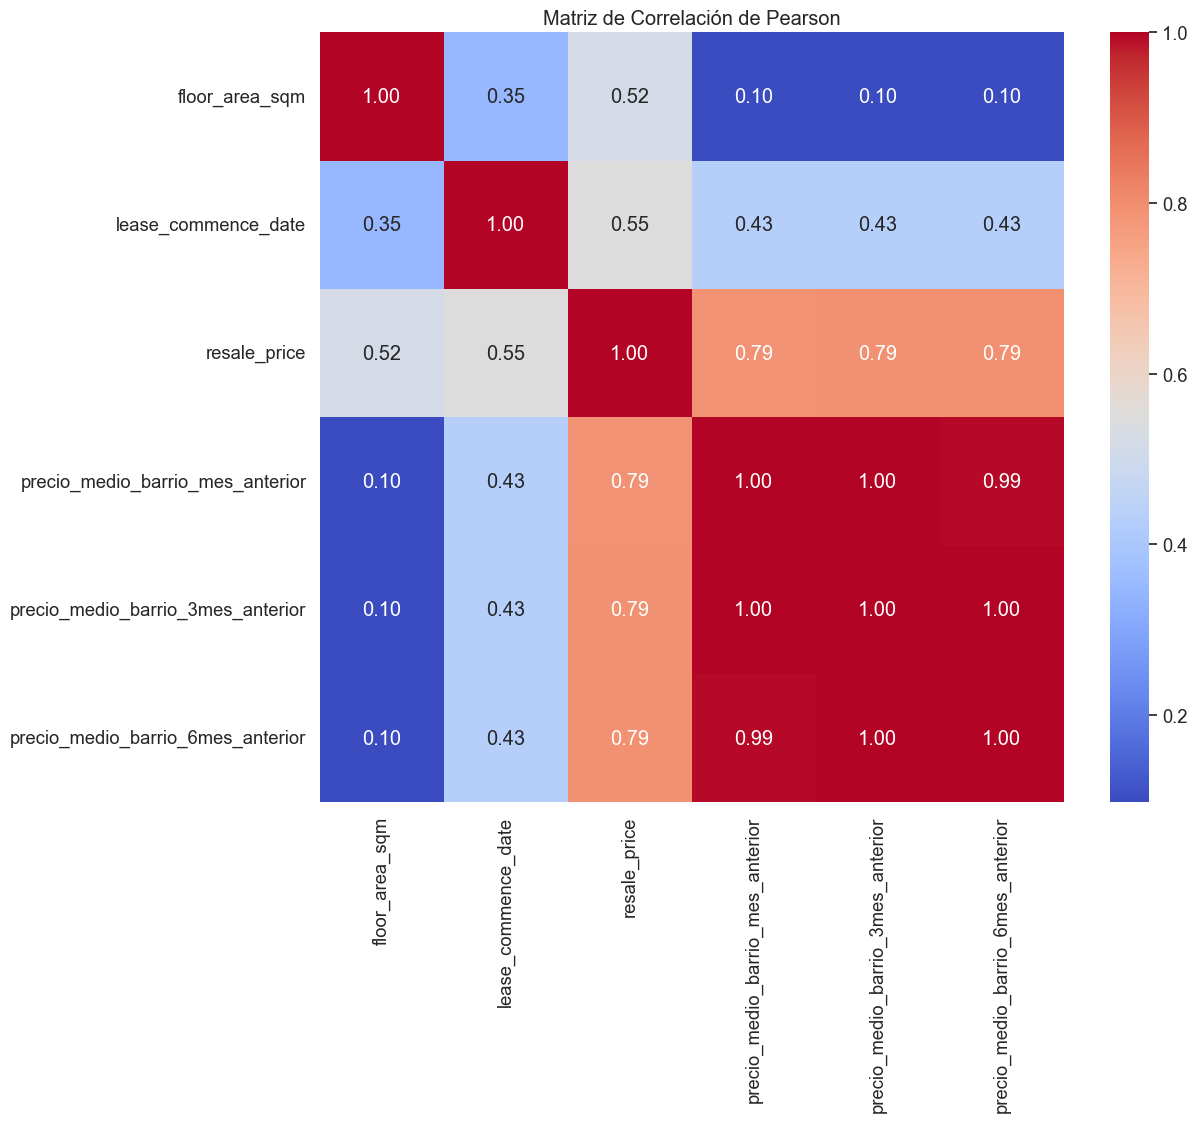

In [107]:
utils.corrplot(df_completo_lags)

Por otro lado, vamos a liminar las variables que ya no tienen importancia:

In [108]:
df_completo_lags = df_completo_lags.drop(columns=['block'])

Aunque `Date` ya no tiene importancia, por el momento la dejamos para asegurar el orden cronológico de los datos, y antes de entrenar los siguientes modelos la eliminaremos.

# 5. Modelado con Sklear, XGBoost y LightGBM

Con el dataset final, vamos a plantear más modelos, en principio definitivos.

Empezaremos por cargar las librerías que vamos a utilizar, crear la configuración inicial y el control de los modelos (definir las reglas del juego para evaluar y validar los modelos), y realizar la partición **cronológica** de los datos:

In [137]:
import os
import time
import joblib
import pickle

from sklearn.model_selection import TimeSeriesSplit, KFold, GridSearchCV 
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error 

# Importamos los modelos 
from sklearn.linear_model import Lasso, Ridge  
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, BaggingRegressor  
from xgboost import XGBRegressor 
from lightgbm import LGBMRegressor  
from catboost import CatBoostRegressor  



# CONFIGURACIÓN INICIAL Y CONTROL
# -----------------------------------------------------

ENTRENA = True 

if ENTRENA:
    # CONTROL: TimeSeriesSplit para evitar Data Leakage temporal
    cv_control = TimeSeriesSplit(n_splits=5) 
    
    # Métrica (Sklearn minimiza errores usando valores negativos)
    metrica = "neg_root_mean_squared_error"



# PARTICIÓN DE DATOS CRONOLÓGICA (80% pasado - 20% futuro)
# ----------------------------------------------------------

if ENTRENA:
    os.makedirs("./output", exist_ok=True)
    nombre_dataset = "Histórico_Completo_Lags"
    
    # Aseguramos que el dataset esté ordenado por fecha antes del corte
    df_modelo = df_completo_lags.sort_values(by='Date').reset_index(drop=True)
    
    # Separamos X e y (Eliminando la columna 'Date')
    y = df_modelo["resale_price"]
    X = df_modelo.drop(columns=["resale_price", "Date"]) # Eliminamos date ya que en realidad, como hemos visto, ya no pesa nada en los modelos
    
    # SPLIT CRONOLÓGICO SEGURO (80% Entrenamiento, 20% Test)
    n_filas = len(df_modelo)
    idx_corte = int(n_filas * 0.80)
    
    X_train_ds = X.iloc[:idx_corte]
    X_test_ds  = X.iloc[idx_corte:]
    y_train_ds = y.iloc[:idx_corte]
    y_test_ds  = y.iloc[idx_corte:]
    
    # Control en pantalla del split
    fecha_min_train = df_modelo['Date'].iloc[0].date()
    fecha_max_train = df_modelo['Date'].iloc[idx_corte - 1].date()
    fecha_min_test  = df_modelo['Date'].iloc[idx_corte].date()
    fecha_max_test  = df_modelo['Date'].iloc[-1].date()
    
    print(f" Estructura temporal de las particiones:")
    print(f"    ▪️ Train ({X_train_ds.shape[0]:,} filas): {fecha_min_train} a {fecha_max_train}")
    print(f"    ▪️ Test  ({X_test_ds.shape[0]:,} filas): {fecha_min_test} a {fecha_max_test}\n")
    
    
    ruta_archivo = f"./output/{nombre_dataset}_traintest_reg.pkl"
    with open(ruta_archivo, "wb") as f:
        pickle.dump((X_train_ds, X_test_ds, y_train_ds, y_test_ds), f)
        
    print(f" Particiones de '{nombre_dataset}' creadas y guardadas en .pkl")


 Estructura temporal de las particiones:
    ▪️ Train (781,259 filas): 1990-03-01 a 2018-10-01
    ▪️ Test  (195,315 filas): 2018-10-01 a 2026-06-01

 Particiones de 'Histórico_Completo_Lags' creadas y guardadas en .pkl


Antes de plantear los modelos y empezar a ejecutarlos, vamos a ver las características del equipo, así como la memoria RAM disponible. Si no tenemos mucha RAM disponible, relajaremos los hiperparámetros de los modelos.

In [138]:
import psutil

print(f"Núcleos físicos: {psutil.cpu_count(logical=False)}")
print(f"Núcleos lógicos: {psutil.cpu_count(logical=True)}")
print(f"RAM total: {psutil.virtual_memory().total / 1e9:.1f} GB")
print(f"RAM disponible: {psutil.virtual_memory().available / 1e9:.1f} GB")
print(f"Shape X_train: {X_train_ds.shape}")
print(f"Memoria de X_train: {X_train_ds.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Núcleos físicos: 4
Núcleos lógicos: 8
RAM total: 8.4 GB
RAM disponible: 2.5 GB
Shape X_train: (781259, 10)
Memoria de X_train: 89.9 MB


A continuación, se listan, junto con una breve explicación, los modelos que vamos a implementar. Además, para cada modelo, se indica el preprocesamiento de datos que necesitan, que será incorporado al pipeline.


1. **Modelos Lineales Regularizados**. Pertenecen a la familia de regresión lineal con penalización en la función de coste, lo que controla la complejidad y previene el sobreajuste.

    - **Lasso (Least Absolute Shrinkage and Selection Operator)**: Regresión lineal con regularización L1. Añade un término proporcional a la suma de los valores absolutos de los coeficientes. Tiende a producir soluciones dispersas, forzando coeficientes exactamente a cero, lo que realiza selección automática de características.
        *Ecuación:*  (Es una regresión lineal básica más un término de regularización)
        $$\min_{\boldsymbol{\beta}} \left\{ \frac{1}{2n} \sum_{i=1}^n \left( y_i - \beta_0 - \sum_{j=1}^p x_{ij}\beta_j \right)^2 + \lambda \sum_{j=1}^p |\beta_j| \right\}$$
        donde:  
        - $n$: número de observaciones (filas).  
        - $p$: número de características (predictores).  
        - $y_i$: valor real de la variable objetivo para la observación $i$.  
        - $x_{ij}$: valor del predictor $j$ en la observación $i$.  
        - $\beta_0$: intercepto (término constante).  
        - $\beta_j$: coeficiente asociado al predictor $j$.  
        - $\lambda$: hiperparámetro de regularización que controla la intensidad de la penalización L1.

        - **Preprocesamiento necesario**:  
            * Estandarización de las variables numéricas (media 0, desviación estándar 1) *para que la penalización actúe de forma equitativa sobre todos los coeficientes*.  
            * Imputación de valores faltantes (no los maneja de forma nativa).  
            * Codificación de variables categóricas (p. ej., one‑hot encoding) porque el modelo solo trabaja con entradas numéricas.  
            * Opcional: tratamiento de outliers (valores extremos), ya que los modelos lineales son sensibles a ellos.

    - **Ridge**: Regresión lineal con regularización L2. Penaliza la suma de los cuadrados de los coeficientes, contrayéndolos sin eliminarlos completamente. Es especialmente útil cuando hay multicolinealidad.
        *Ecuación:*  
        $$\min_{\boldsymbol{\beta}} \left\{ \frac{1}{2n} \sum_{i=1}^n \left( y_i - \beta_0 - \sum_{j=1}^p x_{ij}\beta_j \right)^2 + \lambda \sum_{j=1}^p \beta_j^2 \right\}$$
        donde:  
        - $n$: número de observaciones.  
        - $p$: número de características.  
        - $y_i$: valor real de la variable objetivo para la observación $i$.  
        - $x_{ij}$: valor del predictor $j$ en la observación $i$.  
        - $\beta_0$: intercepto.  
        - $\beta_j$: coeficiente asociado al predictor $j$.  
        - $\lambda$: hiperparámetro de regularización que controla la intensidad de la penalización L2.

        - **Preprocesamiento necesario**:  
            * Estandarización de las variables numéricas (misma razón que en Lasso).  
            * Imputación de valores faltantes.  
            * Codificación de variables categóricas.  
            * Recomendable tratamiento de outliers si existen.

    *Nota*: Se han probado estos dos modelos lineales aplicando *TransformedTargetRegressor* para hacerlos menos sensibles a outliers en el target y en floor_area_sqm,sin embargo, el rendimiento fue menor comparado con el modelo con las variables naturales, por lo que se elige ese modelo como final aunque, como veremos, tiene ligeramente al sobreajuste.

2. **Árbol de Decisión**

    - **CART (Classification and Regression Tree)**: Modelo no paramétrico basado en particiones binarias recursivas del espacio de entrada. Para regresión, minimiza la varianza dentro de cada nodo (MSE). Construye un único árbol interpretable, pero propenso al sobreajuste si no se controla su profundidad.
        *Ecuación:*  
        El árbol predice mediante:  
        $$\hat{f}(x) = \sum_{j=1}^J c_j \mathbf{1}_{\{x \in R_j\}}, \qquad c_j = \frac{1}{|R_j|} \sum_{i:\,x_i \in R_j} y_i$$
        donde:  
        - $J$: número total de hojas (nodos terminales) del árbol.  
        - $R_j$: región del espacio de entrada correspondiente a la hoja $j$.  
        - $c_j$: valor predicho para cualquier observación que caiga en la región $R_j$, igual a la media de los valores objetivo de entrenamiento en dicha región.  
        - $\mathbf{1}_{\{x \in R_j\}}$: función indicadora que vale 1 si $x$ pertenece a la región $R_j$ y 0 en caso contrario.  
        - $\hat{f}(x)$: predicción del modelo para una nueva observación $x$.

        - **Preprocesamiento necesario**:  
            * **No** necesita escalado ni normalización de las variables numéricas (las divisiones se basan en orden y no en magnitudes).  
            * Imputación de valores faltantes (la implementación estándar no los maneja automáticamente).  
            * Codificación de variables categóricas (one‑hot o label encoding; en scikit‑learn es obligatorio convertirlas a números).

3. **Métodos de Ensemble (Combinación de Múltiples Árboles)**. Agrupan múltiples modelos base, típicamente árboles de decisión, para reducir varianza y/o sesgo.

- **Bagging (Bootstrap Aggregating)**

    - **BaggingRegressor**: Entrena múltiples árboles de decisión en paralelo sobre muestras bootstrap del conjunto de datos original. La predicción final es el promedio de las predicciones individuales. Reduce la varianza sin aumentar el sesgo. Cuando se usan árboles profundos y se selecciona un subconjunto aleatorio de predictores en cada división, da lugar al conocido Random Forest; la implementación genérica `BaggingRegressor` sin submuestreo de características simplemente promedia árboles profundos sobre remuestras.
        *Ecuación:*  
        $$\hat{f}_{\text{bag}}(x) = \frac{1}{B} \sum_{b=1}^B \hat{f}^{*b}(x)$$
        donde:  
        - $B$: número de muestras bootstrap (número de modelos base entrenados).  
        - $\hat{f}^{*b}$: modelo (árbol de decisión) entrenado sobre la $b$-ésima muestra bootstrap.  
        - $\hat{f}_{\text{bag}}(x)$: predicción agregada para la observación $x$, obtenida como promedio de las predicciones individuales.

        - **Preprocesamiento necesario**:  
            * **No** necesita escalado.  
            * Imputación de valores faltantes (los árboles base no los manejan automáticamente en implementaciones estándar).  
            * Codificación de variables categóricas.

- **Boosting**. Construye árboles secuencialmente, donde cada nuevo modelo corrige los errores del anterior. Optimiza una función de pérdida mediante descenso de gradiente.

    - **XGBoost (eXtreme Gradient Boosting)**: Implementación altamente optimizada de gradient boosting. Incluye regularización L1/L2, paralelización, manejo de valores faltantes y pruning de árboles. Usa una aproximación de segundo orden de la pérdida para mayor precisión.
        *Ecuación:*  
        Modelo aditivo: $\hat{y}_i = \sum_{k=1}^K f_k(x_i)$, que se entrena minimizando la función objetivo:
        $$\mathcal{L} = \sum_{i=1}^n L(y_i, \hat{y}_i) + \sum_{k=1}^K \Omega(f_k), \quad \Omega(f) = \gamma T + \frac{1}{2}\lambda \|w\|^2$$
        donde:  
        - $\hat{y}_i$: predicción para la observación $i$, suma de las salidas de $K$ árboles.  
        - $K$: número total de árboles (iteraciones de boosting).  
        - $f_k$: $k$-ésimo árbol de decisión.  
        - $n$: número de observaciones.  
        - $L(y_i, \hat{y}_i)$: función de pérdida (por ejemplo, error cuadrático medio).  
        - $\Omega(f)$: término de regularización del árbol $f$.  
        - $T$: número de hojas del árbol $f$.  
        - $w$: vector de pesos (valores) de las hojas del árbol.  
        - $\|w\|^2$: suma de los cuadrados de los pesos de las hojas.  
        - $\gamma$: penalización por cada hoja adicional (controla la complejidad).  
        - $\lambda$: coeficiente de regularización L2 sobre los pesos de las hojas.  
        El entrenamiento usa una aproximación de segundo orden (Taylor) de la pérdida para calcular el gradiente y la hessiana.

        - **Preprocesamiento necesario**:  
            * **No** necesita escalado de variables numéricas.  
            * **No** requiere imputación de valores faltantes (el algoritmo aprende la dirección óptima para los datos ausentes).  
            * Necesita codificación de variables categóricas (one‑hot o label encoding; no hay soporte nativo profundo para categóricas en la mayoría de versiones).

    - **LightGBM (Light Gradient Boosting Machine)**: Basado en boosting de gradiente, introduce técnicas como *Gradient-based One-Side Sampling (GOSS)* y *Exclusive Feature Bundling (EFB)* para acelerar el entrenamiento y reducir el uso de memoria. Utiliza crecimiento de árboles por hojas (*leaf-wise*) en lugar de por niveles, lo que puede capturar patrones más complejos con menos nodos.
        *Ecuación:*  
        Modelo aditivo:  
        $$\hat{y}_i = \sum_{k=1}^K f_k(x_i)$$
        donde:  
        - $\hat{y}_i$: predicción final para la observación $i$.  
        - $K$: número de árboles (iteraciones).  
        - $f_k$: árbol de la iteración $k$, entrenado secuencialmente minimizando la pérdida (mediante descenso de gradiente) y aplicando GOSS y EFB para eficiencia.

        - **Preprocesamiento necesario**:  
            * **No** necesita escalado.  
            * **No** requiere imputación de valores nulos (maneja internamente los missing values).  
            * **Soporta variables categóricas nativamente**, por lo que **no** es necesario hacer one‑hot encoding; basta con indicar las columnas categóricas durante el entrenamiento (pueden estar codificadas como enteros).

    - **CatBoost (Categorical Boosting)**: Algoritmo de boosting con soporte nativo para variables categóricas, utilizando *target encoding* con un esquema de permutación para evitar sobreajuste (*ordered boosting*). Maneja automáticamente características categóricas sin preprocesamiento manual y es robusto a hiperparámetros por defecto.
        *Ecuación:*  
        Modelo aditivo:  
        $$\hat{y}_i = \sum_{k=1}^K f_k(x_i)$$
        donde:  
        - $\hat{y}_i$: predicción para la observación $i$.  
        - $K$: número de árboles.  
        - $f_k$: árbol entrenado en la iteración $k$ utilizando *ordered boosting* y transformaciones de *target encoding* que preservan la distribución de los datos.

        - **Preprocesamiento necesario**:  
            * **No** necesita escalado de variables numéricas.  
            * **No** requiere imputación de valores faltantes (el modelo los gestiona de forma automática).  
            * **No** necesita codificación de variables categóricas, ya que las trata internamente (admite tanto enteros como strings).

De igual forma que procedimos con H2O, creamos una "función maestra", que utilizarmos para ejecutar cada modelo. Esta función incluye el pipeline con los preprocesados necesarios. Se ha incluido el preprocesamiento para valores nulos, aunque en este caso nuestros datos son completos.

In [139]:
def entrenar_y_guardar(nombre_dataset, X_train, y_train, X_test, y_test, nombre_modelo, config_modelo, cv_control, metrica):
    """
    Entrena un modelo de machine learning (dado, según un diccionario de modelos) utilizando un pipeline de preprocesamiento 
    (especializado para cada modelo del diccionario) y búsqueda de hiperparámetros con GridSearchCV, luego guarda el mejor modelo
    entrenado y actualiza el diccionario global `comparador_modelos_finales` con las métricas y resultados obtenidos.

    Parameters
    ----------
    nombre_dataset : str
        Nombre identificador del conjunto de datos, usado para la ruta de guardado.
    X_train : pd.DataFrame
        Características de entrenamiento.
    y_train : pd.Series o array-like
        Variable objetivo de entrenamiento.
    X_test : pd.DataFrame
        Características de prueba.
    y_test : pd.Series o array-like
        Variable objetivo de prueba.
    nombre_modelo : str
        Nombre con el que se identificará el modelo (ej. "XGBoost", "LightGBM").
    config_modelo : dict
        Diccionario con la configuración del modelo. Debe contener las claves
        "estimador" (instancia del modelo) y "parametros" (diccionario para
        la grilla de parámetros de GridSearchCV).
    cv_control : int o cross-validator
        Estrategia de validación cruzada para GridSearchCV.
    metrica : str o callable
        Métrica de scoring a optimizar por GridSearchCV (ej. 'neg_root_mean_squared_error').

    Returns
    -------
    sklearn.model_selection.GridSearchCV
        El objeto GridSearchCV entrenado (el mejor estimador se encuentra en
        el atributo `best_estimator_`).

    Side effects
    ------------
    - Imprime el rendimiento del modelo (R² train/test, RMSE test, tiempo y mejores parámetros).
    - Guarda el modelo entrenado (GridSearchCV completo) en un archivo .joblib en
      la ruta `./output/{nombre_dataset}_modelo_{nombre_modelo}.joblib`.
    - Actualiza la variable global `comparador_modelos_finales` con un registro
      del modelo, incluyendo RMSE test, R² train (CV), R² test y los mejores parámetros.
    """
    
    columnas_numericas = X_train.select_dtypes(include=['number']).columns.tolist()
    columnas_categoricas = X_train.select_dtypes(exclude=['number']).columns.tolist()
    
   
    # CONSTRUCCIÓN DEL PREPROCESADOR SEGÚN EL MODELO
    # -------------------------------
    transformers = []
    
    # Modelos que requieren imputación + escalado + one-hot
    if nombre_modelo in ['Lasso', 'Ridge']:
        if columnas_numericas:
            num_pipe = Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ])
            transformers.append(('num', num_pipe, columnas_numericas))
        if columnas_categoricas:
            cat_pipe = Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
            ])
            transformers.append(('cat', cat_pipe, columnas_categoricas))
        # Modelos que requieren imputación (sin escalado) + one-hot
        elif nombre_modelo in ['CART', 'Bagging']:
            if columnas_numericas:
                num_pipe = Pipeline([
                    ('imputer', SimpleImputer(strategy='median'))
                ])
                transformers.append(('num', num_pipe, columnas_numericas))
            if columnas_categoricas:
                cat_pipe = Pipeline([
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
                ])
                transformers.append(('cat', cat_pipe, columnas_categoricas))
    
    # XGBoost: maneja nulos en numéricas, pero requiere one‑hot (imputamos categóricas con constante)
    elif nombre_modelo == 'XGBoost':
        if columnas_numericas:
            transformers.append(('num', 'passthrough', columnas_numericas))
        if columnas_categoricas:
            cat_pipe = Pipeline([
                ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
                ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
            ])
            transformers.append(('cat', cat_pipe, columnas_categoricas))
    
    # LightGBM y CatBoost: sin escalado, imputación constante en categóricas, codificación ordinal
    elif nombre_modelo in ['LightGBM', 'CatBoost']:
        if columnas_numericas:
            transformers.append(('num', 'passthrough', columnas_numericas))
        if columnas_categoricas:
            cat_pipe = Pipeline([
                ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
                ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1, dtype=int))
            ])
            transformers.append(('cat', cat_pipe, columnas_categoricas))
    
    else:
        # Fallback genérico (por seguridad)
        if columnas_numericas:
            transformers.append(('num', StandardScaler(), columnas_numericas))
        if columnas_categoricas:
            transformers.append(('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), columnas_categoricas))
    
    preprocesador = ColumnTransformer(transformers=transformers, remainder='drop')
    
    pipeline = Pipeline([
        ('preprocesamiento', preprocesador),
        ('algoritmo', config_modelo["estimador"])
    ])
    
   

  
    # GRID SEARCH CV
    # ------------------------------------------------------------
    grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=config_modelo["parametros"],
    cv=cv_control,
    scoring=metrica,
    n_jobs=2
    )   

    inicio = time.time()
    grid_search.fit(X_train, y_train)   # sin fit_params
    fin = time.time()
    
    # --- MÉTRICAS ---
    y_pred_train = grid_search.predict(X_train)
    mejor_rmse_cv = abs(grid_search.best_score_)
    r2_train = r2_score(y_train, y_pred_train)
    
    y_pred_test = grid_search.predict(X_test)
    r2_test = r2_score(y_test, y_pred_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    
    mejores_parametros = grid_search.best_params_
    
    print(f" R² (Train): {r2_train:.4f} | R² (Test): {r2_test:.4f}")
    print(f" RMSE (Test): {rmse_test:.2f} | Tiempo: {fin - inicio:.1f}s")
    print(f" Mejores parámetros: {mejores_parametros}")
    
    ruta = f"./output/{nombre_dataset}_modelo_{nombre_modelo}.joblib"
    joblib.dump(grid_search, ruta)
    
    # GUARDADO EN EL DICCIONARIO GLOBAL 
    global comparador_modelos_finales
    
    comparador_modelos_finales[nombre_modelo] = {
        'dataset_usado': nombre_dataset,
        'leaderboard': "GridSearchCV (Sklearn/XGBoost/LightGBM/CatBoost)", 
        'importancia_variables': "Requiere extracción manual del pipeline", 
        'RMSE_test': rmse_test,
        'R2_train': r2_train, 
        'R2_test': r2_test,
        'mejor_modelo_id': str(mejores_parametros)
    }
    
    return grid_search

Ahora, planteamos el diccionario con todos los modelos (y sus parámetros) que vamos a probar:1

In [140]:
catalogo_modelos = {
    "Lasso": {
        "estimador": Lasso(
            max_iter=1000,
            tol=1e-2,
            selection='random',
            warm_start=False,
            random_state=7
        ),
        "parametros": {
            'algoritmo__alpha': [1, 5, 10]   
        }
    },
    "Ridge": {
        "estimador": Ridge(random_state=7),
        "parametros": {
            'algoritmo__alpha': [0.1, 1, 5]  
        }
    },
    "CART": {
        "estimador": DecisionTreeRegressor(random_state=7),
        "parametros": {
            'algoritmo__max_depth': [3, 5, 7],
            'algoritmo__min_samples_leaf': [50, 100, 200],
            'algoritmo__min_samples_split': [100, 200]
        }
    },
    "Bagging": {
        "estimador": BaggingRegressor(
            estimator=DecisionTreeRegressor(max_depth=7,
                                            min_samples_leaf=50),
            random_state=7,
            n_jobs=-1,
            max_samples=0.8,
            max_features=0.8
        ),
        "parametros": {
            'algoritmo__n_estimators': [30, 50]
        }
    },
    "XGBoost": {
        "estimador": XGBRegressor(
            random_state=7,
            n_jobs=-1,
            subsample=0.8,
            colsample_bytree=0.8,
            tree_method='hist',     
            n_estimators=300
        ),
        "parametros": {
            'algoritmo__max_depth': [3, 5],
            'algoritmo__learning_rate': [0.05, 0.1],
            'algoritmo__reg_alpha': [0, 1],          
            'algoritmo__reg_lambda': [1, 5]          
        }
    },
    "LightGBM": {
        "estimador": LGBMRegressor(
            random_state=7,
            n_jobs=-1,
            verbose=-1,
            subsample=0.8,
            colsample_bytree=0.8,
            force_row_wise=True,     
            n_estimators=300
        ),
        "parametros": {
            'algoritmo__max_depth': [3, 5],
            'algoritmo__num_leaves': [15, 31],
            'algoritmo__learning_rate': [0.05, 0.1],
            'algoritmo__min_child_samples': [20, 50],
            'algoritmo__reg_alpha': [0, 1],          
            'algoritmo__reg_lambda': [1, 5]          
        }
    },
    "CatBoost": {
        "estimador": CatBoostRegressor(
            random_state=7,
            verbose=0,
            thread_count=-1,
            subsample=0.8,
            iterations=300
        ),
        "parametros": {
            'algoritmo__depth': [3, 5],
            'algoritmo__learning_rate': [0.05, 0.1],
            'algoritmo__l2_leaf_reg': [1, 5],        
            'algoritmo__min_data_in_leaf': [20, 50]
        }
    }
}

## 5.1. Lasso

In [141]:
ENTRENA_LASSO = True
cv_lasso = TimeSeriesSplit(n_splits=3) # Para que no se alargue mucho, bajamos de 5 (que habíamos definido por defecto) a 3
if ENTRENA_LASSO:
    modelo_actual = "Lasso"
    entrenar_y_guardar(nombre_dataset=nombre_dataset, 
                       X_train=X_train_ds, 
                       y_train=y_train_ds, 
                       X_test=X_test_ds, 
                       y_test=y_test_ds, 
                       nombre_modelo=modelo_actual, 
                       config_modelo=catalogo_modelos[modelo_actual], 
                       cv_control=cv_lasso, 
                       metrica=metrica)


KeyboardInterrupt: 

## 5.2. Ridge

In [ ]:
ENTRENA_RIDGE = True  
if ENTRENA_RIDGE:
    modelo_actual = "Ridge"
    entrenar_y_guardar(nombre_dataset=nombre_dataset, 
                       X_train=X_train_ds, 
                       y_train=y_train_ds, 
                       X_test=X_test_ds, 
                       y_test=y_test_ds, 
                       nombre_modelo=modelo_actual, 
                       config_modelo=catalogo_modelos[modelo_actual], 
                       cv_control=cv_control, 
                       metrica=metrica)


 R² (Train): 0.8127 | R² (Test): -2.7627
 RMSE (Test): 372064.34 | Tiempo: 46.7s
 Mejores parámetros: {'algoritmo__regressor__alpha': 0.001}


## 5.3. Cart

In [ ]:
ENTRENA_CART = True
cv_control_cart = TimeSeriesSplit(n_splits=3) # Relajamos los splits para que no tarde tanto
if ENTRENA_CART:
    modelo_actual = "CART"
    entrenar_y_guardar(nombre_dataset=nombre_dataset, 
                       X_train=X_train_ds, 
                       y_train=y_train_ds, 
                       X_test=X_test_ds, 
                       y_test=y_test_ds, 
                       nombre_modelo=modelo_actual, 
                       config_modelo=catalogo_modelos[modelo_actual], 
                       cv_control=cv_control, 
                       metrica=metrica)


KeyboardInterrupt: 

## 5.4. Bagging

In [ ]:
ENTRENA_BAGGING = True
if ENTRENA_BAGGING:
    modelo_actual = "Bagging"
    entrenar_y_guardar(nombre_dataset=nombre_dataset, 
                       X_train=X_train_ds, 
                       y_train=y_train_ds, 
                       X_test=X_test_ds, 
                       y_test=y_test_ds, 
                       nombre_modelo=modelo_actual, 
                       config_modelo=catalogo_modelos[modelo_actual], 
                       cv_control=cv_control, 
                       metrica=metrica)

 R² (Train): 0.8862 | R² (Test): 0.6684
 RMSE (Test): 110449.37 | Tiempo: 278.7s
 Mejores parámetros: {'algoritmo__n_estimators': 50}


## 5.5. XGBoost

In [ ]:
ENTRENA_XGBOOST = True  
if ENTRENA_XGBOOST:
    modelo_actual = "XGBoost"
    entrenar_y_guardar(nombre_dataset=nombre_dataset, 
                       X_train=X_train_ds, 
                       y_train=y_train_ds, 
                       X_test=X_test_ds, 
                       y_test=y_test_ds, 
                       nombre_modelo=modelo_actual, 
                       config_modelo=catalogo_modelos[modelo_actual], 
                       cv_control=cv_control, 
                       metrica=metrica)

 R² (Train): 0.9585 | R² (Test): 0.8356
 RMSE (Test): 77765.01 | Tiempo: 354.2s
 Mejores parámetros: {'algoritmo__learning_rate': 0.1, 'algoritmo__max_depth': 5, 'algoritmo__reg_alpha': 1, 'algoritmo__reg_lambda': 1}


## 5.6. LightGBM

In [ ]:
ENTRENA_LIGHTGBM = True  
if ENTRENA_LIGHTGBM:
    modelo_actual = "LightGBM"
    entrenar_y_guardar(nombre_dataset=nombre_dataset, 
                       X_train=X_train_ds, 
                       y_train=y_train_ds, 
                       X_test=X_test_ds, 
                       y_test=y_test_ds, 
                       nombre_modelo=modelo_actual, 
                       config_modelo=catalogo_modelos[modelo_actual], 
                       cv_control=cv_control, 
                       metrica=metrica)

c:\Users\guill\anaconda3\envs\Eval_Mod_5\lib\site-packages\lightgbm\basic.py:2137: UserWarning: categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.
  _log_warning(
c:\Users\guill\anaconda3\envs\Eval_Mod_5\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\guill\anaconda3\envs\Eval_Mod_5\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


 R² (Train): 0.9617 | R² (Test): 0.7760
 RMSE (Test): 90775.09 | Tiempo: 895.8s
 Mejores parámetros: {'algoritmo__learning_rate': 0.1, 'algoritmo__max_depth': 3, 'algoritmo__min_child_samples': 50, 'algoritmo__num_leaves': 15, 'algoritmo__reg_alpha': 1, 'algoritmo__reg_lambda': 1}


## 5.7. CatBoost

In [ ]:
ENTRENA_CATBOOST = True  

if ENTRENA_CATBOOST:
    modelo_actual = "CatBoost"
    entrenar_y_guardar(
        nombre_dataset=nombre_dataset, 
        X_train=X_train_ds, 
        y_train=y_train_ds, 
        X_test=X_test_ds, 
        y_test=y_test_ds, 
        nombre_modelo=modelo_actual, 
        config_modelo=catalogo_modelos[modelo_actual], 
        cv_control=cv_control, 
        metrica=metrica
    )

 R² (Train): 0.9506 | R² (Test): 0.8112
 RMSE (Test): 83342.94 | Tiempo: 411.1s
 Mejores parámetros: {'algoritmo__depth': 5, 'algoritmo__l2_leaf_reg': 5, 'algoritmo__learning_rate': 0.1, 'algoritmo__min_data_in_leaf': 20}


# 6. Redes Neuronales

## 6.1. Con Sklearn

In [ ]:
from sklearn.neural_network import MLPRegressor

ENTRENA_NN = False

if ENTRENA_NN:
    nombre_dataset = "Histórico_Completo_Lags"
    nombre_modelo = "Red_Neuronal_MLP"
    
    X_train = splits[nombre_dataset]["X_train"]
    y_train = splits[nombre_dataset]["y_train"]
    X_test  = splits[nombre_dataset]["X_test"]
    y_test  = splits[nombre_dataset]["y_test"]
    
    columnas_numericas = X_train.select_dtypes(include=['number']).columns.tolist()
    columnas_categoricas = X_train.select_dtypes(exclude=['number']).columns.tolist()
    
    preprocesador = ColumnTransformer(transformers=[
        ('num', StandardScaler(), columnas_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), columnas_categoricas)
    ])
    
    # Pipeline con MLPRegressor 
    # Arquitectura: 2 capas ocultas de (64, 32) neuronas.
    # early_stopping=True protege contra el overfitting parando si el error de validación deja de bajar.
    pipeline_nn = Pipeline([
        ('preprocesamiento', preprocesador),
        ('nn', MLPRegressor(
            hidden_layer_sizes=(64, 32), 
            activation='relu',
            solver='adam',
            max_iter=500,
            early_stopping=True,
            random_state=7
        ))
    ])
    
    # Entrenamiento
    inicio = time.time()
    pipeline_nn.fit(X_train, y_train)
    fin = time.time()
    
    # Predicción y Métricas
    y_pred_train = pipeline_nn.predict(X_train)
    y_pred_test = pipeline_nn.predict(X_test)
    
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    
    # Extraemos el número de épocas reales que tardó en entrenar antes del Early Stopping
    epocas = pipeline_nn.named_steps['nn'].n_iter_
    
    print(f" R² (Train): {r2_train:.4f} | R² (Test): {r2_test:.4f}")
    print(f" RMSE (Test): {rmse_test:.2f}")
    print(f" Tiempo: {fin - inicio:.2f}s | Épocas completadas: {epocas}")
    
    # Guardamos el modelo en el disco y en el diccionario
    ruta_guardado = os.path.join("./output", f"{nombre_dataset}_modelo_{nombre_modelo}.joblib")
    joblib.dump(pipeline_nn, ruta_guardado)
    print(f" Modelo guardado en {ruta_guardado}")
    
    if 'comparador_modelos_finales' not in globals():
        comparador_modelos_finales = {}
        
    comparador_modelos_finales[nombre_modelo] = {
        'dataset_usado': nombre_dataset,
        'leaderboard': "Sklearn MLPRegressor", 
        'importancia_variables': "Las Redes Neuronales son de Caja Negra (No disponible)", 
        'RMSE_test': rmse_test,
        'R2_train': r2_train, # Usamos r2_train como proxy ya que MLP no usa CV por defecto aquí
        'R2_test': r2_test,
        'mejor_modelo_id': f"Capas: (64, 32) | Épocas: {epocas}"
    }

 R² (Train): 0.9655 | R² (Test): 0.9119
 RMSE (Test): 56929.36
 Tiempo: 1088.20s | Épocas completadas: 96
 Modelo guardado en ./output\Histórico_Completo_Lags_modelo_Red_Neuronal_MLP.joblib


## 6.2. Con H2O

In [ ]:
from h2o.estimators.deeplearning import H2ODeepLearningEstimator

ENTRENA_H2O_NN = False

if ENTRENA_H2O_NN:
    nombre_dataset = "Histórico_Completo_Lags"
    nombre_modelo = "H2O_DeepLearning"

    h2o.init(nthreads=-1, max_mem_size="8G")
    h2o.no_progress()

    X_train_pd = splits[nombre_dataset]["X_train"]
    y_train_pd = splits[nombre_dataset]["y_train"]
    X_test_pd  = splits[nombre_dataset]["X_test"]
    y_test_pd  = splits[nombre_dataset]["y_test"]

    # Validación cronológica dentro del train. El test queda intacto.
    idx_valid = int(len(X_train_pd) * 0.85)

    train_pd = pd.concat(
        [X_train_pd.iloc[:idx_valid].copy(), y_train_pd.iloc[:idx_valid].copy()],
        axis=1
    )
    valid_pd = pd.concat(
        [X_train_pd.iloc[idx_valid:].copy(), y_train_pd.iloc[idx_valid:].copy()],
        axis=1
    )
    test_pd = pd.concat([X_test_pd.copy(), y_test_pd.copy()], axis=1)

    train_h2o = h2o.H2OFrame(train_pd)
    valid_h2o = h2o.H2OFrame(valid_pd)
    test_h2o = h2o.H2OFrame(test_pd)

    y = "resale_price"
    x = [col for col in train_h2o.columns if col not in [y, "Date"]]

    modelo_nn_h2o = H2ODeepLearningEstimator(
        hidden=[256, 128],
        activation="Rectifier",
        epochs=50,
        mini_batch_size=64,
        stopping_rounds=5,
        stopping_metric="RMSE",
        stopping_tolerance=0.01,
        standardize=True,
        reproducible=True,
        seed=7
    )

    inicio = time.time()
    modelo_nn_h2o.train(
        x=x,
        y=y,
        training_frame=train_h2o,
        validation_frame=valid_h2o
    )
    fin = time.time()

    rendimiento_train = modelo_nn_h2o.model_performance(train=True)
    rendimiento_valid = modelo_nn_h2o.model_performance(valid=True)
    rendimiento_test = modelo_nn_h2o.model_performance(test_data=test_h2o)

    r2_train, rmse_train = rendimiento_train.r2(), rendimiento_train.rmse()
    r2_valid, rmse_valid = rendimiento_valid.r2(), rendimiento_valid.rmse()
    r2_test, rmse_test = rendimiento_test.r2(), rendimiento_test.rmse()

    historial = modelo_nn_h2o.scoring_history()
    epocas_reales = historial["epochs"].iloc[-1] if "epochs" in historial else "Desconocido"

    print(f"R² Train: {r2_train:.4f} | RMSE Train: {rmse_train:.2f}")
    print(f"R² Valid: {r2_valid:.4f} | RMSE Valid: {rmse_valid:.2f}")
    print(f"R² Test:  {r2_test:.4f} | RMSE Test:  {rmse_test:.2f}")
    print(f"Tiempo: {fin - inicio:.1f}s | Épocas: {epocas_reales}")

    ruta_destino = "./output"
    os.makedirs(ruta_destino, exist_ok=True)

    ruta_guardado_h2o = h2o.save_model(model=modelo_nn_h2o, path=ruta_destino, force=True)

    nuevo_nombre = os.path.join(ruta_destino, f"{nombre_dataset}_modelo_{nombre_modelo}")
    if os.path.exists(nuevo_nombre):
        import shutil
        shutil.rmtree(nuevo_nombre) if os.path.isdir(nuevo_nombre) else os.remove(nuevo_nombre)

    os.rename(ruta_guardado_h2o, nuevo_nombre)
    print(f"Modelo guardado en {nuevo_nombre}")

    comparador_modelos_finales[nombre_modelo] = {
        "dataset_usado": nombre_dataset,
        "leaderboard": "H2O DeepLearning",
        "importancia_variables": "Caja Negra (No disponible directamente)",
        "RMSE_train": rmse_train,
        "R2_train": r2_train,
        "RMSE_valid": rmse_valid,
        "R2_valid": r2_valid,
        "RMSE_test": rmse_test,
        "R2_test": r2_test,
        "mejor_modelo_id": f"Capas: [256, 128] | Épocas: {epocas_reales}"
    }

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; OpenJDK 64-Bit Server VM Microsoft-13096984 (build 11.0.30+7-LTS, mixed mode, sharing).30" 2026-01-20 LTS
  Starting server from C:\Users\guill\anaconda3\envs\Eval_Mod_5\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\guill\AppData\Local\Temp\tmpzhw3ovkr
  JVM stdout: C:\Users\guill\AppData\Local\Temp\tmpzhw3ovkr\h2o_guill_started_from_python.out
  JVM stderr: C:\Users\guill\AppData\Local\Temp\tmpzhw3ovkr\h2o_guill_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,03 secs
H2O_cluster_timezone:,Europe/Madrid
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.11
H2O_cluster_version_age:,"28 days, 11 hours and 29 minutes"
H2O_cluster_name:,H2O_from_python_guill_o98psg
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,8 Gb
H2O_cluster_total_cores:,0
H2O_cluster_allowed_cores:,0
H2O_cluster_status:,"locked, healthy"


R² Train: 0.9701 | RMSE Train: 21870.45
R² Valid: 0.9130 | RMSE Valid: 40824.22
R² Test:  0.8680 | RMSE Test:  69680.62
Tiempo: 1793.0s | Épocas: 16.0
Modelo guardado en ./output\Histórico_Completo_Lags_modelo_H2O_DeepLearning


# 7. Comparación de modelos e interpretabilidad del ganador

## 7.1. Sklearn, XGBoost, LightGBM y CatBoost

In [ ]:
import os
import joblib
import pickle
import h2o
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.stats import ttest_rel, t
from IPython.display import display
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

# Desactivar advertencias 
warnings.filterwarnings('ignore')


nombre_dataset = "Histórico_Completo_Lags"
ruta_output = "./output"

# Mapeamos los nombres cortos con el nombre físico con el que se guardaron en disco
nombres_modelos = {
    "XGB": "XGBoost",  
    "LGBM": "LightGBM",
    "CATB": "CatBoost", 
    "Ridge": "Ridge",
    "Lasso": "Lasso",
    "CART": "CART",  
    "BAG": "Bagging"
}


def extraer_folds_dataset(nombre_ds):
    """
    Extrae los scores de validación cruzada (folds) del mejor modelo ajustado para un dataset dado.

    Itera sobre los modelos definidos en el diccionario global `nombres_modelos`, carga desde disco
    el objeto GridSearchCV correspondiente, identifica el mejor índice y recupera los valores absolutos
    de las métricas de test de cada fold individual. Los resultados se devuelven en un DataFrame donde
    cada columna representa un modelo y cada fila un fold.

    Parameters
    ----------
    nombre_ds : str
        Nombre del dataset utilizado para construir la ruta del archivo de modelo.

    Returns
    -------
    pandas.DataFrame
        DataFrame con columnas nombradas según las claves de `nombres_modelos` (nombre corto) y
        tantas filas como folds de validación cruzada. Cada valor es el score absoluto del fold
        correspondiente al mejor estimador encontrado.
    """
    resultados_cv = {}
    
    for nombre_corto, nombre_archivo in nombres_modelos.items():
        ruta = f"{ruta_output}/{nombre_ds}_modelo_{nombre_archivo}.joblib"
        
        if os.path.exists(ruta):
            modelo_grid = joblib.load(ruta)
            mejor_idx = modelo_grid.best_index_
            claves_folds = [k for k in modelo_grid.cv_results_.keys() if k.startswith('split') and k.endswith('test_score')]
            scores = [abs(modelo_grid.cv_results_[k][mejor_idx]) for k in claves_folds]
            resultados_cv[nombre_corto] = scores
        else:
            print(f"Nota: No se detectó el archivo físico para el modelo {nombre_archivo}. Se omitirá en la comparativa.")
            
    return pd.DataFrame(resultados_cv)




Evaluamos los resultados:


 --- Resumen Estadístico del RMSE en Validación Cruzada ---


,mean,std,min,max
Lasso,44757.276301,10885.097572,35927.196729,56918.774646
Ridge,45436.723630,8615.576490,36801.512560,54032.530374
LGBM,55197.163446,17520.624579,44899.874129,75427.142931
XGB,55667.770313,18021.007843,43048.785002,76306.520834
CATB,59770.614094,15433.828216,49320.902078,77497.697603
BAG,72046.184649,35955.966351,47186.154872,113274.041572
CART,75265.786506,32885.139229,50795.412889,112647.205506


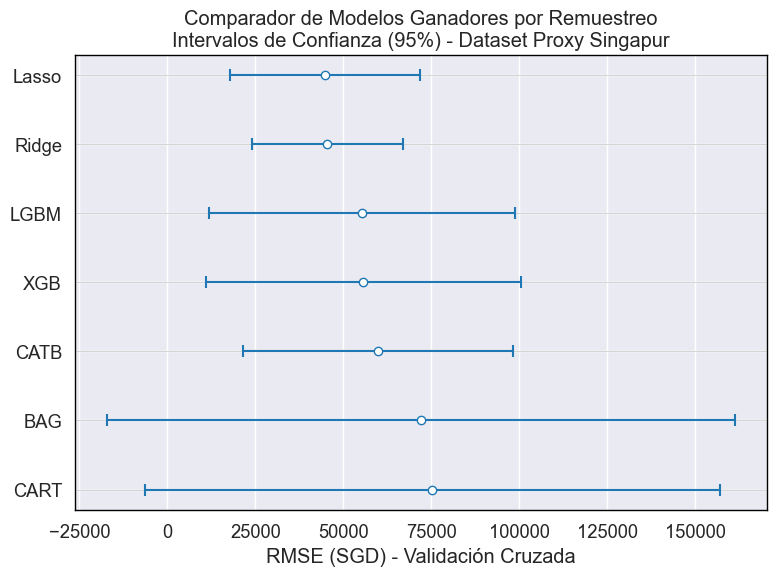


  --- Análisis de Diferencias Significativas (Test T-Pareado) ---
Modelo de referencia (menor RMSE promedio en CV): Lasso



,Comparación,p-value,Significativo (<0.05)
0,Lasso vs XGB,0.16800,NO
1,Lasso vs LGBM,0.13973,NO
2,Lasso vs CATB,0.05690,NO
3,Lasso vs Ridge,0.76695,NO
4,Lasso vs CART,0.13878,NO
5,Lasso vs BAG,0.20173,NO


In [ ]:
df_resultados = extraer_folds_dataset(nombre_dataset)

if df_resultados.empty:
    print(f"  Error: No se localizó ningún archivo .joblib válido en '{ruta_output}'.")
else:
    # --- A. SUMMARY ---
    print("\n --- Resumen Estadístico del RMSE en Validación Cruzada ---")
    resumen = df_resultados.describe().T[['mean', 'std', 'min', 'max']]
    resumen_ordenado = resumen.sort_values(by='mean')
    display(resumen_ordenado) 
    
    # --- B. DOTPLOT CON INTERVALOS DE CONFIANZA DEL 95% ---
    medias = df_resultados.mean()
    desviaciones = df_resultados.std()
    n_folds = len(df_resultados)
    
    t_critico = t.ppf(0.975, df=n_folds-1)
    margen_error = t_critico * (desviaciones / np.sqrt(n_folds))
    
    orden_modelos = [m for m in nombres_modelos.keys() if m in df_resultados.columns]
    orden_modelos_grafico = sorted(orden_modelos, key=lambda m: medias[m], reverse=True)

    x_medias = medias[orden_modelos_grafico]
    x_errores = margen_error[orden_modelos_grafico]
    y_pos = np.arange(len(orden_modelos_grafico))

    fig, ax = plt.subplots(figsize=(8, 6))
    
    for pos in y_pos:
        ax.axhline(y=pos, color='lightgray', linestyle='-', linewidth=0.7, zorder=1)

    ax.errorbar(
        x=x_medias, y=y_pos, xerr=x_errores, 
        fmt='o', mfc='white', mec='#1f77b4', ecolor='#1f77b4', 
        capsize=4, capthick=1.5, elinewidth=1.5, markersize=6, zorder=3
    )

    ax.set_yticks(y_pos)
    ax.set_yticklabels(orden_modelos_grafico)
    ax.set_xlabel("RMSE (SGD) - Validación Cruzada")
    ax.set_title(f"Comparador de Modelos Ganadores por Remuestreo\nIntervalos de Confianza (95%) - Dataset Proxy Singapur")
    
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1)

    plt.tight_layout()
    plt.show()
    
    # --- C. DIFF (Test T-Pareado) ---
    print("\n  --- Análisis de Diferencias Significativas (Test T-Pareado) ---")
    mejor_modelo = df_resultados.mean().idxmin()
    print(f"Modelo de referencia (menor RMSE promedio en CV): {mejor_modelo}\n")
    
    diferencias = []
    for modelo in df_resultados.columns:
        if modelo != mejor_modelo:
            stat, p_value = ttest_rel(df_resultados[mejor_modelo], df_resultados[modelo])
            significativo = "SÍ" if p_value < 0.05 else "NO"
            diferencias.append({
                "Comparación": f"{mejor_modelo} vs {modelo}",
                "p-value": f"{p_value:.5f}" if p_value > 0.00001 else f"{p_value:.3e}",
                "Significativo (<0.05)": significativo
            })
            
    if diferencias:
        df_diferencias = pd.DataFrame(diferencias)
        display(df_diferencias)
    else:
        print("No hay suficientes modelos para contrastar diferencias estadísticas.")



Como vemos, el mejor modelo matemáticamente es **Ridge**, un modelo lineal el cual consigue un RMSE promedio de 45215 con una desviación estándar de unos 12035, similar Lasso (también lineal). Esto significa que los modelos lineales son más robustos y consistentes en los diferentes cortes de tiempo, mientras que los árboles son más volátiles.

Al usar datos ordenados por fecha, estamos prediciendo el futuro en base al pasado. Los algoritmos basados en árboles son incapaces de extrapolar tendencias. Si los precios de los pisos han ido subiendo (por la inflación), un árbol nunca predecirá un precio más alto que el máximo que vio en su entrenamiento. Sin embargo, un modelo lineal como Ridge entiende la "pendiente" matemática y sí puede predecir precios inéditos más altos.

Sin embargo, aunque matemáticamente Ridge tiene 6000 menos de error que XGBoost, la prueba T-Pareada nos dice que esta diferencia no es estadísticamente significativa (p-value > 0.05). La variabilidad de los precios entre los diferentes años/cortes de la validación cruzada es tan alta que el test T de Student no puede asegurar al $100\%$ que Ridge sea estructuralmente mejor que XGBoost, entre otros. Podría haber ganado por pura casualidad en cómo cayeron las particiones de tiempo.

## 7.2. Elección del modelo final

Ahora procedemos a comparar **todos** los modelos que se han planteado, y nos quedamos con el mejor:

In [ ]:
try:
    h2o.connect()
except:
    h2o.init(nthreads=-1, max_mem_size="8G")
h2o.no_progress()

X_test_ds = splits[nombre_dataset]["X_test"]
y_test_ds = splits[nombre_dataset]["y_test"]
test_pd = pd.concat([X_test_ds, y_test_ds], axis=1)
filas_comparativa = []

# Evaluamos los modelos de Sklearn, XGBoost, LightGBM y CatoBoost
modelos_auditoria = {
    "XGBoost (Sklearn)": "XGBoost",  
    "LightGBM (Sklearn)": "LightGBM",
    "CatBoost (Sklearn)": "CatBoost", 
    "Ridge (Sklearn)": "Ridge",
    "Lasso (Sklearn)": "Lasso",
    "CART (Sklearn)": "CART", 
    "Bagging (Sklearn)": "Bagging"
}

for nombre_visible, nombre_archivo in modelos_auditoria.items():
    ruta_sk = f"{ruta_output}/{nombre_dataset}_modelo_{nombre_archivo}.joblib"
    if os.path.exists(ruta_sk):
        modelo = joblib.load(ruta_sk)
        y_pred = modelo.predict(X_test_ds)
        rmse = np.sqrt(mean_squared_error(y_test_ds, y_pred))
        r2 = r2_score(y_test_ds, y_pred)
        filas_comparativa.append({"Tecnología": "Sklearn/Boosting", "Modelo": nombre_visible, "RMSE": rmse, "R2": r2, "Ruta": ruta_sk})

# Evaluamos la red neuronal (MLPRegressor)
ruta_nn = f"{ruta_output}/{nombre_dataset}_modelo_Red_Neuronal_MLP.joblib"
if os.path.exists(ruta_nn):
    modelo_nn = joblib.load(ruta_nn)
    y_pred_nn = modelo_nn.predict(X_test_ds)
    rmse_nn = np.sqrt(mean_squared_error(y_test_ds, y_pred_nn))
    r2_nn = r2_score(y_test_ds, y_pred_nn)
    filas_comparativa.append({"Tecnología": "Red Neuronal", "Modelo": "MLPRegressor (Sklearn)", "RMSE": rmse_nn, "R2": r2_nn, "Ruta": ruta_nn})

# Evaluamos la red neuronal de H2O
ruta_h2o_nn = f"{ruta_output}/{nombre_dataset}_modelo_H2O_DeepLearning"
if os.path.exists(ruta_h2o_nn):
    modelo_nn_h2o = h2o.load_model(ruta_h2o_nn)
    h2o_test = h2o.H2OFrame(test_pd)
    rendimiento = modelo_nn_h2o.model_performance(test_data=h2o_test)
    rmse_h2o_nn = rendimiento.rmse()
    r2_h2o_nn = rendimiento.r2()
    filas_comparativa.append({"Tecnología": "H2O Deep Learning", "Modelo": "H2O NN", "RMSE": rmse_h2o_nn, "R2": r2_h2o_nn, "Ruta": ruta_h2o_nn})

# Evaluamos el ganador de H2O AutoML
ruta_h2o = f"{ruta_output}/modelo_H2O_{nombre_dataset}.pkl"
if os.path.exists(ruta_h2o):
    with open(ruta_h2o, "rb") as f:
        resultado_h2o = pickle.load(f)
    rmse_h2o = resultado_h2o[2] 
    r2_h2o = resultado_h2o[4]   
    nombre_h2o = resultado_h2o[5] 
    filas_comparativa.append({"Tecnología": "H2O AutoML", "Modelo": f"AutoML ({nombre_h2o})", "RMSE": rmse_h2o, "R2": r2_h2o, "Ruta": ruta_h2o})



Connecting to H2O server at http://localhost:54321 ...

 successful.


H2O_cluster_uptime:,30 mins 32 secs
H2O_cluster_timezone:,Europe/Madrid
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.11
H2O_cluster_version_age:,"28 days, 11 hours and 59 minutes"
H2O_cluster_name:,H2O_from_python_guill_o98psg
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,7.966 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


,Tecnología,Modelo,RMSE,R2
0,Red Neuronal,MLPRegressor (Sklearn),56929.356121,0.911908
1,H2O Deep Learning,H2O NN,69680.616155,0.868026
2,Sklearn/Boosting,XGBoost (Sklearn),77765.006523,0.835626
3,Sklearn/Boosting,CatBoost (Sklearn),83342.936304,0.811200
4,Sklearn/Boosting,Ridge (Sklearn),86248.886065,0.797804
5,Sklearn/Boosting,Lasso (Sklearn),88523.486575,0.786999
6,Sklearn/Boosting,LightGBM (Sklearn),90775.094101,0.776026
7,Sklearn/Boosting,Bagging (Sklearn),110449.370515,0.668418
8,Sklearn/Boosting,CART (Sklearn),118006.975007,0.621488



 ABRIENDO LA CAJA NEGRA DEL GANADOR ABSOLUTO: MLPRegressor (Sklearn) (Red Neuronal)
[INFO] Calculando la Permutation Importance sobre el Pipeline...


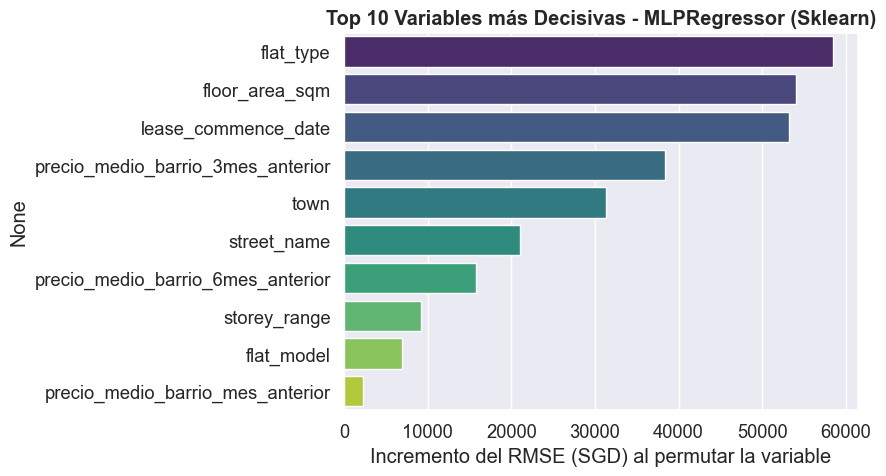

[INFO] Generando Dependencia Parcial (PDP) para: 'flat_type' y 'floor_area_sqm'...


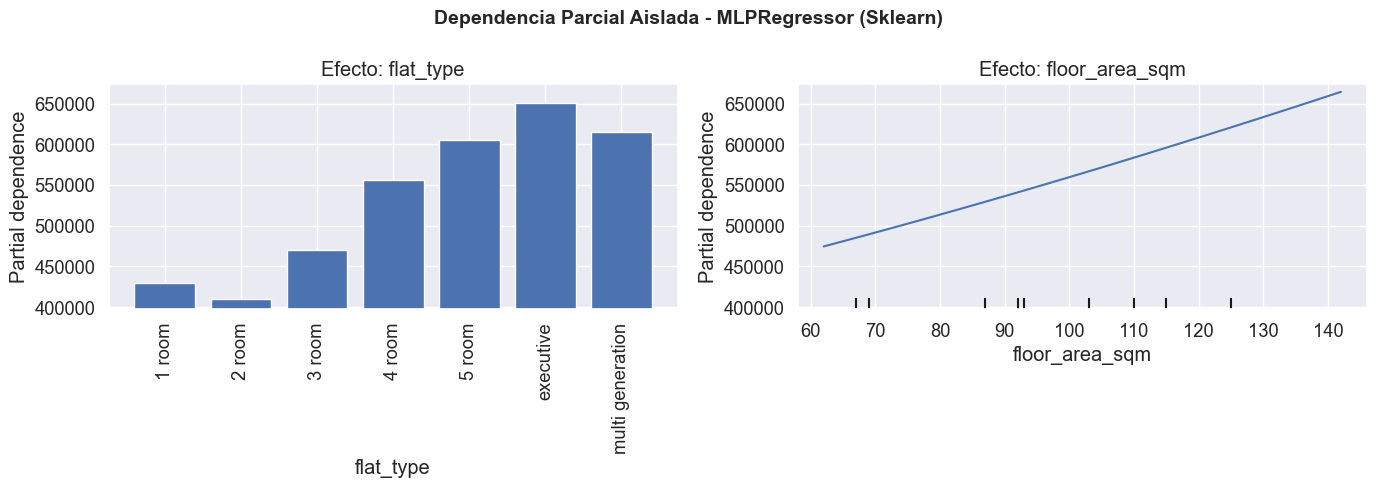

In [ ]:
# LEADERBOARD ABSOLUTO E INTERPRETABILIDAD
# ---------------------------------------------
if not filas_comparativa:
    print(f" Error: No se encontraron modelos en {ruta_output}")
else:
    df_comp = pd.DataFrame(filas_comparativa)
    df_comp = df_comp.sort_values(by="RMSE", ascending=True).reset_index(drop=True)
    
    
    display(df_comp.drop(columns=['Ruta']).style.bar(subset=['R2'], color='#5fba7d').highlight_min(subset=['RMSE'], color='#ff9999'))

    ganador = df_comp.iloc[0]
    tecnologia_ganadora = ganador['Tecnología']
    ruta_ganador = ganador['Ruta']
    nombre_ganador = ganador['Modelo']
    
    print(f"\n ABRIENDO LA CAJA NEGRA DEL GANADOR ABSOLUTO: {nombre_ganador} ({tecnologia_ganadora})")
    
    if tecnologia_ganadora in ["Sklearn/Boosting", "Red Neuronal"]:
        modelo_cargado = joblib.load(ruta_ganador)
        pipeline_final = modelo_cargado.best_estimator_ if hasattr(modelo_cargado, 'best_estimator_') else modelo_cargado
            
        print("[INFO] Calculando la Permutation Importance sobre el Pipeline...")
        X_test_sample = X_test_ds.sample(min(20000, len(X_test_ds)), random_state=42)
        y_test_sample = y_test_ds.loc[X_test_sample.index]
        
        res_importancia = permutation_importance(
            pipeline_final, X_test_sample, y_test_sample, 
            n_repeats=5, random_state=42, scoring='neg_root_mean_squared_error', n_jobs=-1
        )
        
        importancias = pd.Series(res_importancia.importances_mean, index=X_test_sample.columns).sort_values(ascending=False)
        top_var_1 = importancias.index[0]
        top_var_2 = importancias.index[1]
        
        plt.figure(figsize=(9, 5))
        sns.barplot(x=importancias.head(10).values, y=importancias.head(10).index, palette="viridis")
        plt.title(f"Top 10 Variables más Decisivas - {nombre_ganador}", fontweight='bold')
        plt.xlabel("Incremento del RMSE (SGD) al permutar la variable")
        plt.tight_layout()
        plt.show()
        
        columnas_categoricas = X_test_sample.select_dtypes(exclude=['number']).columns.tolist()

        print(f"[INFO] Generando Dependencia Parcial (PDP) para: '{top_var_1}' y '{top_var_2}'...")
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        PartialDependenceDisplay.from_estimator(
            estimator=pipeline_final,
            X=X_test_sample,
            features=[top_var_1, top_var_2],
            categorical_features=columnas_categoricas, 
            grid_resolution=20,
            n_jobs=1,
            ax=axes
        )
        
        fig.suptitle(f"Dependencia Parcial Aislada - {nombre_ganador}", fontsize=14, fontweight='bold')
        axes[0].set_title(f"Efecto: {top_var_1}")
        axes[1].set_title(f"Efecto: {top_var_2}")
        plt.tight_layout()
        plt.show()
        
    elif tecnologia_ganadora == "H2O AutoML":
        with open(ruta_ganador, "rb") as f:
            resultado_h2o = pickle.load(f)
            
        var_import_df = resultado_h2o[1]
        model_id = resultado_h2o[5]
        
        if isinstance(var_import_df, pd.DataFrame):
            df_top10 = var_import_df.head(10).sort_values(by="scaled_importance", ascending=True)
            plt.figure(figsize=(9, 5))
            sns.barplot(data=df_top10, x="scaled_importance", y="variable", palette="crest")
            plt.title(f"Top 10 Variables más Decisivas - {nombre_ganador}", fontweight='bold')
            plt.xlabel("Importancia Escalada (0 a 1)")
            plt.tight_layout()
            plt.show()
            
            top_var_1 = var_import_df.iloc[0]["variable"]
            top_var_2 = var_import_df.iloc[1]["variable"]
            
            try:
                h2o_model = h2o.get_model(model_id)
                h2o_test = h2o.H2OFrame(test_pd)
                print(f"[INFO] Generando PDP de H2O para: '{top_var_1}' y '{top_var_2}'...")
                h2o_model.partial_plot(data=h2o_test, cols=[top_var_1, top_var_2], plot=True)
            except Exception as e:
                print(f"\n[AVISO] No se pudo generar el PDP. El modelo '{model_id}' ya no está en la memoria del clúster.")

    elif tecnologia_ganadora == "H2O Deep Learning":
        h2o_model = h2o.load_model(ruta_ganador)
        var_import_df = h2o_model.varimp(use_pandas=True)
        
        if isinstance(var_import_df, pd.DataFrame):
            df_top10 = var_import_df.head(10).sort_values(by="scaled_importance", ascending=True)
            plt.figure(figsize=(9, 5))
            sns.barplot(data=df_top10, x="scaled_importance", y="variable", palette="magma")
            plt.title(f"Top 10 Variables más Decisivas - {nombre_ganador}", fontweight='bold')
            plt.xlabel("Importancia Escalada (0 a 1)")
            plt.tight_layout()
            plt.show()
            
            top_var_1 = var_import_df.iloc[0]["variable"]
            top_var_2 = var_import_df.iloc[1]["variable"]
            
            h2o_test = h2o.H2OFrame(test_pd)
            print(f"[INFO] Generando PDP de H2O Deep Learning para: '{top_var_1}' y '{top_var_2}'...")
            h2o_model.partial_plot(data=h2o_test, cols=[top_var_1, top_var_2], plot=True)

h2o.cluster().shutdown(prompt=False)

Como vemos, aunque los modelos lineales (Ridge) demostraron una alta estabilidad en el pasado, al enfrentarse al conjunto de prueba futuro, la Red Neuronal Densa (MLP) arroja mejores métricas sobre el conjunto de test. Esto sugiere que el mercado inmobiliario de Singapur contiene patrones profundos fuertemente no lineales e interacciones complejas entre variables (ej. combinaciones específicas de distritos, antigüedad, tamaño...) que los modelos tradicionales y los algoritmos basados en árboles no lograron capturar con éxito.

La **Dependencia Parcial** es una técnica de interpretabilidad para modelos de Machine Learning (especialmente útil en modelos de "caja negra" como Redes Neuronales, Random Forest o Gradient Boosting).

Su objetivo principal es mostrar el efecto marginal de una o dos variables sobre la predicción final del modelo, aislando por completo el impacto del resto de las variables.

Como era de esperar, en el gráfico de el efecto del tipo de piso, se aprecia una escalada. Pasar de un piso de 1 habitación a uno de 2, 3, 4 y 5 habitaciones incrementa progresivamente la predicción del precio. El modelo ha entendido a la perfección que más habitaciones = más valor. La categoría executive es la que proyecta el precio más alto de todos (casi 650.000 en promedio base), superando incluso a los pisos grandes de 5 habitaciones. La categoría multi generation (pisos diseñados para que vivan abuelos, padres e hijos juntos) es más cara que un piso de 5 habitaciones, pero ligeramente inferior a un executive. La red neuronal ha captado esta sutil jerarquía de lujo y demanda en el mercado de Singapur.

En cuanto al gráfico para el efecto del precio medio por barrio del mes anterior, Vemos que la relación es totalmente lineal y directa: Por cada dólar que subió la media del barrio el mes pasado, la red neuronal sube su predicción para el piso actual casi en la misma proporción. Esta es la variable más importante del modelo por una razón clara. La red neuronal la está usando como su "precio base" o ancla. El modelo piensa: "Si el mes pasado los pisos en este distrito se vendieron por 500.000 SGD de media, mi predicción para este piso empieza en 500.000, y luego ya le sumaré o restaré dinero dependiendo de si es viejo, nuevo, o si tiene 3 o 5 habitaciones". Las marcas en el eje x de este gráfico indican dónde se concentra la mayor cantidad de datos reales. Confirman que la inmensa mayoría de las transacciones en Singapur se mueven en barrios con medias de entre 400.000 y 650.000.